In [1]:
import logging
from utility import add_project_root_to_path
import numpy as np
from copy import deepcopy

logging.basicConfig(level=logging.ERROR)

add_project_root_to_path()

In [ ]:
from fee_algorithm.fixed_fee import FixedFee
from fee_algorithm.discrete_fee_perfect_oracle import DiscreteFeePerfectOracle
from fee_algorithm.based_on_trade_count_fee import BasedOnTradeCountFee
from fee_algorithm.adaptive_fee_based_on_block_price_move import (
    AdaptiveBasedOnPreviousBlockPriceMoveFee,
)
from fee_algorithm.dynamic_fee_amm_for_amm import AMMforAMMfee
from fee_algorithm.improved_fees.piecewise_fee import PiecewiseFee
from fee_algorithm.improved_fees.fixed_fee import ImprovedFixedFee

from copy import deepcopy

fee_algos_to_consider = {
    "FX_fee": FixedFee(exchange_fee_rate=0.003),
    "DA_fee": BasedOnTradeCountFee(
        a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
    ),
    # "BA_fee": AdaptiveBasedOnPreviousBlockPriceMoveFee(
    #     a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
    # ),
    # "AMM_fee": AMMforAMMfee(
    #     a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
    # ),
    # "OB_fee": DiscreteFeePerfectOracle(
    #     fee_rate_in_arbitrage_direction=0.0045,
    #     fee_rate_in_non_arbitrage_direction=0.0015,
    # ),
    "IMPROVED_FX_fee": PiecewiseFee(base_algorithm=FixedFee(exchange_fee_rate=0.003)),
    "IMPROVED_DA_fee": PiecewiseFee(
        base_algorithm=BasedOnTradeCountFee(
            a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
        )
    ),
    # "IMPROVED_BA_fee": PiecewiseFee(
    #     base_algorithm=AdaptiveBasedOnPreviousBlockPriceMoveFee(
    #         a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
    #     )
    # ),
    # "IMPROVED_AMM_fee": PiecewiseFee(
    #     base_algorithm=AMMforAMMfee(
    #         a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
    #     )
    # ),
    # "IMPROVED_OB_fee": PiecewiseFee(
    #     base_algorithm=DiscreteFeePerfectOracle(
    #         fee_rate_in_arbitrage_direction=0.0045,
    #         fee_rate_in_non_arbitrage_direction=0.0015,
    #     )
    # ),
}

In [3]:
# Fit GBM parameters from pre-downloaded 12 s CSVs.
# Uses the first day of each monthly file (~7 200 rows) – same approach as
# fee_algorithms_comparison_synth_data.ipynb but loading from local CSVs
# instead of fetching from the Binance API.

import pandas as pd
from pathlib import Path
from experiments.experiment import GBMParameters
from experiments.synthetic_data import extract_gbm_params

DATA_DIR = Path("data/new_data")
ROWS_PER_DAY = 24 * 3600 // 12  # = 7 200

PAIRS_BY_GROUP = {
    "stable_stable": [
        ("TUSDUSDT_USDCUSDT", "TUSD/USDC"),
        ("TUSDUSDT_USDPUSDT", "TUSD/USDP"),
        ("USDCUSDT_USDPUSDT", "USDC/USDP"),
    ],
    "non_stable_stable": [
        ("USDCUSDT_RADUSDT", "USDC/RAD"),
        ("ETHUSDT_USDT", "ETH/USDT"),
        ("BTCUSDT_USDT", "BTC/USDT"),
        # # ("BTCUSDT_ETHUSDT", "BTC/ETH"),
        # # ("BTCUSDT_BNBUSDT", "BTC/BNB"),
        # # ("ETHUSDT_BNBUSDT", "ETH/BNB"),
    ],
    "non_stable_non_stable": [
        ("BTCUSDT_ETHUSDT", "ETH/BTC"),
        ("ETHUSDT_BNBUSDT", "BNB/ETH"),
        ("DOGEUSDT_BTCUSDT", "DOGE/BTC"),
    ],
}

MONTHS = ["2024-03", "2024-04", "2024-08", "2024-11"]
MONTH_ALIAS = {
    "2024-03": "volatile_market",
    "2024-04": "bear_market",
    "2024-08": "calm_market",
    "2024-11": "bull_market",
}


# gbm_params[(pair_name, month_alias)] = GBMParameters
gbm_params = {}


for group_name, pairs in PAIRS_BY_GROUP.items():
    for csv_prefix, pair_name in pairs:
        for month, month_alias in MONTH_ALIAS.items():
            csv_path = DATA_DIR / f"{csv_prefix}-12s-{month}.csv"
            if not csv_path.exists():
                print(f"WARNING: {csv_path} not found, skipping")
                continue
            df = pd.read_csv(csv_path, nrows=ROWS_PER_DAY)
            params = extract_gbm_params(
                df[["price_A", "price_B"]].transpose().to_numpy()
            )
            gbm_params[(pair_name, month_alias)] = params
            print(
                f"{pair_name} / {month_alias}: mu={params.mu}, S0={params.S0}, cov={params.cov_matrix}"
            )

TUSD/USDC / volatile_market: mu=[1.3894291755568955e-08, -2.7801097197276458e-08], S0=[0.9997, 0.9994], cov=[[6.40178670e-09 7.36924202e-11]
 [7.36924202e-11 4.72815466e-09]]
TUSD/USDC / bear_market: mu=[-6.948536070381617e-08, -5.557438829314489e-08], S0=[0.9998, 1.0], cov=[[3.12859066e-09 1.73802590e-10]
 [1.73802590e-10 4.55925641e-09]]
TUSD/USDC / calm_market: mu=[-5.557994739847391e-08, 6.941591353934919e-08], S0=[0.9999, 1.0003], cov=[[ 2.03557908e-09 -8.33442507e-12]
 [-8.33442507e-12  4.40582897e-09]]
TUSD/USDC / bull_market: mu=[5.025829141801734e-07, -1.110266273046607e-07], S0=[0.9932, 1.0013], cov=[[ 1.62746840e-09 -4.31172188e-11]
 [-4.31172188e-11  4.47210388e-09]]
TUSD/USDP / volatile_market: mu=[1.3894291755568955e-08, 3.1201498136502903e-19], S0=[0.9997, 0.9993], cov=[[ 6.40178670e-09 -6.94998408e-12]
 [-6.94998408e-12  8.51413515e-10]]
TUSD/USDP / bear_market: mu=[-6.948536070381617e-08, -9.72600461682092e-08], S0=[0.9998, 1.0001], cov=[[ 3.12859066e-09 -1.80890243e-1

In [4]:
# USDC/RAD: separate market regime dates (determined from 2025 rolling mu/sigma analysis)
# volatile_market: 2025-03-10  (sigma~0.29, wild price jump)
# calm_market:     2025-06-07  (sigma~0.03, flat)
# bull_market:     2025-07-21  (steady rise, mu>0)
# bear_market:     2025-01-08  (steady decline)

# USDC_RAD_MONTHS = {
#     "2025-03": "volatile_market",
#     "2025-01": "bear_market",
#     "2025-06": "calm_market",
#     "2025-07": "bull_market",
# }
# USDC_RAD_DAY_OFFSETS = {
#     "volatile_market": 9,  # day 10 (0-indexed: row 9*7200)
#     "bear_market": 7,  # day 8
#     "calm_market": 6,  # day 7
#     "bull_market": 20,  # day 21
# }

# pair_name = "USDC/RAD"
# csv_prefix = "USDCUSDT_RADUSDT"

# for month, month_alias in USDC_RAD_MONTHS.items():
#     csv_path = DATA_DIR / f"{csv_prefix}-12s-{month}.csv"
#     if not csv_path.exists():
#         print(f"WARNING: {csv_path} not found, skipping")
#         continue
#     day_offset = USDC_RAD_DAY_OFFSETS[month_alias]
#     start_row = day_offset * ROWS_PER_DAY
#     df = pd.read_csv(csv_path, skiprows=range(1, start_row + 1), nrows=ROWS_PER_DAY)
#     # re-read header
#     header = pd.read_csv(csv_path, nrows=0)
#     df.columns = header.columns
#     params = extract_gbm_params(df[["price_A", "price_B"]].transpose().to_numpy())
#     gbm_params[(pair_name, month_alias)] = params
#     print(
#         f"{pair_name} / {month_alias} ({month}, day {day_offset+1}): mu={params.mu}, S0={params.S0}, cov_mtrx={params.cov_matrix}"
#     )

In [5]:
# SCALE = 100  # variance scale factor (10x std)
SCALE = 1
for key in list(gbm_params.keys()):
    p = gbm_params[key]
    gbm_params[key] = GBMParameters(
        mu=p.mu,
        S0=p.S0,
        cov_matrix=p.cov_matrix * SCALE,
    )

In [6]:
from experiments.experiment import SyntheticDataDescription
from datetime import datetime

# Time ranges: 24 hours per market condition (7 200 blocks at 12s interval)
TIME_RANGE = {
    "volatile_market": (datetime(2024, 3, 1, 12, 0, 0), datetime(2024, 3, 2, 12, 0, 0)),
    "bear_market": (datetime(2024, 4, 1, 12, 0, 0), datetime(2024, 4, 2, 12, 0, 0)),
    "calm_market": (datetime(2024, 8, 1, 12, 0, 0), datetime(2024, 8, 2, 12, 0, 0)),
    "bull_market": (datetime(2024, 11, 1, 12, 0, 0), datetime(2024, 11, 2, 12, 0, 0)),
}


# synth_desc[(pair_name, month_alias)] = SyntheticDataDescription
synth_desc = {
    (pair_name, month_alias): SyntheticDataDescription(
        gbm_parameters=gbm_params[(pair_name, month_alias)],
        start_time=TIME_RANGE[month_alias][0],
        end_time=TIME_RANGE[month_alias][1],
        candle_interval="12s",
    )
    for (pair_name, month_alias) in gbm_params
}

print(f"Synthetic data descriptions: {len(synth_desc)}")

Synthetic data descriptions: 36


In [7]:
from experiments.experiment import Experiment
from experiments.configs import DEFAULT_UNINFORMED_USERS_CONFIG
from user.informed_user import InformedUser
from experiments.run_multiple_experiments import (
    run_multiple_experiments,
    get_experiment_key,
)

# 100 seeds balances statistical robustness with run time.
# 9 pairs × 4 months × 100 seeds × 10 algos = 36 000 experiments.
# Increase to 1000 for publication-quality results (360 000 experiments, ~70 min).
random_seeds = list(range(100))

experiments_configs = {}

for fee_algo_name, fee_algo in fee_algos_to_consider.items():
    for (pair_name, month_alias), desc in synth_desc.items():
        for seed in random_seeds:
            experiments_configs[
                get_experiment_key(
                    {
                        "pair_name": pair_name,
                        "month_alias": month_alias,
                        "fee_algo_name": fee_algo_name,
                        "random_seed": str(seed),
                    }
                )
            ] = Experiment(
                data=desc,
                fee_algorithm=deepcopy(fee_algo),
                informed_user=InformedUser(),
                uninformed_users=deepcopy(DEFAULT_UNINFORMED_USERS_CONFIG),
                random_seed=seed,
                lp_metrics_price_source="pool",
                # lp_metrics_price_source="fair",
            )

print(f"Total experiments to run: {len(experiments_configs)}")

Total experiments to run: 36000


In [8]:
experiments_results = run_multiple_experiments(
    experiments_configs,
    parallel=True,
    max_workers=12,
    return_intermediate_results=False,
)

Running Experiments: 100%|██████████| 36000/36000 [26:44<00:00, 22.44it/s]


In [9]:
from visualizations.compare_fee_algoritms import get_experiments_summary_by_description

df = get_experiments_summary_by_description(experiments_results)
df

,pair_name,fee_algo_name,month_alias,random_seed,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
0,TUSD/USDC,FX_fee,volatile_market,3,8.98,18,0.60,-8101.28,721,-56.05,4463.12,27.99,-3755.66
1,TUSD/USDC,FX_fee,volatile_market,1,5.46,9,0.72,-7737.46,696,-55.73,4130.47,28.22,-4073.88
2,TUSD/USDC,FX_fee,volatile_market,2,11.59,16,0.86,-7978.81,699,-57.64,4255.20,28.01,-4234.30
3,TUSD/USDC,FX_fee,volatile_market,6,16.84,20,0.99,-7983.19,701,-57.06,4380.96,27.91,-4698.78
4,TUSD/USDC,FX_fee,volatile_market,7,20.30,24,0.99,-8820.57,777,-57.27,4858.96,27.85,-4837.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35995,DOGE/BTC,IMPROVED_OB_fee,bull_market,95,519.50,147,3.49,-7994.74,721,-55.77,9670.36,33.11,-6748.79
35996,DOGE/BTC,IMPROVED_OB_fee,bull_market,96,468.62,134,3.45,-8816.48,765,-57.68,9206.37,31.90,-5075.44
35997,DOGE/BTC,IMPROVED_OB_fee,bull_market,97,342.95,127,2.83,-8299.76,745,-57.70,8521.09,32.16,-9251.94
35998,DOGE/BTC,IMPROVED_OB_fee,bull_market,98,462.57,132,3.42,-8096.28,715,-55.81,9136.87,32.58,-8868.41


In [10]:
import pandas as pd
from typing import Optional


def show_stats_for_pair_alias(
    pair_name: str, month_alias: str, path_to_save: Optional[str] = None
):
    df_filtered = df[
        (df["pair_name"] == pair_name) & (df["month_alias"] == month_alias)
    ]

    grouped_stats = (
        df_filtered.drop(columns=["pair_name", "month_alias", "random_seed"])
        .groupby("fee_algo_name")
        .agg(["mean", "std"])
    )

    formatted_stats = grouped_stats.apply(
        lambda row: [
            f"{row[col, 'mean']:.2f} \u00b1 {row[col, 'std']:.2f}"
            for col in grouped_stats.columns.get_level_values(0).unique()
        ],
        axis=1,
        result_type="expand",
    )
    formatted_stats.columns = grouped_stats.columns.get_level_values(0).unique()
    print(f"\n=== {pair_name} / {month_alias} ===")
    display(formatted_stats)
    if path_to_save:
        import os

        os.makedirs(os.path.dirname(path_to_save), exist_ok=True)
        formatted_stats.to_csv(path_to_save)
    return formatted_stats

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


def plot_yield_stats(
    pair_name: str, month_alias: str, fee_algos: Optional[list[str]] = None
):
    df_filtered = df[
        (df["pair_name"] == pair_name) & (df["month_alias"] == month_alias)
    ]
    fee_algos = fee_algos or list(df_filtered["fee_algo_name"].unique())
    colors = sns.color_palette("husl", len(fee_algos))

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

    for color, algo_name in zip(colors, fee_algos):
        algo_df = df_filtered[df_filtered["fee_algo_name"] == algo_name]
        sns.kdeplot(
            algo_df["lp_yield"],
            ax=ax,
            label=algo_name,
            color=color,
            fill=True,
            alpha=0.3,
        )

    ax.set_xlabel("LP Yield")
    ax.set_ylabel("Density")
    ax.set_title(f"LP Yield distribution — {pair_name} / {month_alias}")
    ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_performance_profile(
    pair_name: str, month_alias: str, fee_algos: Optional[list[str]] = None
):
    df_filtered = df[
        (df["pair_name"] == pair_name) & (df["month_alias"] == month_alias)
    ]
    fee_algos = fee_algos or list(df_filtered["fee_algo_name"].unique())

    best_per_seed = (
        df_filtered[df_filtered["fee_algo_name"].isin(fee_algos)]
        .groupby("random_seed")["lp_yield"]
        .max()
        .reset_index()
        .rename(columns={"lp_yield": "best_lp_yield"})
    )

    merged = df_filtered.merge(best_per_seed, on="random_seed")
    merged["ratio"] = merged["best_lp_yield"] / merged["lp_yield"].replace(0, np.nan)

    tau_vals = np.linspace(1, merged["ratio"].max() + 0.1, 500)
    fig, ax = plt.subplots(figsize=(10, 6))

    colors = sns.color_palette("husl", len(fee_algos))
    for color, algo_name in zip(colors, fee_algos):
        algo_df = merged[merged["fee_algo_name"] == algo_name]
        profile = [(algo_df["ratio"] <= tau).mean() for tau in tau_vals]
        ax.plot(tau_vals, profile, label=algo_name, color=color)

    ax.set_xlabel("Performance ratio τ")
    ax.set_ylabel("Fraction of problems solved")
    ax.set_title(f"Performance profile — {pair_name} / {month_alias}")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

### Stable / Stable

#### TUSD/USDC

##### volatile_market


=== TUSD/USDC / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,18.24 ± 5.92,18.37 ± 4.24,1.14 ± 0.21,-8182.15 ± 273.31,723.56 ± 24.34,-56.73 ± 0.74,4342.94 ± 174.98,27.13 ± 0.61,-4495.61 ± 243.12
BA_fee,15.10 ± 5.51,18.02 ± 5.22,0.98 ± 0.22,-8179.77 ± 277.28,723.91 ± 24.46,-56.69 ± 0.78,4363.53 ± 169.05,27.33 ± 0.47,-4495.46 ± 260.12
DA_fee,9.38 ± 4.94,12.84 ± 4.73,0.83 ± 0.25,-8181.74 ± 282.59,723.29 ± 24.72,-56.75 ± 0.76,4402.95 ± 188.25,28.40 ± 0.52,-4438.60 ± 432.86
FX_fee,11.75 ± 4.98,14.81 ± 4.77,0.93 ± 0.23,-8186.14 ± 281.05,723.42 ± 24.66,-56.77 ± 0.81,4399.63 ± 157.63,28.06 ± 0.13,-4474.27 ± 342.50
IMPROVED_AMM_fee,18.24 ± 5.92,18.37 ± 4.24,1.14 ± 0.21,-8182.15 ± 273.31,723.56 ± 24.34,-56.73 ± 0.74,4342.94 ± 174.98,27.13 ± 0.61,-4495.61 ± 243.12
IMPROVED_BA_fee,15.10 ± 5.51,18.02 ± 5.22,0.98 ± 0.22,-8179.77 ± 277.28,723.91 ± 24.46,-56.69 ± 0.78,4363.53 ± 169.05,27.33 ± 0.47,-4495.46 ± 260.12
IMPROVED_DA_fee,9.38 ± 4.94,12.84 ± 4.73,0.83 ± 0.25,-8181.74 ± 282.59,723.29 ± 24.72,-56.75 ± 0.76,4402.95 ± 188.25,28.40 ± 0.52,-4438.60 ± 432.86
IMPROVED_FX_fee,11.75 ± 4.98,14.81 ± 4.77,0.93 ± 0.23,-8186.14 ± 281.05,723.42 ± 24.66,-56.77 ± 0.81,4399.63 ± 157.63,28.06 ± 0.13,-4474.27 ± 342.50
IMPROVED_OB_fee,7.55 ± 4.35,9.56 ± 4.37,0.91 ± 0.35,-8172.36 ± 286.26,723.35 ± 24.51,-56.68 ± 0.66,4423.31 ± 185.04,29.04 ± 0.41,-4489.31 ± 332.07


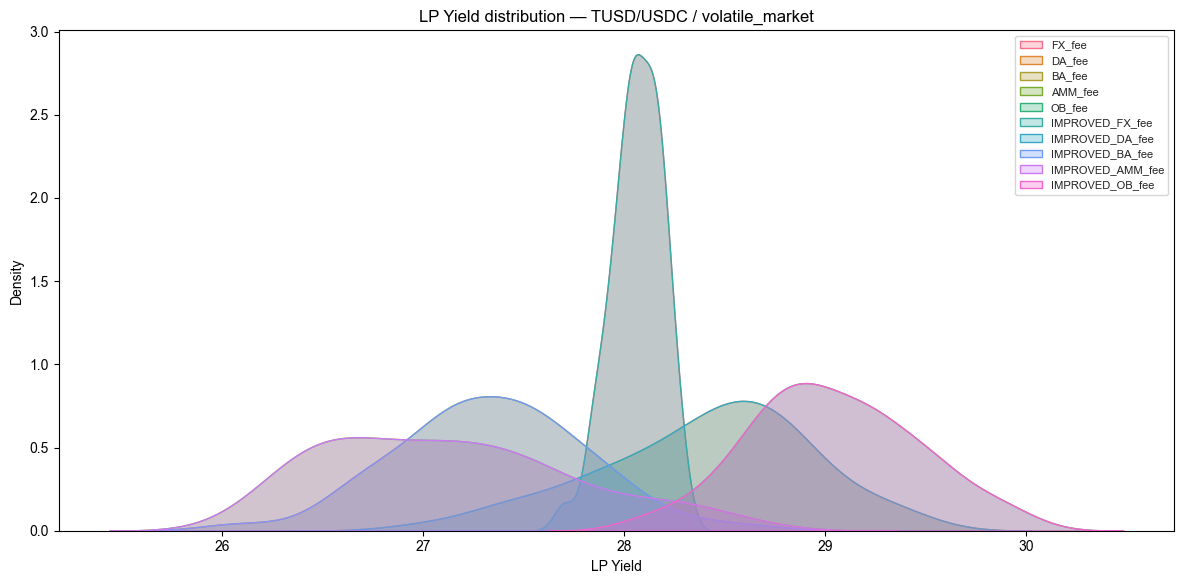

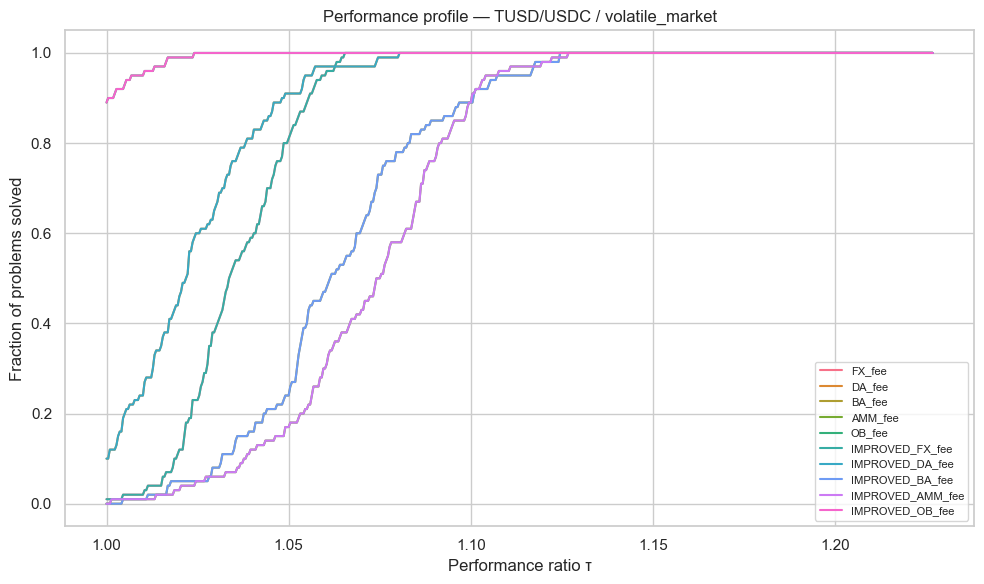

In [12]:
show_stats_for_pair_alias("TUSD/USDC", "volatile_market")
plot_yield_stats("TUSD/USDC", "volatile_market")
plot_performance_profile("TUSD/USDC", "volatile_market")

##### bull_market


=== TUSD/USDC / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,15.45 ± 5.04,15.74 ± 3.67,1.13 ± 0.25,-8172.51 ± 281.75,723.44 ± 24.88,-56.62 ± 0.63,4279.68 ± 160.65,27.10 ± 0.50,-4480.92 ± 246.09
BA_fee,12.21 ± 5.01,14.95 ± 4.81,0.95 ± 0.22,-8167.55 ± 289.27,723.01 ± 24.45,-56.61 ± 0.68,4286.91 ± 155.43,27.31 ± 0.41,-4456.36 ± 270.98
DA_fee,6.71 ± 4.52,9.84 ± 4.66,0.77 ± 0.26,-8174.24 ± 294.18,722.83 ± 24.52,-56.68 ± 0.73,4362.30 ± 179.53,28.60 ± 0.38,-4480.84 ± 378.05
FX_fee,9.56 ± 4.61,11.56 ± 4.56,0.95 ± 0.25,-8175.80 ± 288.24,723.50 ± 24.50,-56.63 ± 0.74,4339.95 ± 155.37,28.14 ± 0.13,-4476.32 ± 323.55
IMPROVED_AMM_fee,15.45 ± 5.04,15.74 ± 3.67,1.13 ± 0.25,-8172.51 ± 281.75,723.44 ± 24.88,-56.62 ± 0.63,4279.68 ± 160.65,27.10 ± 0.50,-4480.92 ± 246.09
IMPROVED_BA_fee,12.21 ± 5.01,14.95 ± 4.81,0.95 ± 0.22,-8167.55 ± 289.27,723.01 ± 24.45,-56.61 ± 0.68,4286.91 ± 155.43,27.31 ± 0.41,-4456.36 ± 270.98
IMPROVED_DA_fee,6.71 ± 4.52,9.84 ± 4.66,0.77 ± 0.26,-8174.24 ± 294.18,722.83 ± 24.52,-56.68 ± 0.73,4362.30 ± 179.53,28.60 ± 0.38,-4480.84 ± 378.05
IMPROVED_FX_fee,9.56 ± 4.61,11.56 ± 4.56,0.95 ± 0.25,-8175.80 ± 288.24,723.50 ± 24.50,-56.63 ± 0.74,4339.95 ± 155.37,28.14 ± 0.13,-4476.32 ± 323.55
IMPROVED_OB_fee,6.46 ± 4.28,8.14 ± 4.53,0.91 ± 0.41,-8179.77 ± 287.74,723.32 ± 24.19,-56.67 ± 0.65,4378.63 ± 172.20,28.95 ± 0.40,-4510.85 ± 299.78


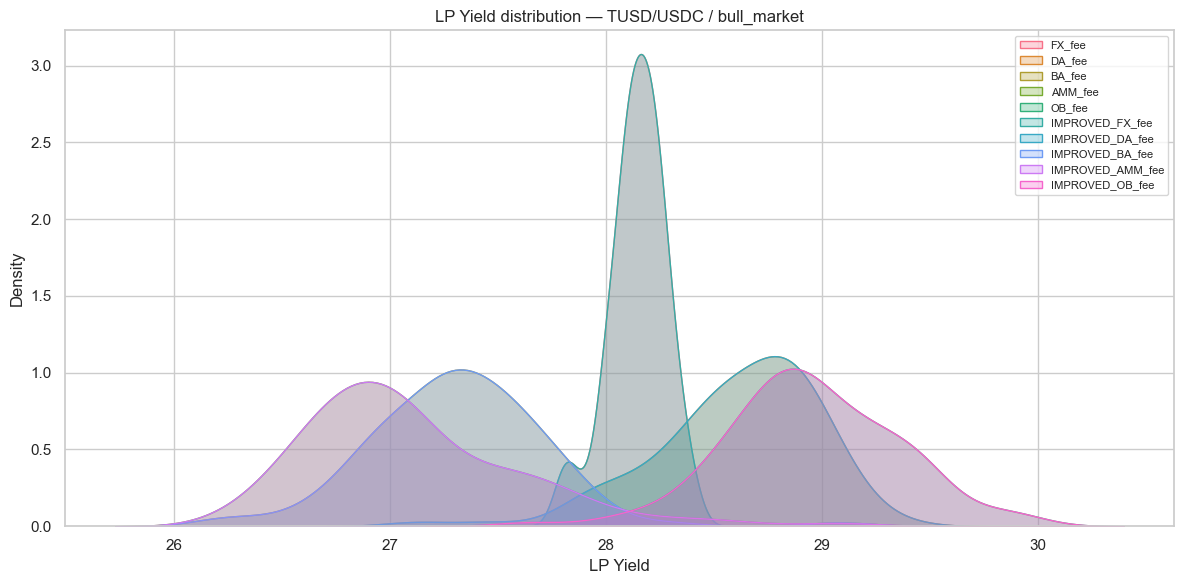

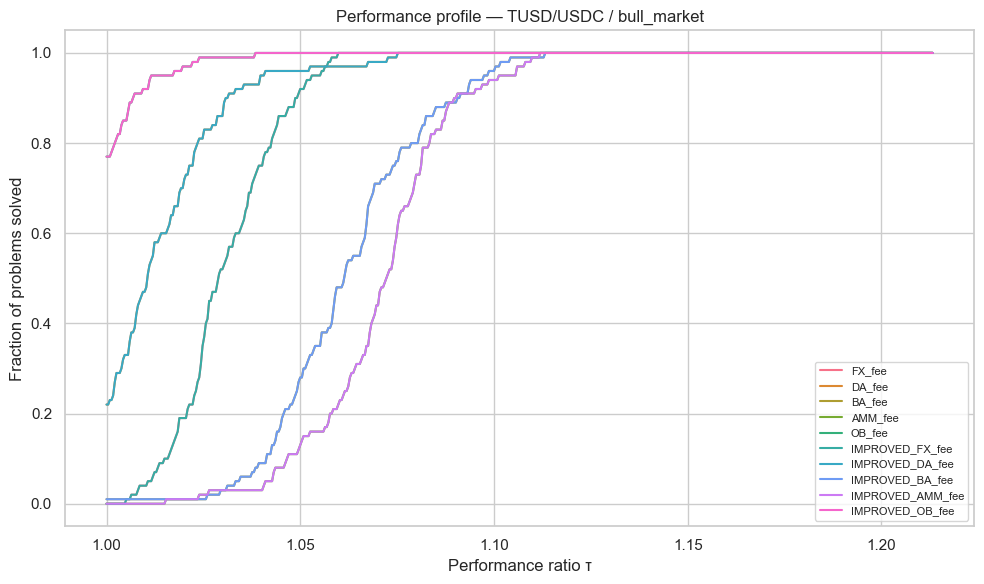

In [13]:
show_stats_for_pair_alias("TUSD/USDC", "bull_market")
plot_yield_stats("TUSD/USDC", "bull_market")
plot_performance_profile("TUSD/USDC", "bull_market")

##### calm_market


=== TUSD/USDC / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,14.93 ± 5.00,15.70 ± 3.80,1.10 ± 0.27,-8165.51 ± 287.72,723.43 ± 24.84,-56.61 ± 0.67,4270.58 ± 165.11,27.07 ± 0.48,-4492.09 ± 203.29
BA_fee,12.20 ± 4.96,14.77 ± 4.31,0.96 ± 0.22,-8174.44 ± 295.65,723.74 ± 24.85,-56.64 ± 0.72,4283.48 ± 156.20,27.30 ± 0.37,-4472.02 ± 233.22
DA_fee,6.75 ± 3.89,9.81 ± 4.51,0.81 ± 0.33,-8173.12 ± 294.83,723.18 ± 24.72,-56.68 ± 0.70,4355.49 ± 178.22,28.57 ± 0.46,-4491.62 ± 303.89
FX_fee,9.43 ± 4.57,11.55 ± 4.65,0.98 ± 0.33,-8174.78 ± 299.06,723.59 ± 24.76,-56.66 ± 0.72,4337.85 ± 160.09,28.15 ± 0.13,-4496.55 ± 254.89
IMPROVED_AMM_fee,14.93 ± 5.00,15.70 ± 3.80,1.10 ± 0.27,-8165.51 ± 287.72,723.43 ± 24.84,-56.61 ± 0.67,4270.58 ± 165.11,27.07 ± 0.48,-4492.09 ± 203.29
IMPROVED_BA_fee,12.20 ± 4.96,14.77 ± 4.31,0.96 ± 0.22,-8174.44 ± 295.65,723.74 ± 24.85,-56.64 ± 0.72,4283.48 ± 156.20,27.30 ± 0.37,-4472.02 ± 233.22
IMPROVED_DA_fee,6.75 ± 3.89,9.81 ± 4.51,0.81 ± 0.33,-8173.12 ± 294.83,723.18 ± 24.72,-56.68 ± 0.70,4355.49 ± 178.22,28.57 ± 0.46,-4491.62 ± 303.89
IMPROVED_FX_fee,9.43 ± 4.57,11.55 ± 4.65,0.98 ± 0.33,-8174.78 ± 299.06,723.59 ± 24.76,-56.66 ± 0.72,4337.85 ± 160.09,28.15 ± 0.13,-4496.55 ± 254.89
IMPROVED_OB_fee,6.67 ± 4.06,8.17 ± 4.41,0.94 ± 0.35,-8188.43 ± 291.44,723.57 ± 24.60,-56.75 ± 0.67,4383.27 ± 176.55,28.98 ± 0.44,-4533.73 ± 240.81


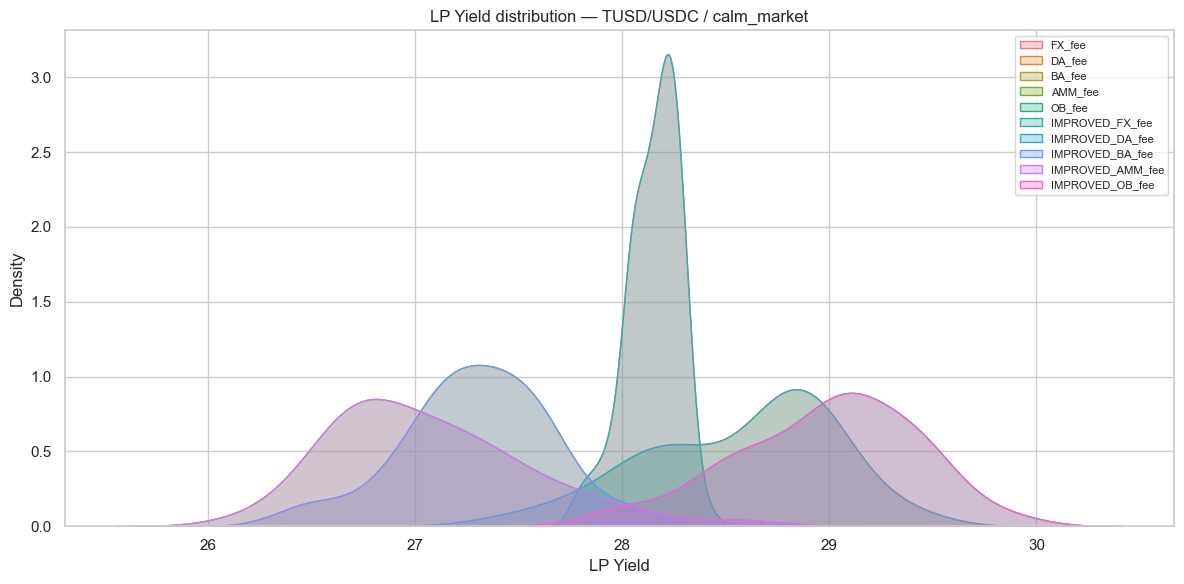

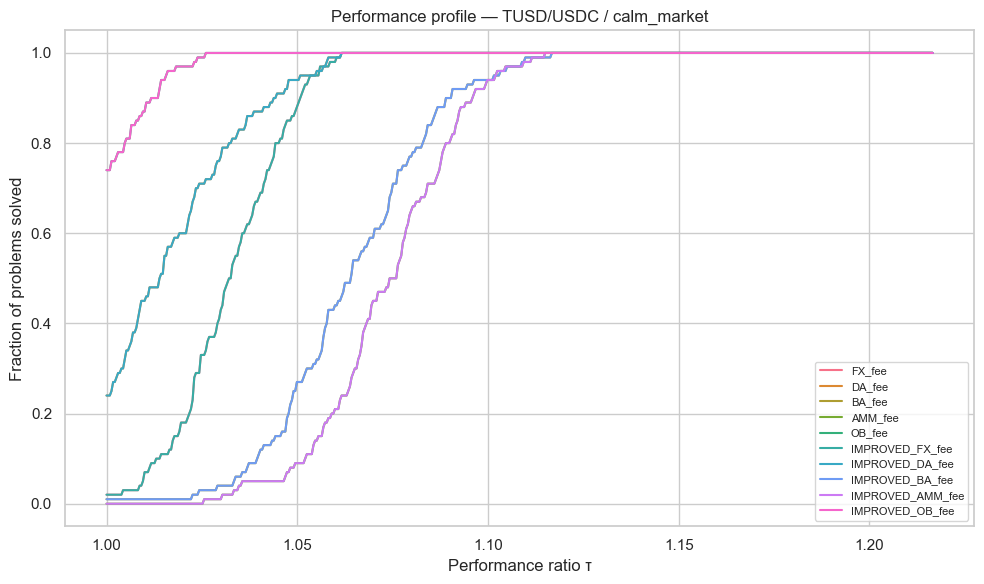

In [14]:
show_stats_for_pair_alias("TUSD/USDC", "calm_market")
plot_yield_stats("TUSD/USDC", "calm_market")
plot_performance_profile("TUSD/USDC", "calm_market")

##### bear_market


=== TUSD/USDC / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,15.83 ± 4.87,16.15 ± 3.76,1.13 ± 0.22,-8168.30 ± 291.43,723.21 ± 24.81,-56.66 ± 0.67,4285.43 ± 165.48,27.11 ± 0.50,-4499.93 ± 218.36
BA_fee,12.90 ± 4.95,15.50 ± 5.03,0.98 ± 0.22,-8173.49 ± 301.56,723.54 ± 24.98,-56.67 ± 0.75,4293.37 ± 161.10,27.27 ± 0.39,-4477.24 ± 249.82
DA_fee,7.26 ± 3.95,10.26 ± 4.66,0.83 ± 0.27,-8171.90 ± 288.22,723.39 ± 24.48,-56.67 ± 0.72,4367.55 ± 175.73,28.57 ± 0.43,-4493.20 ± 327.61
FX_fee,9.43 ± 4.11,12.03 ± 4.53,0.93 ± 0.27,-8173.04 ± 292.46,723.29 ± 24.49,-56.68 ± 0.68,4344.63 ± 155.22,28.14 ± 0.12,-4496.12 ± 276.42
IMPROVED_AMM_fee,15.83 ± 4.87,16.15 ± 3.76,1.13 ± 0.22,-8168.30 ± 291.43,723.21 ± 24.81,-56.66 ± 0.67,4285.43 ± 165.48,27.11 ± 0.50,-4499.93 ± 218.36
IMPROVED_BA_fee,12.90 ± 4.95,15.50 ± 5.03,0.98 ± 0.22,-8173.49 ± 301.56,723.54 ± 24.98,-56.67 ± 0.75,4293.37 ± 161.10,27.27 ± 0.39,-4477.24 ± 249.82
IMPROVED_DA_fee,7.26 ± 3.95,10.26 ± 4.66,0.83 ± 0.27,-8171.90 ± 288.22,723.39 ± 24.48,-56.67 ± 0.72,4367.55 ± 175.73,28.57 ± 0.43,-4493.20 ± 327.61
IMPROVED_FX_fee,9.43 ± 4.11,12.03 ± 4.53,0.93 ± 0.27,-8173.04 ± 292.46,723.29 ± 24.49,-56.68 ± 0.68,4344.63 ± 155.22,28.14 ± 0.12,-4496.12 ± 276.42
IMPROVED_OB_fee,6.64 ± 4.08,8.51 ± 4.68,0.92 ± 0.35,-8182.66 ± 287.60,723.70 ± 24.82,-56.72 ± 0.64,4392.57 ± 173.36,29.00 ± 0.45,-4533.95 ± 258.17


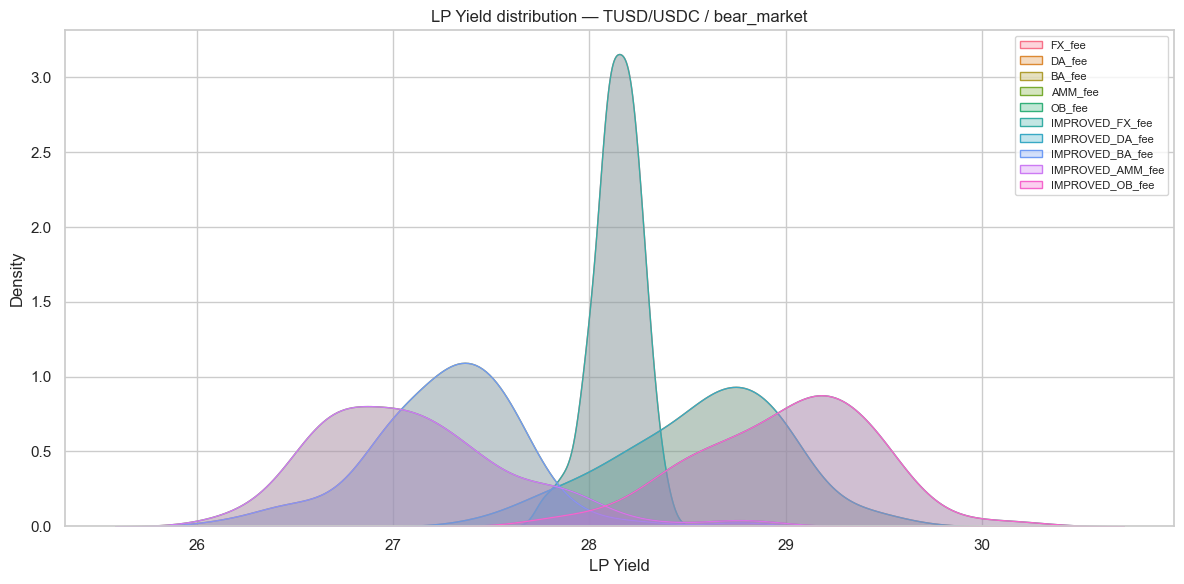

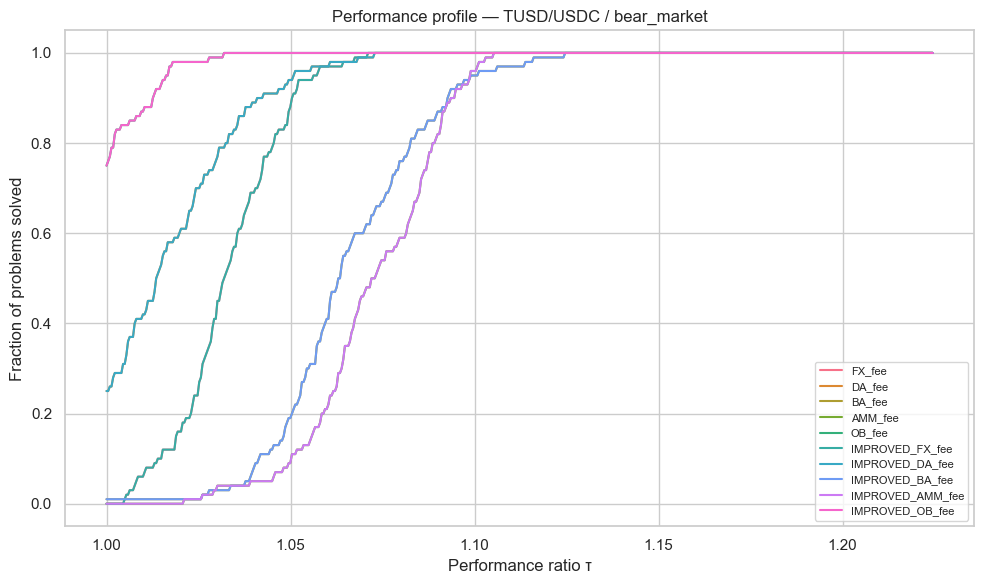

In [15]:
show_stats_for_pair_alias("TUSD/USDC", "bear_market")
plot_yield_stats("TUSD/USDC", "bear_market")
plot_performance_profile("TUSD/USDC", "bear_market")

#### TUSD/USDP

##### volatile_market


=== TUSD/USDP / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,15.58 ± 4.46,16.25 ± 4.02,1.12 ± 0.24,-8176.07 ± 284.65,723.77 ± 25.58,-56.67 ± 0.71,4282.64 ± 165.98,27.06 ± 0.47,-4493.46 ± 197.99
BA_fee,12.65 ± 5.07,15.47 ± 4.67,0.96 ± 0.23,-8177.43 ± 286.81,723.37 ± 24.81,-56.71 ± 0.75,4301.79 ± 161.87,27.34 ± 0.40,-4483.89 ± 217.29
DA_fee,7.41 ± 4.04,10.04 ± 4.08,0.87 ± 0.28,-8179.01 ± 275.29,723.08 ± 24.04,-56.74 ± 0.70,4351.89 ± 172.92,28.51 ± 0.47,-4452.07 ± 309.29
FX_fee,9.15 ± 3.98,11.63 ± 4.29,0.93 ± 0.25,-8169.00 ± 278.32,723.06 ± 24.43,-56.67 ± 0.75,4335.14 ± 152.09,28.15 ± 0.11,-4467.75 ± 248.68
IMPROVED_AMM_fee,15.58 ± 4.46,16.25 ± 4.02,1.12 ± 0.24,-8176.07 ± 284.65,723.77 ± 25.58,-56.67 ± 0.71,4282.64 ± 165.98,27.06 ± 0.47,-4493.46 ± 197.99
IMPROVED_BA_fee,12.65 ± 5.07,15.47 ± 4.67,0.96 ± 0.23,-8177.43 ± 286.81,723.37 ± 24.81,-56.71 ± 0.75,4301.79 ± 161.87,27.34 ± 0.40,-4483.89 ± 217.29
IMPROVED_DA_fee,7.41 ± 4.04,10.04 ± 4.08,0.87 ± 0.28,-8179.01 ± 275.29,723.08 ± 24.04,-56.74 ± 0.70,4351.89 ± 172.92,28.51 ± 0.47,-4452.07 ± 309.29
IMPROVED_FX_fee,9.15 ± 3.98,11.63 ± 4.29,0.93 ± 0.25,-8169.00 ± 278.32,723.06 ± 24.43,-56.67 ± 0.75,4335.14 ± 152.09,28.15 ± 0.11,-4467.75 ± 248.68
IMPROVED_OB_fee,6.36 ± 4.00,7.89 ± 4.01,0.90 ± 0.40,-8169.29 ± 293.39,723.14 ± 24.93,-56.67 ± 0.60,4362.72 ± 180.74,28.92 ± 0.44,-4492.39 ± 250.58


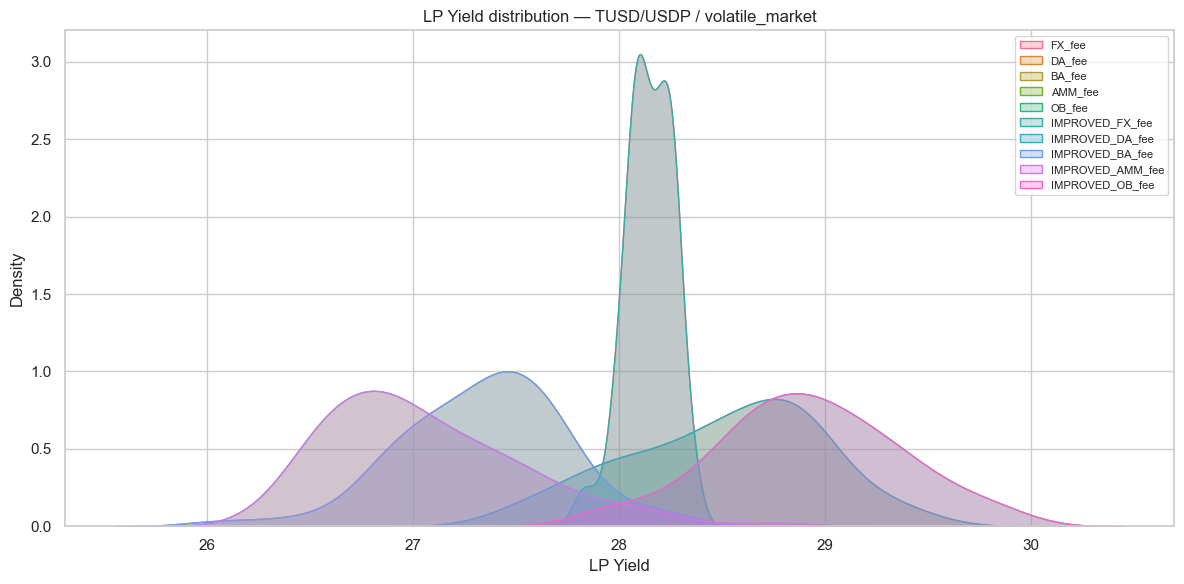

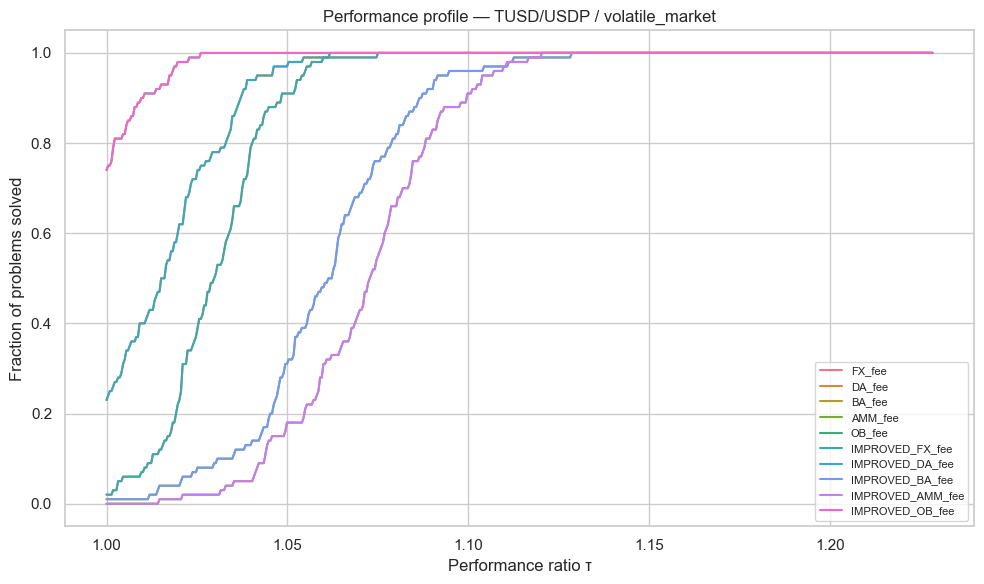

In [16]:
show_stats_for_pair_alias("TUSD/USDP", "volatile_market")
plot_yield_stats("TUSD/USDP", "volatile_market")
plot_performance_profile("TUSD/USDP", "volatile_market")

##### bull_market


=== TUSD/USDP / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,14.15 ± 5.63,13.81 ± 3.67,1.16 ± 0.29,-8172.74 ± 289.18,723.52 ± 25.23,-56.62 ± 0.69,4206.86 ± 156.49,26.91 ± 0.34,-4467.65 ± 171.10
BA_fee,9.84 ± 3.92,11.75 ± 4.10,0.98 ± 0.28,-8173.41 ± 285.87,723.36 ± 24.52,-56.63 ± 0.74,4229.07 ± 151.05,27.40 ± 0.32,-4461.27 ± 170.80
DA_fee,4.30 ± 3.36,6.51 ± 3.53,0.73 ± 0.31,-8185.08 ± 294.82,723.01 ± 24.58,-56.74 ± 0.72,4294.67 ± 168.68,28.68 ± 0.29,-4484.11 ± 235.83
FX_fee,7.16 ± 3.63,8.05 ± 3.45,1.04 ± 0.35,-8166.39 ± 284.78,722.69 ± 24.09,-56.64 ± 0.73,4266.19 ± 151.19,28.24 ± 0.10,-4472.40 ± 189.07
IMPROVED_AMM_fee,14.15 ± 5.63,13.81 ± 3.67,1.16 ± 0.29,-8172.74 ± 289.18,723.52 ± 25.23,-56.62 ± 0.69,4206.86 ± 156.49,26.91 ± 0.34,-4467.65 ± 171.10
IMPROVED_BA_fee,9.84 ± 3.92,11.75 ± 4.10,0.98 ± 0.28,-8173.41 ± 285.87,723.36 ± 24.52,-56.63 ± 0.74,4229.07 ± 151.05,27.40 ± 0.32,-4461.27 ± 170.80
IMPROVED_DA_fee,4.30 ± 3.36,6.51 ± 3.53,0.73 ± 0.31,-8185.08 ± 294.82,723.01 ± 24.58,-56.74 ± 0.72,4294.67 ± 168.68,28.68 ± 0.29,-4484.11 ± 235.83
IMPROVED_FX_fee,7.16 ± 3.63,8.05 ± 3.45,1.04 ± 0.35,-8166.39 ± 284.78,722.69 ± 24.09,-56.64 ± 0.73,4266.19 ± 151.19,28.24 ± 0.10,-4472.40 ± 189.07
IMPROVED_OB_fee,4.51 ± 3.45,5.41 ± 3.40,0.95 ± 0.48,-8182.74 ± 295.68,723.61 ± 24.36,-56.67 ± 0.66,4297.00 ± 172.61,28.84 ± 0.42,-4491.67 ± 224.03


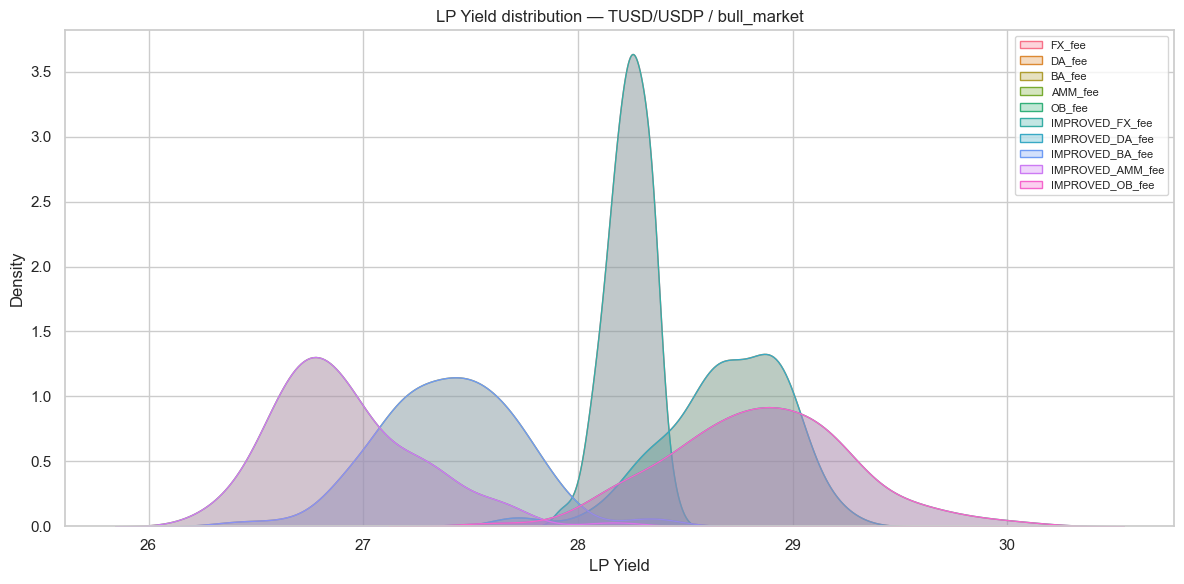

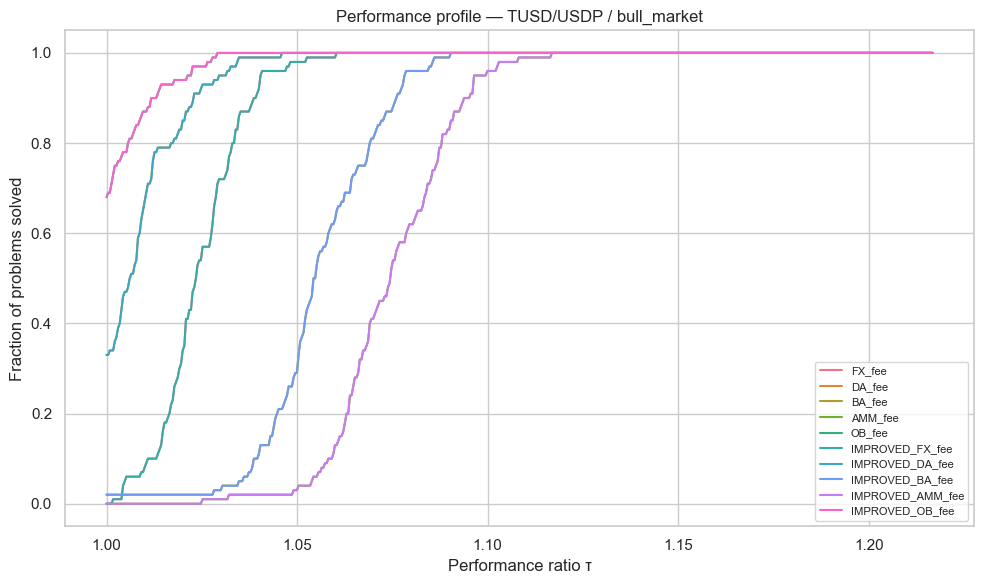

In [17]:
show_stats_for_pair_alias("TUSD/USDP", "bull_market")
plot_yield_stats("TUSD/USDP", "bull_market")
plot_performance_profile("TUSD/USDP", "bull_market")

##### calm_market


=== TUSD/USDP / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,80.51 ± 16.98,49.74 ± 8.24,1.79 ± 0.26,-8174.05 ± 285.17,722.85 ± 24.59,-56.73 ± 0.71,5344.70 ± 388.38,28.24 ± 1.12,-4311.69 ± 2174.91
BA_fee,89.69 ± 19.56,57.83 ± 10.11,1.72 ± 0.18,-8171.88 ± 307.64,722.82 ± 25.10,-56.72 ± 0.82,5263.30 ± 343.38,26.83 ± 1.01,-4348.63 ± 2084.40
DA_fee,85.85 ± 19.56,57.22 ± 10.47,1.67 ± 0.21,-8182.02 ± 295.52,722.95 ± 24.70,-56.78 ± 0.76,5265.68 ± 321.40,26.95 ± 1.06,-4018.49 ± 2712.20
FX_fee,85.27 ± 18.09,56.85 ± 9.82,1.67 ± 0.20,-8171.33 ± 303.02,722.91 ± 24.53,-56.70 ± 0.75,5266.78 ± 252.98,27.00 ± 0.19,-4161.20 ± 2416.01
IMPROVED_AMM_fee,80.51 ± 16.98,49.74 ± 8.24,1.79 ± 0.26,-8174.05 ± 285.17,722.85 ± 24.59,-56.73 ± 0.71,5344.70 ± 388.38,28.24 ± 1.12,-4311.69 ± 2174.91
IMPROVED_BA_fee,89.69 ± 19.56,57.83 ± 10.11,1.72 ± 0.18,-8171.88 ± 307.64,722.82 ± 25.10,-56.72 ± 0.82,5263.30 ± 343.38,26.83 ± 1.01,-4348.63 ± 2084.40
IMPROVED_DA_fee,85.85 ± 19.56,57.22 ± 10.47,1.67 ± 0.21,-8182.02 ± 295.52,722.95 ± 24.70,-56.78 ± 0.76,5265.68 ± 321.40,26.95 ± 1.06,-4018.49 ± 2712.20
IMPROVED_FX_fee,85.27 ± 18.09,56.85 ± 9.82,1.67 ± 0.20,-8171.33 ± 303.02,722.91 ± 24.53,-56.70 ± 0.75,5266.78 ± 252.98,27.00 ± 0.19,-4161.20 ± 2416.01
IMPROVED_OB_fee,60.36 ± 18.19,40.23 ± 10.55,1.67 ± 0.23,-8181.06 ± 301.83,723.48 ± 25.07,-56.72 ± 0.66,5476.68 ± 375.47,30.35 ± 0.49,-4303.91 ± 2358.33


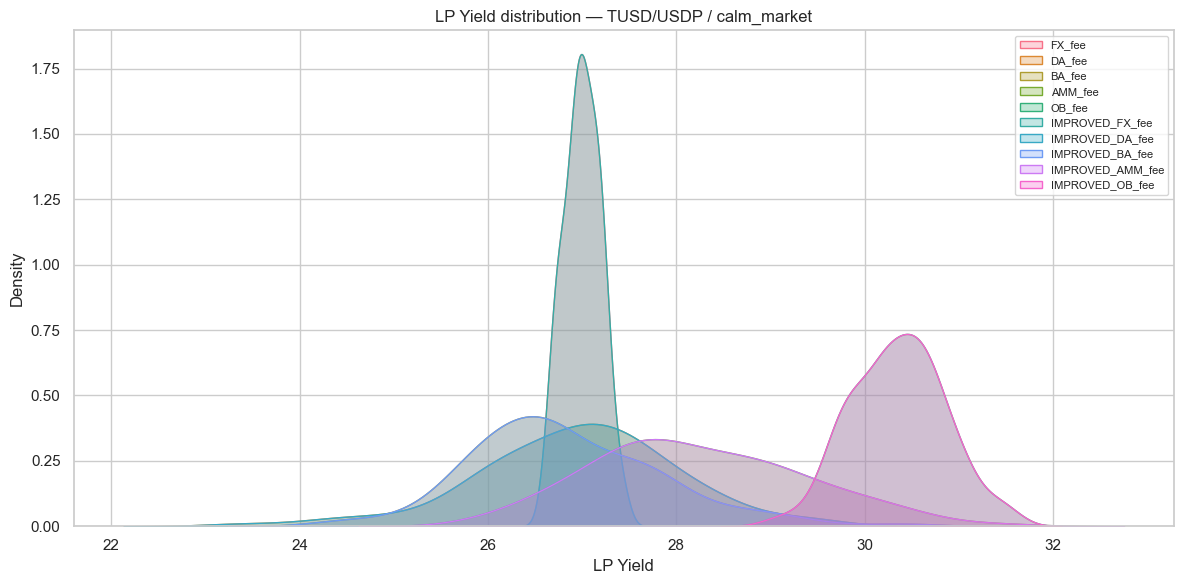

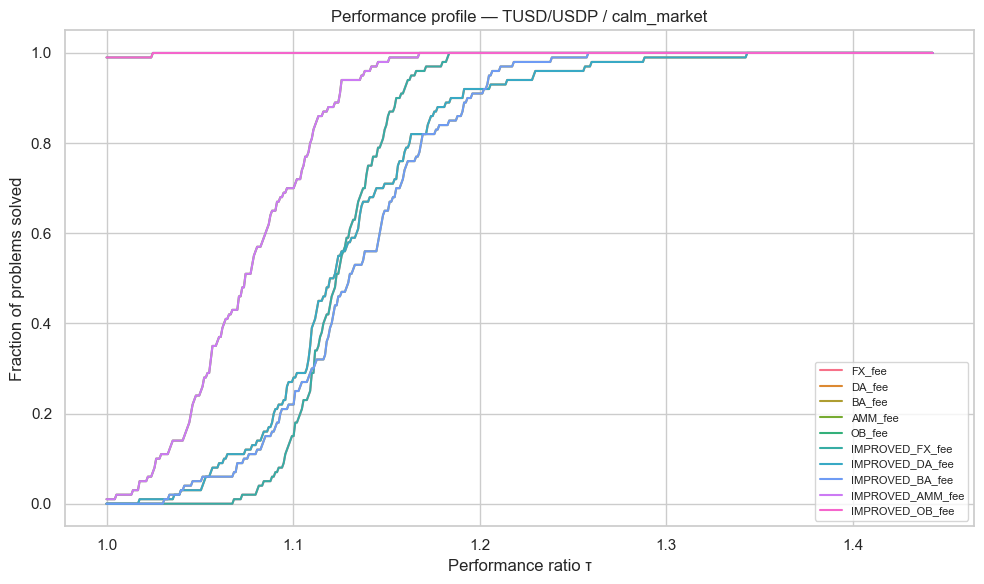

In [18]:
show_stats_for_pair_alias("TUSD/USDP", "calm_market")
plot_yield_stats("TUSD/USDP", "calm_market")
plot_performance_profile("TUSD/USDP", "calm_market")

##### bear_market


=== TUSD/USDP / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,14.39 ± 4.68,14.70 ± 3.93,1.14 ± 0.25,-8172.57 ± 284.21,723.61 ± 25.24,-56.68 ± 0.73,4221.22 ± 152.85,26.91 ± 0.35,-4483.54 ± 164.16
BA_fee,10.17 ± 4.52,13.00 ± 4.07,0.91 ± 0.27,-8172.94 ± 286.40,723.29 ± 24.65,-56.70 ± 0.70,4245.66 ± 152.84,27.36 ± 0.31,-4480.26 ± 173.42
DA_fee,5.05 ± 3.33,7.38 ± 3.77,0.79 ± 0.33,-8174.61 ± 293.84,723.21 ± 25.19,-56.72 ± 0.72,4301.43 ± 172.51,28.61 ± 0.39,-4479.06 ± 228.74
FX_fee,7.07 ± 3.89,8.99 ± 3.72,0.94 ± 0.39,-8163.64 ± 283.40,723.07 ± 24.47,-56.65 ± 0.74,4281.96 ± 148.62,28.22 ± 0.11,-4480.10 ± 185.01
IMPROVED_AMM_fee,14.39 ± 4.68,14.70 ± 3.93,1.14 ± 0.25,-8172.57 ± 284.21,723.61 ± 25.24,-56.68 ± 0.73,4221.22 ± 152.85,26.91 ± 0.35,-4483.54 ± 164.16
IMPROVED_BA_fee,10.17 ± 4.52,13.00 ± 4.07,0.91 ± 0.27,-8172.94 ± 286.40,723.29 ± 24.65,-56.70 ± 0.70,4245.66 ± 152.84,27.36 ± 0.31,-4480.26 ± 173.42
IMPROVED_DA_fee,5.05 ± 3.33,7.38 ± 3.77,0.79 ± 0.33,-8174.61 ± 293.84,723.21 ± 25.19,-56.72 ± 0.72,4301.43 ± 172.51,28.61 ± 0.39,-4479.06 ± 228.74
IMPROVED_FX_fee,7.07 ± 3.89,8.99 ± 3.72,0.94 ± 0.39,-8163.64 ± 283.40,723.07 ± 24.47,-56.65 ± 0.74,4281.96 ± 148.62,28.22 ± 0.11,-4480.10 ± 185.01
IMPROVED_OB_fee,4.64 ± 3.19,6.04 ± 3.53,0.91 ± 0.45,-8178.27 ± 296.49,723.48 ± 24.81,-56.72 ± 0.63,4313.11 ± 170.15,28.89 ± 0.41,-4501.57 ± 206.58


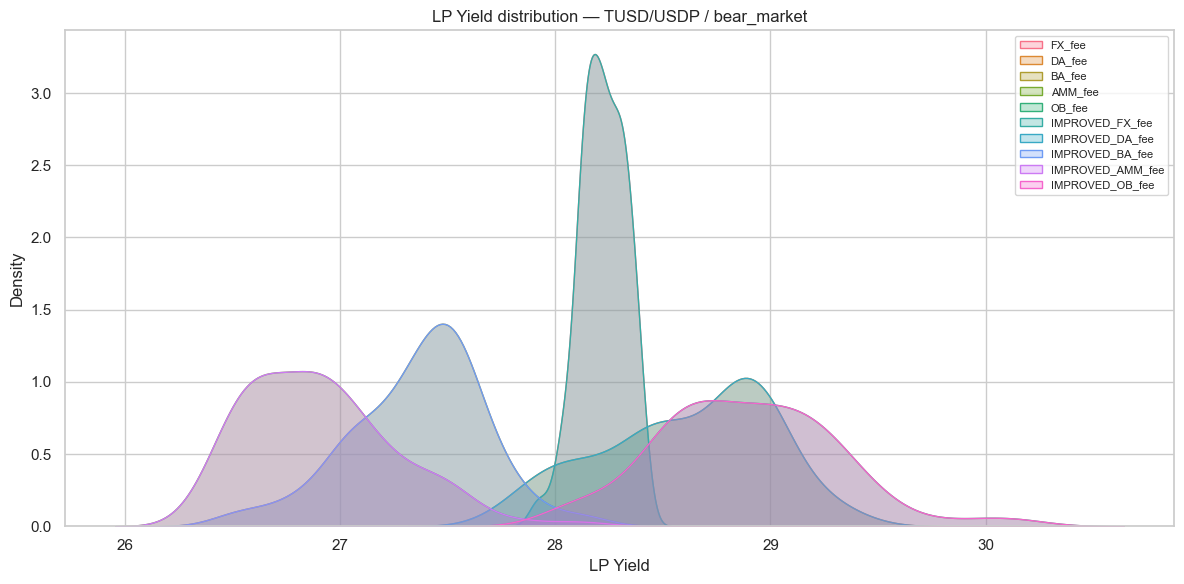

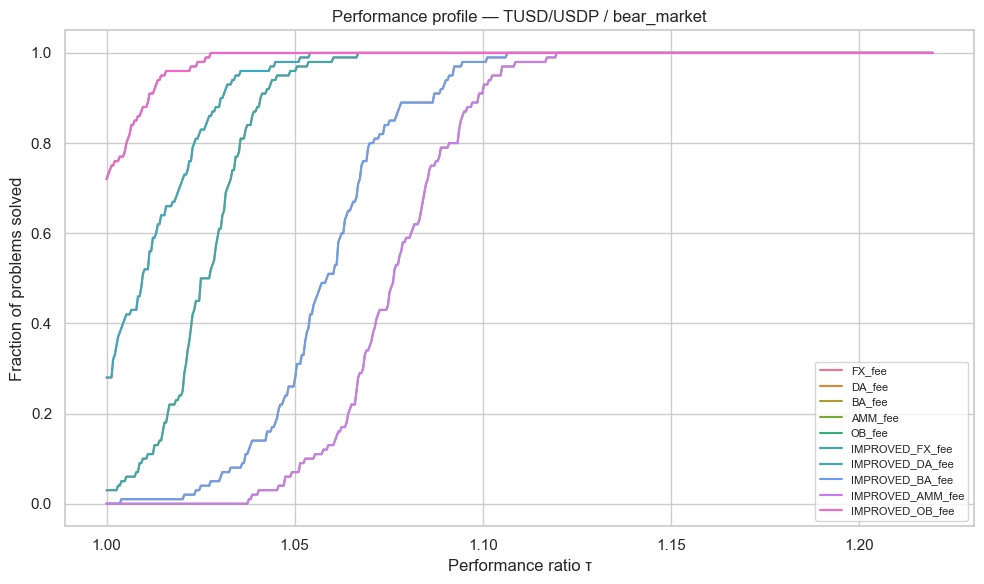

In [19]:
show_stats_for_pair_alias("TUSD/USDP", "bear_market")
plot_yield_stats("TUSD/USDP", "bear_market")
plot_performance_profile("TUSD/USDP", "bear_market")

#### USDC/USDP

##### volatile_market


=== USDC/USDP / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,15.30 ± 5.10,15.50 ± 3.84,1.14 ± 0.25,-8172.12 ± 284.98,723.57 ± 25.25,-56.66 ± 0.71,4254.66 ± 159.27,27.00 ± 0.42,-4489.77 ± 175.17
BA_fee,11.57 ± 4.79,14.35 ± 4.41,0.94 ± 0.23,-8171.49 ± 279.17,723.00 ± 24.50,-56.70 ± 0.74,4274.88 ± 153.72,27.35 ± 0.37,-4479.84 ± 189.25
DA_fee,6.11 ± 3.52,8.87 ± 3.87,0.79 ± 0.27,-8183.31 ± 280.33,723.34 ± 24.39,-56.75 ± 0.69,4331.83 ± 169.38,28.56 ± 0.44,-4469.95 ± 263.34
FX_fee,8.27 ± 3.85,10.53 ± 3.88,0.92 ± 0.31,-8174.51 ± 283.18,723.35 ± 24.59,-56.69 ± 0.74,4314.76 ± 152.58,28.18 ± 0.11,-4478.50 ± 220.88
IMPROVED_AMM_fee,15.30 ± 5.10,15.50 ± 3.84,1.14 ± 0.25,-8172.12 ± 284.98,723.57 ± 25.25,-56.66 ± 0.71,4254.66 ± 159.27,27.00 ± 0.42,-4489.77 ± 175.17
IMPROVED_BA_fee,11.57 ± 4.79,14.35 ± 4.41,0.94 ± 0.23,-8171.49 ± 279.17,723.00 ± 24.50,-56.70 ± 0.74,4274.88 ± 153.72,27.35 ± 0.37,-4479.84 ± 189.25
IMPROVED_DA_fee,6.11 ± 3.52,8.87 ± 3.87,0.79 ± 0.27,-8183.31 ± 280.33,723.34 ± 24.39,-56.75 ± 0.69,4331.83 ± 169.38,28.56 ± 0.44,-4469.95 ± 263.34
IMPROVED_FX_fee,8.27 ± 3.85,10.53 ± 3.88,0.92 ± 0.31,-8174.51 ± 283.18,723.35 ± 24.59,-56.69 ± 0.74,4314.76 ± 152.58,28.18 ± 0.11,-4478.50 ± 220.88
IMPROVED_OB_fee,5.39 ± 3.86,7.11 ± 3.85,0.85 ± 0.43,-8180.38 ± 290.33,723.62 ± 24.53,-56.71 ± 0.66,4343.93 ± 175.50,28.91 ± 0.44,-4497.23 ± 227.80


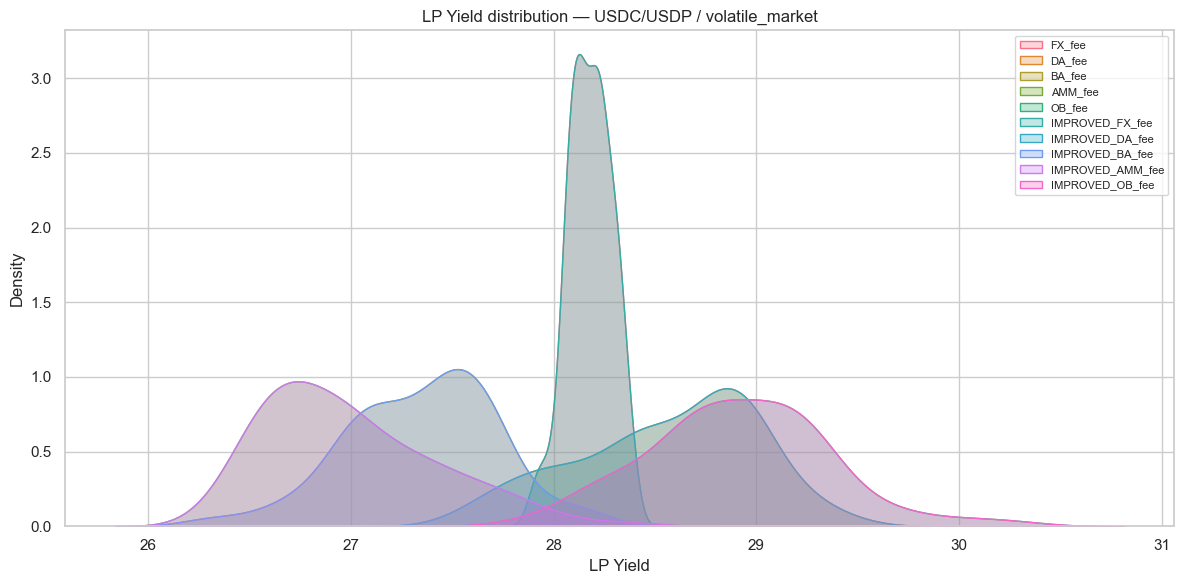

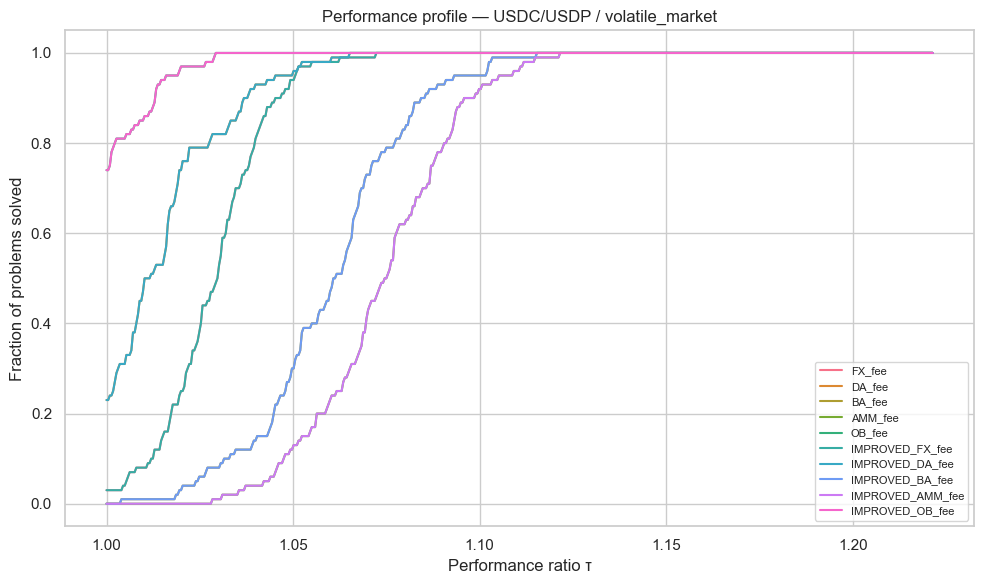

In [20]:
show_stats_for_pair_alias("USDC/USDP", "volatile_market")
plot_yield_stats("USDC/USDP", "volatile_market")
plot_performance_profile("USDC/USDP", "volatile_market")

##### bull_market


=== USDC/USDP / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,13.98 ± 4.68,15.32 ± 3.86,1.06 ± 0.24,-8171.26 ± 289.54,723.23 ± 25.11,-56.69 ± 0.70,4240.94 ± 159.56,26.97 ± 0.38,-4488.58 ± 174.20
BA_fee,10.39 ± 4.30,13.62 ± 4.35,0.90 ± 0.24,-8170.05 ± 279.25,723.18 ± 24.32,-56.69 ± 0.72,4261.15 ± 147.97,27.38 ± 0.35,-4473.63 ± 184.27
DA_fee,5.62 ± 3.23,8.20 ± 3.83,0.79 ± 0.30,-8172.71 ± 293.68,722.85 ± 24.73,-56.73 ± 0.70,4314.50 ± 172.02,28.58 ± 0.43,-4466.35 ± 246.38
FX_fee,7.66 ± 3.58,9.78 ± 3.88,0.93 ± 0.27,-8167.95 ± 278.97,723.31 ± 24.38,-56.66 ± 0.71,4298.94 ± 149.95,28.20 ± 0.11,-4474.94 ± 201.20
IMPROVED_AMM_fee,13.98 ± 4.68,15.32 ± 3.86,1.06 ± 0.24,-8171.26 ± 289.54,723.23 ± 25.11,-56.69 ± 0.70,4240.94 ± 159.56,26.97 ± 0.38,-4488.58 ± 174.20
IMPROVED_BA_fee,10.39 ± 4.30,13.62 ± 4.35,0.90 ± 0.24,-8170.05 ± 279.25,723.18 ± 24.32,-56.69 ± 0.72,4261.15 ± 147.97,27.38 ± 0.35,-4473.63 ± 184.27
IMPROVED_DA_fee,5.62 ± 3.23,8.20 ± 3.83,0.79 ± 0.30,-8172.71 ± 293.68,722.85 ± 24.73,-56.73 ± 0.70,4314.50 ± 172.02,28.58 ± 0.43,-4466.35 ± 246.38
IMPROVED_FX_fee,7.66 ± 3.58,9.78 ± 3.88,0.93 ± 0.27,-8167.95 ± 278.97,723.31 ± 24.38,-56.66 ± 0.71,4298.94 ± 149.95,28.20 ± 0.11,-4474.94 ± 201.20
IMPROVED_OB_fee,5.59 ± 3.93,6.66 ± 3.52,0.95 ± 0.44,-8176.19 ± 285.87,723.27 ± 24.23,-56.72 ± 0.59,4330.08 ± 165.76,28.90 ± 0.46,-4498.88 ± 210.51


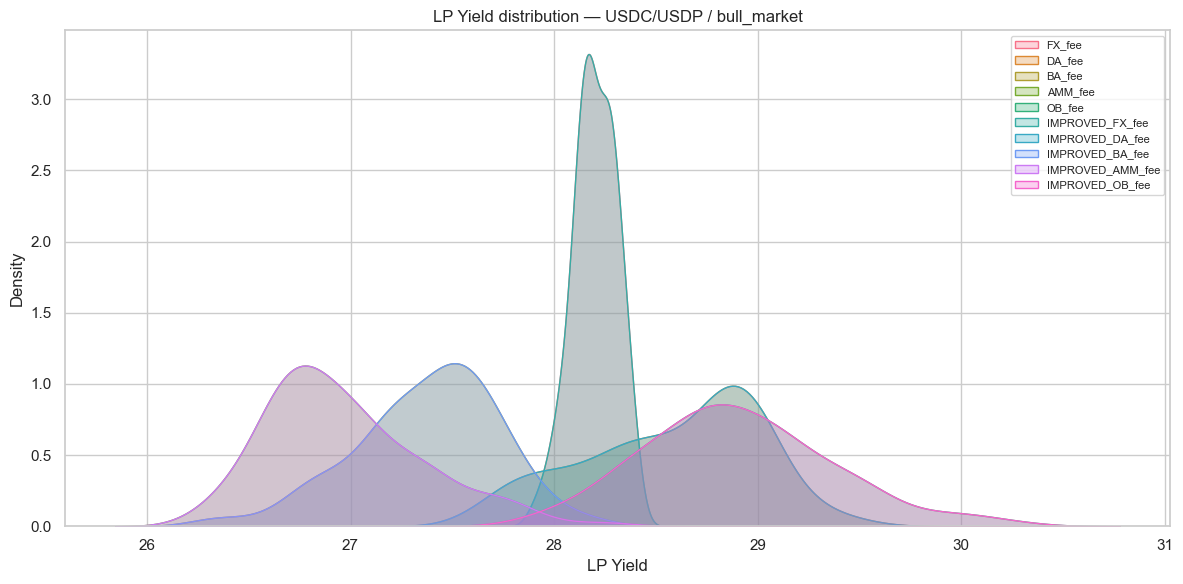

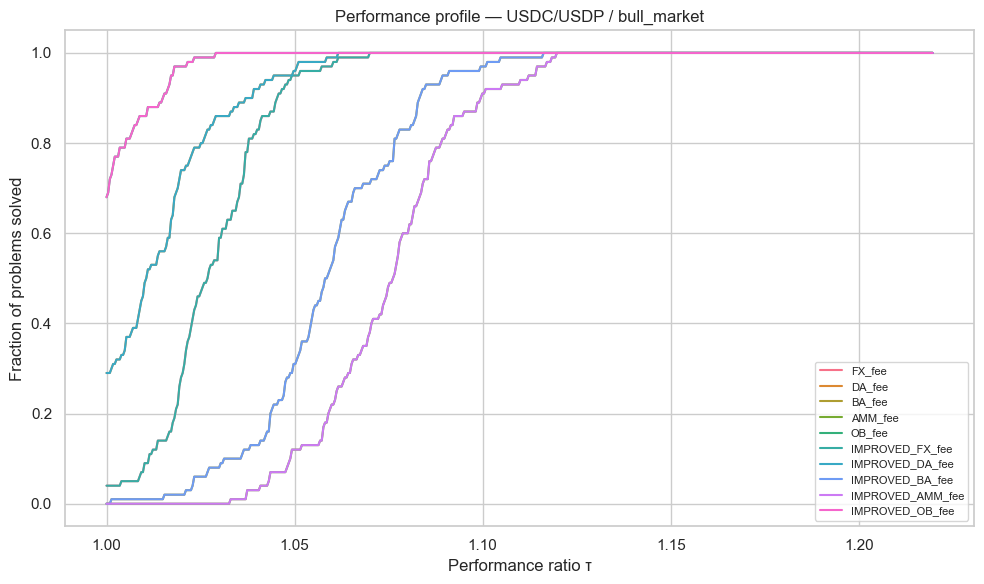

In [21]:
show_stats_for_pair_alias("USDC/USDP", "bull_market")
plot_yield_stats("USDC/USDP", "bull_market")
plot_performance_profile("USDC/USDP", "bull_market")

##### calm_market


=== USDC/USDP / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,83.46 ± 18.67,50.38 ± 8.38,1.82 ± 0.23,-8174.12 ± 304.43,723.59 ± 25.10,-56.65 ± 0.74,5377.89 ± 394.71,28.28 ± 1.13,-4330.55 ± 2297.16
BA_fee,94.40 ± 17.28,58.75 ± 9.29,1.78 ± 0.17,-8169.52 ± 311.48,722.80 ± 25.28,-56.69 ± 0.80,5280.34 ± 336.61,26.77 ± 1.03,-4342.08 ± 2213.51
DA_fee,89.87 ± 21.64,58.23 ± 10.43,1.71 ± 0.21,-8174.54 ± 305.99,722.64 ± 24.82,-56.74 ± 0.80,5289.33 ± 326.01,26.93 ± 1.10,-4012.84 ± 2858.14
FX_fee,91.96 ± 18.98,58.52 ± 9.62,1.74 ± 0.19,-8172.46 ± 305.21,723.26 ± 24.73,-56.67 ± 0.79,5307.63 ± 247.95,26.95 ± 0.19,-4192.29 ± 2563.42
IMPROVED_AMM_fee,83.46 ± 18.67,50.38 ± 8.38,1.82 ± 0.23,-8174.12 ± 304.43,723.59 ± 25.10,-56.65 ± 0.74,5377.89 ± 394.71,28.28 ± 1.13,-4330.55 ± 2297.16
IMPROVED_BA_fee,94.40 ± 17.28,58.75 ± 9.29,1.78 ± 0.17,-8169.52 ± 311.48,722.80 ± 25.28,-56.69 ± 0.80,5280.34 ± 336.61,26.77 ± 1.03,-4342.08 ± 2213.51
IMPROVED_DA_fee,89.87 ± 21.64,58.23 ± 10.43,1.71 ± 0.21,-8174.54 ± 305.99,722.64 ± 24.82,-56.74 ± 0.80,5289.33 ± 326.01,26.93 ± 1.10,-4012.84 ± 2858.14
IMPROVED_FX_fee,91.96 ± 18.98,58.52 ± 9.62,1.74 ± 0.19,-8172.46 ± 305.21,723.26 ± 24.73,-56.67 ± 0.79,5307.63 ± 247.95,26.95 ± 0.19,-4192.29 ± 2563.42
IMPROVED_OB_fee,63.38 ± 19.09,41.51 ± 10.80,1.69 ± 0.20,-8176.86 ± 302.65,723.65 ± 24.90,-56.67 ± 0.69,5521.39 ± 382.20,30.38 ± 0.52,-4312.44 ± 2499.73


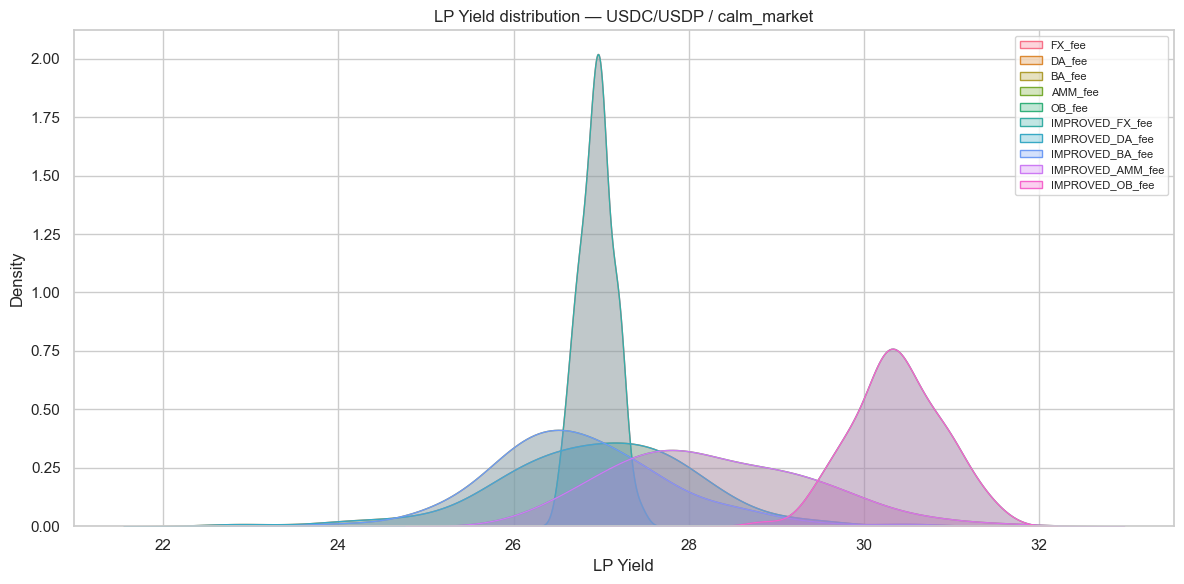

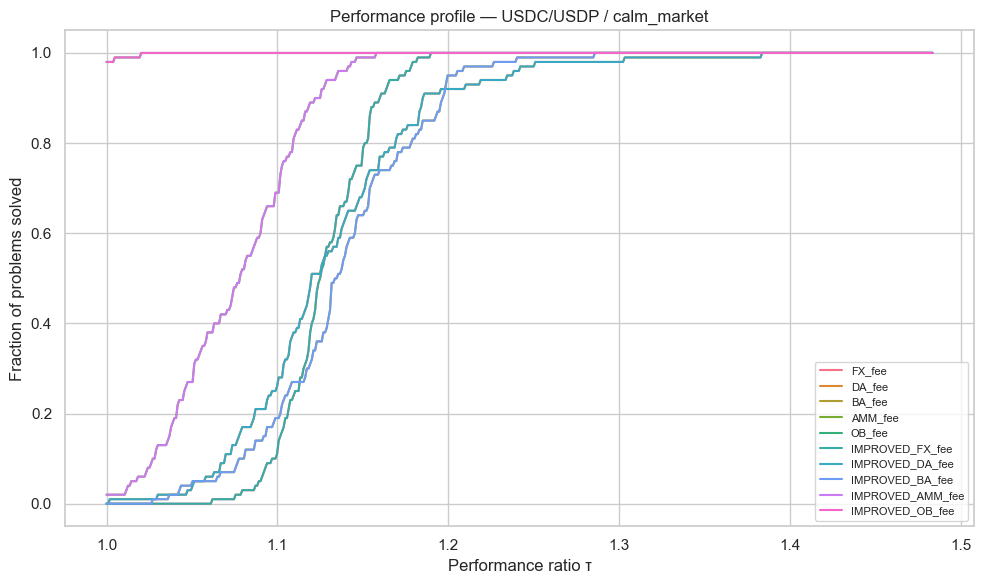

In [22]:
show_stats_for_pair_alias("USDC/USDP", "calm_market")
plot_yield_stats("USDC/USDP", "calm_market")
plot_performance_profile("USDC/USDP", "calm_market")

##### bear_market


=== USDC/USDP / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,15.65 ± 5.27,15.40 ± 3.82,1.17 ± 0.27,-8178.54 ± 285.21,723.67 ± 25.05,-56.71 ± 0.69,4248.05 ± 156.60,26.97 ± 0.40,-4492.75 ± 174.49
BA_fee,11.24 ± 4.51,13.72 ± 4.15,0.96 ± 0.26,-8172.36 ± 273.96,723.32 ± 24.13,-56.69 ± 0.69,4264.14 ± 145.90,27.36 ± 0.35,-4476.81 ± 176.91
DA_fee,5.63 ± 3.35,8.43 ± 3.80,0.76 ± 0.27,-8180.78 ± 292.99,723.20 ± 25.24,-56.76 ± 0.70,4322.21 ± 173.85,28.58 ± 0.41,-4473.99 ± 246.31
FX_fee,8.33 ± 4.14,10.09 ± 3.76,0.96 ± 0.34,-8169.13 ± 283.40,723.14 ± 24.56,-56.68 ± 0.72,4304.59 ± 149.82,28.19 ± 0.11,-4481.48 ± 204.92
IMPROVED_AMM_fee,15.65 ± 5.27,15.40 ± 3.82,1.17 ± 0.27,-8178.54 ± 285.21,723.67 ± 25.05,-56.71 ± 0.69,4248.05 ± 156.60,26.97 ± 0.40,-4492.75 ± 174.49
IMPROVED_BA_fee,11.24 ± 4.51,13.72 ± 4.15,0.96 ± 0.26,-8172.36 ± 273.96,723.32 ± 24.13,-56.69 ± 0.69,4264.14 ± 145.90,27.36 ± 0.35,-4476.81 ± 176.91
IMPROVED_DA_fee,5.63 ± 3.35,8.43 ± 3.80,0.76 ± 0.27,-8180.78 ± 292.99,723.20 ± 25.24,-56.76 ± 0.70,4322.21 ± 173.85,28.58 ± 0.41,-4473.99 ± 246.31
IMPROVED_FX_fee,8.33 ± 4.14,10.09 ± 3.76,0.96 ± 0.34,-8169.13 ± 283.40,723.14 ± 24.56,-56.68 ± 0.72,4304.59 ± 149.82,28.19 ± 0.11,-4481.48 ± 204.92
IMPROVED_OB_fee,5.71 ± 4.32,6.78 ± 3.72,0.91 ± 0.37,-8183.21 ± 293.55,723.58 ± 24.48,-56.74 ± 0.65,4335.76 ± 173.73,28.91 ± 0.42,-4504.94 ± 223.20


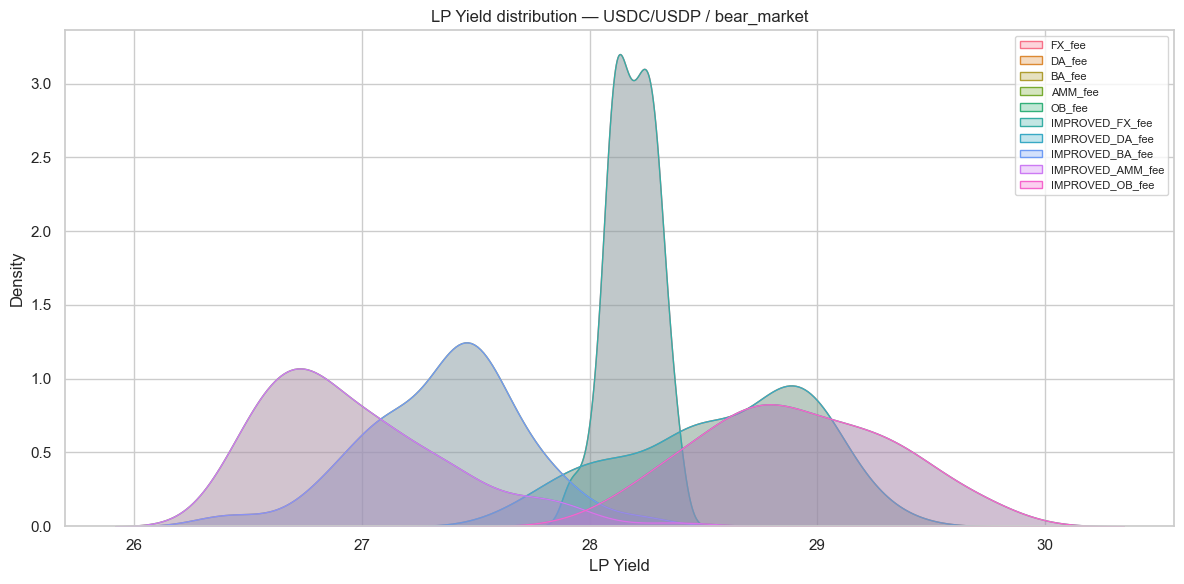

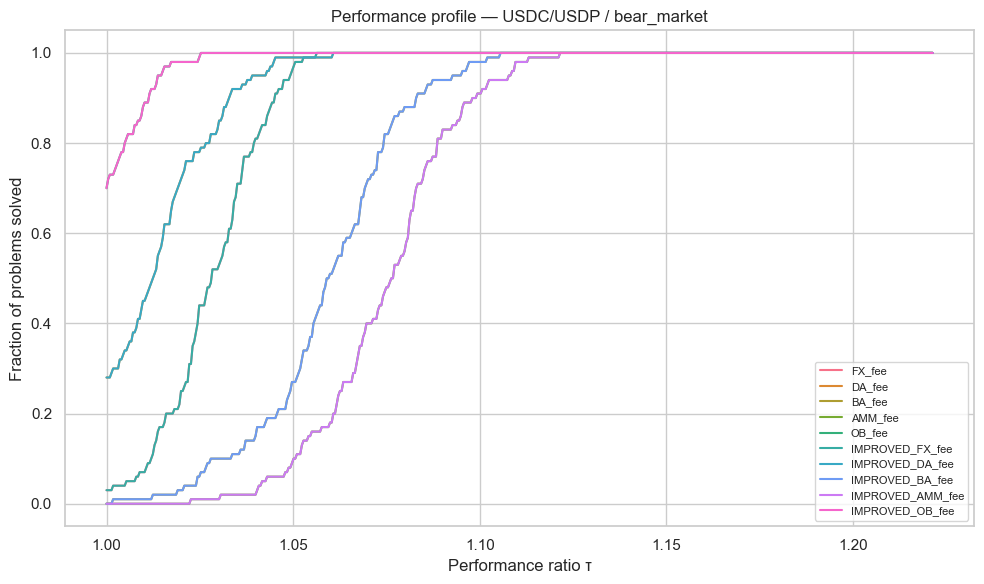

In [23]:
show_stats_for_pair_alias("USDC/USDP", "bear_market")
plot_yield_stats("USDC/USDP", "bear_market")
plot_performance_profile("USDC/USDP", "bear_market")

### Non-stable / Stable

#### USDC/RAD

##### volatile_market


=== USDC/RAD / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,829.80 ± 91.74,207.70 ± 18.34,3.81 ± 0.21,-8263.23 ± 321.48,723.03 ± 25.68,-56.37 ± 0.80,10906.65 ± 1121.92,29.86 ± 1.61,11672.74 ± 26743.35
BA_fee,969.43 ± 113.55,245.83 ± 20.34,3.76 ± 0.17,-8246.75 ± 322.72,722.90 ± 24.82,-56.27 ± 0.97,10446.04 ± 1217.10,25.83 ± 1.94,11131.71 ± 25631.35
DA_fee,1002.84 ± 115.01,256.23 ± 22.51,3.74 ± 0.20,-8268.20 ± 314.61,723.29 ± 25.19,-56.40 ± 0.93,9432.94 ± 645.19,22.80 ± 1.40,13789.39 ± 28268.00
FX_fee,996.21 ± 111.25,254.60 ± 22.02,3.74 ± 0.19,-8257.49 ± 322.74,723.01 ± 25.08,-56.34 ± 0.88,9890.97 ± 586.83,23.98 ± 0.18,12664.79 ± 27291.97
IMPROVED_AMM_fee,829.80 ± 91.74,207.70 ± 18.34,3.81 ± 0.21,-8263.23 ± 321.48,723.03 ± 25.68,-56.37 ± 0.80,10906.65 ± 1121.92,29.86 ± 1.61,11672.74 ± 26743.35
IMPROVED_BA_fee,969.43 ± 113.55,245.83 ± 20.34,3.76 ± 0.17,-8246.75 ± 322.72,722.90 ± 24.82,-56.27 ± 0.97,10446.04 ± 1217.10,25.83 ± 1.94,11131.71 ± 25631.35
IMPROVED_DA_fee,1002.84 ± 115.01,256.23 ± 22.51,3.74 ± 0.20,-8268.20 ± 314.61,723.29 ± 25.19,-56.40 ± 0.93,9432.94 ± 645.19,22.80 ± 1.40,13789.39 ± 28268.00
IMPROVED_FX_fee,996.21 ± 111.25,254.60 ± 22.02,3.74 ± 0.19,-8257.49 ± 322.74,723.01 ± 25.08,-56.34 ± 0.88,9890.97 ± 586.83,23.98 ± 0.18,12664.79 ± 27291.97
IMPROVED_OB_fee,731.76 ± 111.34,183.45 ± 22.50,3.79 ± 0.22,-8257.78 ± 329.12,723.02 ± 25.34,-56.34 ± 0.84,11207.16 ± 944.10,33.03 ± 0.32,11758.40 ± 26887.89


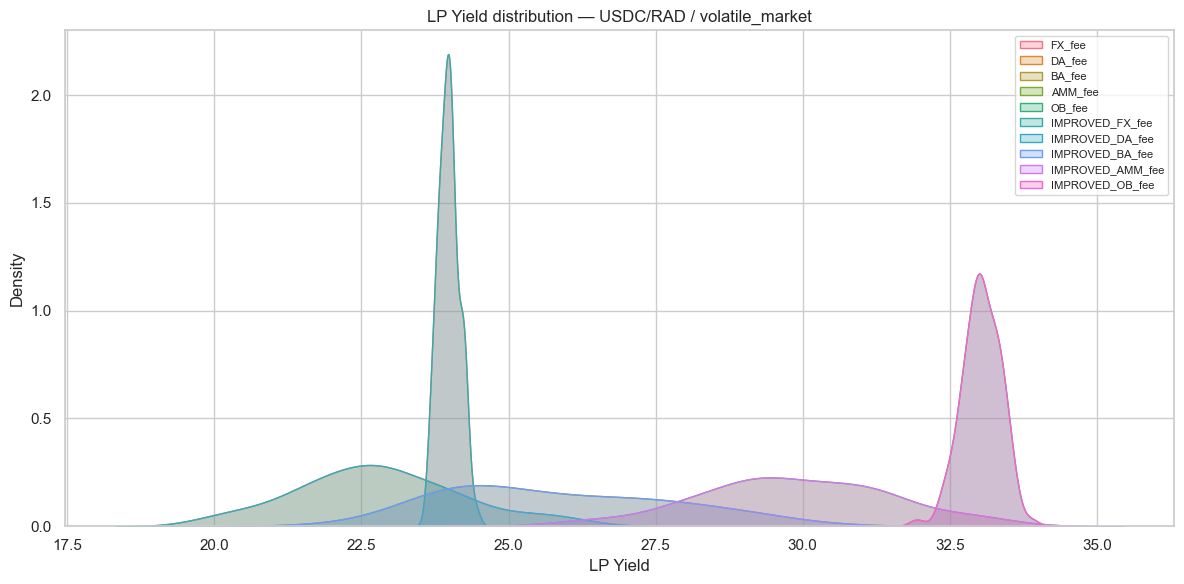

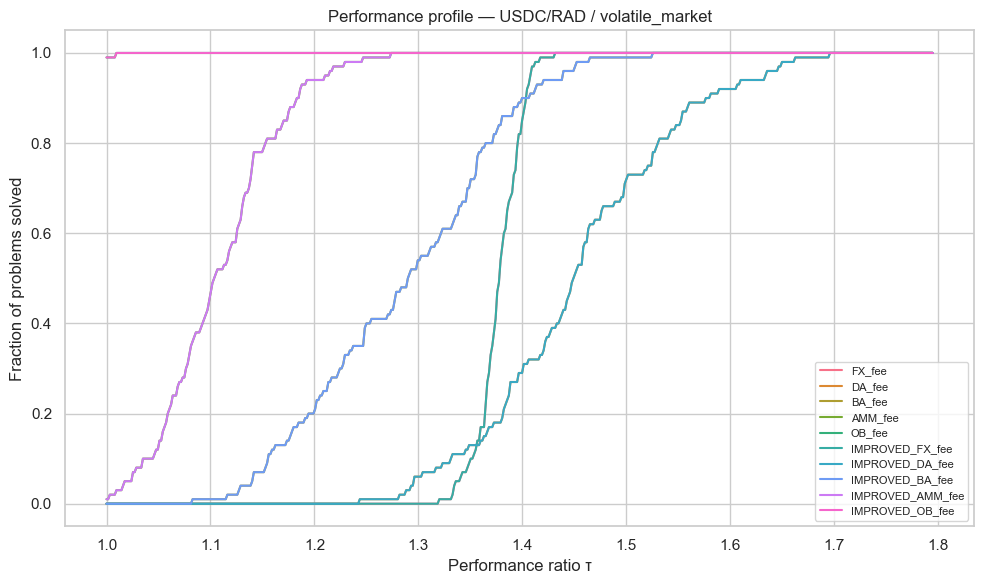

In [24]:
show_stats_for_pair_alias("USDC/RAD", "volatile_market")
plot_yield_stats("USDC/RAD", "volatile_market")
plot_performance_profile("USDC/RAD", "volatile_market")

##### bull_market


=== USDC/RAD / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,5112.75 ± 434.11,572.24 ± 28.28,7.00 ± 0.27,-8318.40 ± 359.70,723.65 ± 24.74,-56.33 ± 1.30,24613.44 ± 2257.32,28.01 ± 1.27,35171.07 ± 83156.00
BA_fee,5963.39 ± 472.87,675.60 ± 31.24,6.94 ± 0.23,-8282.61 ± 368.82,723.19 ± 24.34,-56.11 ± 1.26,22201.46 ± 2270.62,22.03 ± 1.38,35146.54 ± 81334.97
DA_fee,6165.65 ± 509.93,700.08 ± 32.05,6.93 ± 0.24,-8296.25 ± 341.28,722.95 ± 23.78,-56.24 ± 1.35,20493.88 ± 1278.75,19.80 ± 1.24,38946.37 ± 85616.12
FX_fee,6145.48 ± 495.77,697.27 ± 31.87,6.93 ± 0.24,-8296.30 ± 350.99,723.11 ± 24.19,-56.22 ± 1.29,21150.80 ± 1154.23,20.47 ± 0.20,37322.69 ± 83831.13
IMPROVED_AMM_fee,5112.75 ± 434.11,572.24 ± 28.28,7.00 ± 0.27,-8318.40 ± 359.70,723.65 ± 24.74,-56.33 ± 1.30,24613.44 ± 2257.32,28.01 ± 1.27,35171.07 ± 83156.00
IMPROVED_BA_fee,5963.39 ± 472.87,675.60 ± 31.24,6.94 ± 0.23,-8282.61 ± 368.82,723.19 ± 24.34,-56.11 ± 1.26,22201.46 ± 2270.62,22.03 ± 1.38,35146.54 ± 81334.97
IMPROVED_DA_fee,6165.65 ± 509.93,700.08 ± 32.05,6.93 ± 0.24,-8296.25 ± 341.28,722.95 ± 23.78,-56.24 ± 1.35,20493.88 ± 1278.75,19.80 ± 1.24,38946.37 ± 85616.12
IMPROVED_FX_fee,6145.48 ± 495.77,697.27 ± 31.87,6.93 ± 0.24,-8296.30 ± 350.99,723.11 ± 24.19,-56.22 ± 1.29,21150.80 ± 1154.23,20.47 ± 0.20,37322.69 ± 83831.13
IMPROVED_OB_fee,4487.75 ± 431.96,508.75 ± 32.49,6.93 ± 0.26,-8284.34 ± 353.04,722.79 ± 24.67,-56.16 ± 1.20,26329.84 ± 1816.44,33.13 ± 0.21,34555.21 ± 83491.73


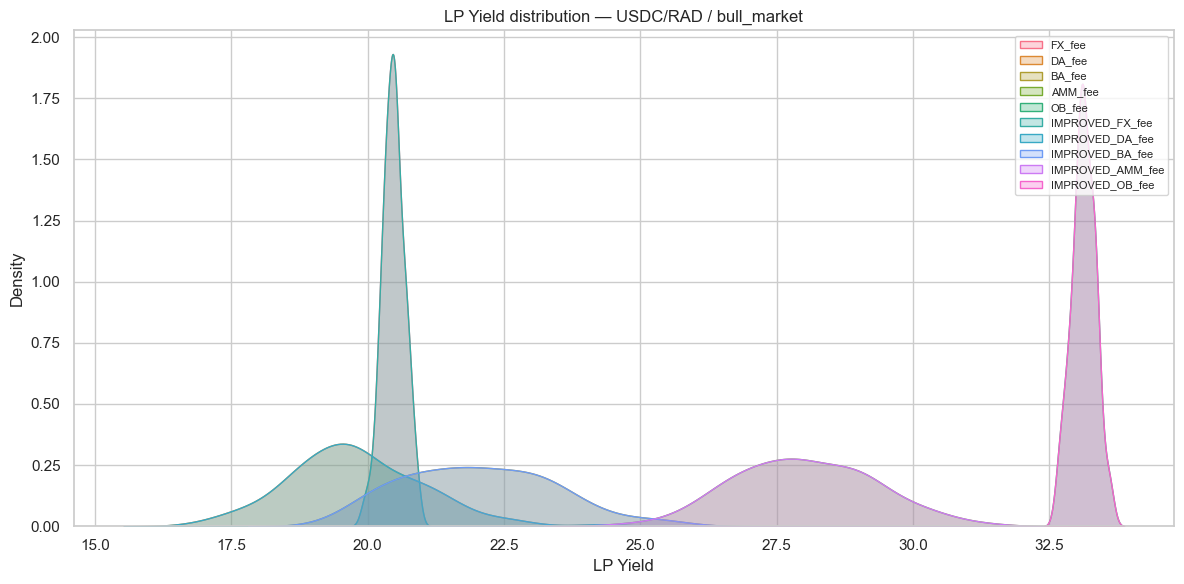

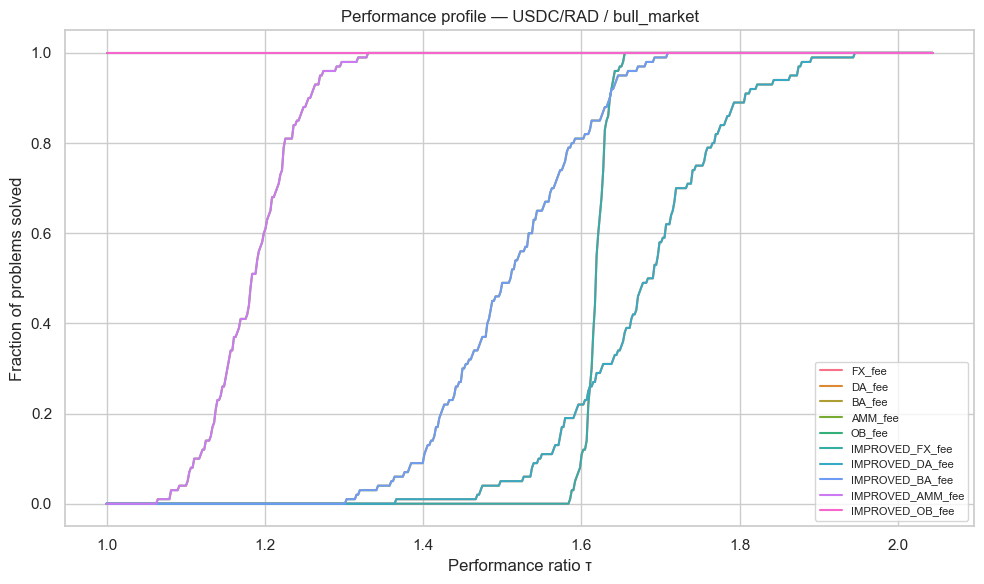

In [25]:
show_stats_for_pair_alias("USDC/RAD", "bull_market")
plot_yield_stats("USDC/RAD", "bull_market")
plot_performance_profile("USDC/RAD", "bull_market")

##### calm_market


=== USDC/RAD / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,891.25 ± 100.17,214.96 ± 17.10,3.95 ± 0.23,-8182.08 ± 311.07,723.28 ± 24.42,-56.66 ± 0.94,10882.54 ± 975.46,29.38 ± 1.50,-2310.49 ± 14639.16
BA_fee,1044.47 ± 113.42,257.29 ± 20.16,3.88 ± 0.20,-8178.08 ± 318.01,722.51 ± 24.58,-56.69 ± 1.04,10193.27 ± 834.28,24.68 ± 1.40,-2313.04 ± 13973.73
DA_fee,1084.52 ± 116.24,268.63 ± 22.47,3.87 ± 0.20,-8195.69 ± 309.17,723.28 ± 24.94,-56.75 ± 0.93,9934.79 ± 773.72,23.41 ± 1.49,-1250.91 ± 15793.02
FX_fee,1079.10 ± 114.10,265.80 ± 22.11,3.88 ± 0.19,-8186.25 ± 303.03,723.11 ± 24.64,-56.71 ± 0.96,10037.50 ± 565.18,23.79 ± 0.18,-1720.76 ± 14934.70
IMPROVED_AMM_fee,891.25 ± 100.17,214.96 ± 17.10,3.95 ± 0.23,-8182.08 ± 311.07,723.28 ± 24.42,-56.66 ± 0.94,10882.54 ± 975.46,29.38 ± 1.50,-2310.49 ± 14639.16
IMPROVED_BA_fee,1044.47 ± 113.42,257.29 ± 20.16,3.88 ± 0.20,-8178.08 ± 318.01,722.51 ± 24.58,-56.69 ± 1.04,10193.27 ± 834.28,24.68 ± 1.40,-2313.04 ± 13973.73
IMPROVED_DA_fee,1084.52 ± 116.24,268.63 ± 22.47,3.87 ± 0.20,-8195.69 ± 309.17,723.28 ± 24.94,-56.75 ± 0.93,9934.79 ± 773.72,23.41 ± 1.49,-1250.91 ± 15793.02
IMPROVED_FX_fee,1079.10 ± 114.10,265.80 ± 22.11,3.88 ± 0.19,-8186.25 ± 303.03,723.11 ± 24.64,-56.71 ± 0.96,10037.50 ± 565.18,23.79 ± 0.18,-1720.76 ± 14934.70
IMPROVED_OB_fee,769.01 ± 103.00,190.92 ± 21.73,3.86 ± 0.22,-8181.43 ± 309.20,723.06 ± 24.67,-56.67 ± 0.81,11374.00 ± 887.80,33.09 ± 0.32,-2491.04 ± 14882.51


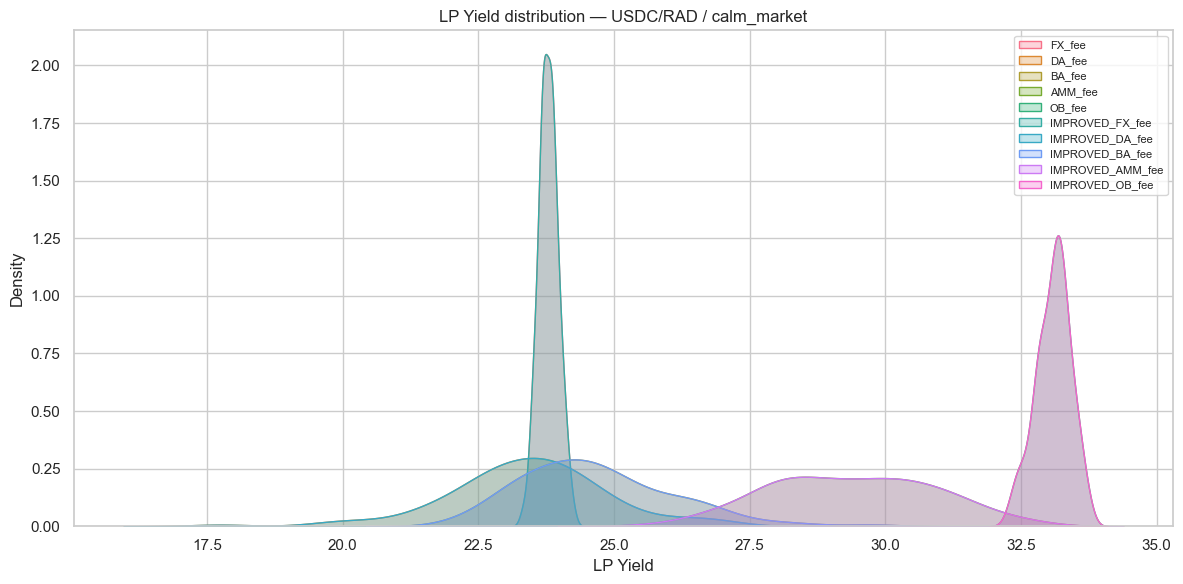

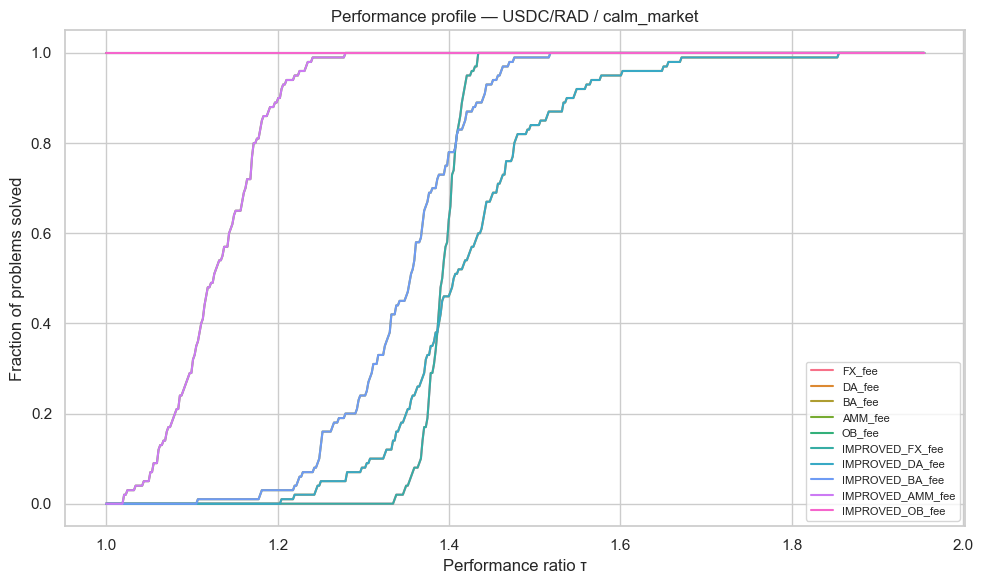

In [26]:
show_stats_for_pair_alias("USDC/RAD", "calm_market")
plot_yield_stats("USDC/RAD", "calm_market")
plot_performance_profile("USDC/RAD", "calm_market")

##### bear_market


=== USDC/RAD / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1756.70 ± 164.81,319.41 ± 20.30,4.97 ± 0.22,-8127.33 ± 325.43,723.40 ± 24.27,-57.09 ± 1.05,14497.95 ± 1150.28,29.22 ± 1.33,6863.93 ± 34194.50
BA_fee,2075.95 ± 172.77,380.72 ± 22.96,4.93 ± 0.19,-8120.04 ± 321.45,723.05 ± 24.51,-57.08 ± 0.98,13435.28 ± 948.06,23.90 ± 1.62,6780.13 ± 33271.35
DA_fee,2144.44 ± 194.94,397.75 ± 26.42,4.89 ± 0.21,-8124.58 ± 308.74,722.68 ± 23.81,-57.14 ± 1.15,12942.81 ± 1349.48,22.30 ± 2.00,8418.08 ± 36162.81
FX_fee,2130.42 ± 190.47,394.80 ± 24.97,4.89 ± 0.20,-8115.37 ± 320.26,723.31 ± 24.57,-57.02 ± 1.09,12997.01 ± 684.20,22.52 ± 0.17,7912.36 ± 34856.52
IMPROVED_AMM_fee,1756.70 ± 164.81,319.41 ± 20.30,4.97 ± 0.22,-8127.33 ± 325.43,723.40 ± 24.27,-57.09 ± 1.05,14497.95 ± 1150.28,29.22 ± 1.33,6863.93 ± 34194.50
IMPROVED_BA_fee,2075.95 ± 172.77,380.72 ± 22.96,4.93 ± 0.19,-8120.04 ± 321.45,723.05 ± 24.51,-57.08 ± 0.98,13435.28 ± 948.06,23.90 ± 1.62,6780.13 ± 33271.35
IMPROVED_DA_fee,2144.44 ± 194.94,397.75 ± 26.42,4.89 ± 0.21,-8124.58 ± 308.74,722.68 ± 23.81,-57.14 ± 1.15,12942.81 ± 1349.48,22.30 ± 2.00,8418.08 ± 36162.81
IMPROVED_FX_fee,2130.42 ± 190.47,394.80 ± 24.97,4.89 ± 0.20,-8115.37 ± 320.26,723.31 ± 24.57,-57.02 ± 1.09,12997.01 ± 684.20,22.52 ± 0.17,7912.36 ± 34856.52
IMPROVED_OB_fee,1558.11 ± 167.18,285.47 ± 25.23,4.94 ± 0.22,-8124.30 ± 315.45,722.93 ± 25.30,-57.11 ± 0.96,15280.61 ± 1089.67,33.38 ± 0.27,6705.35 ± 35057.59


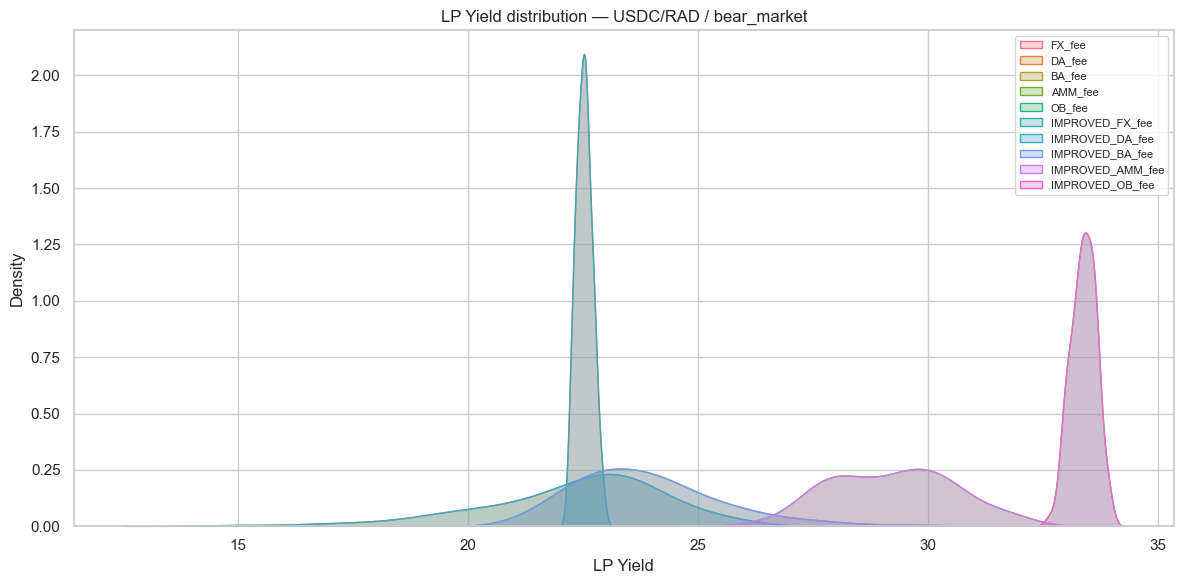

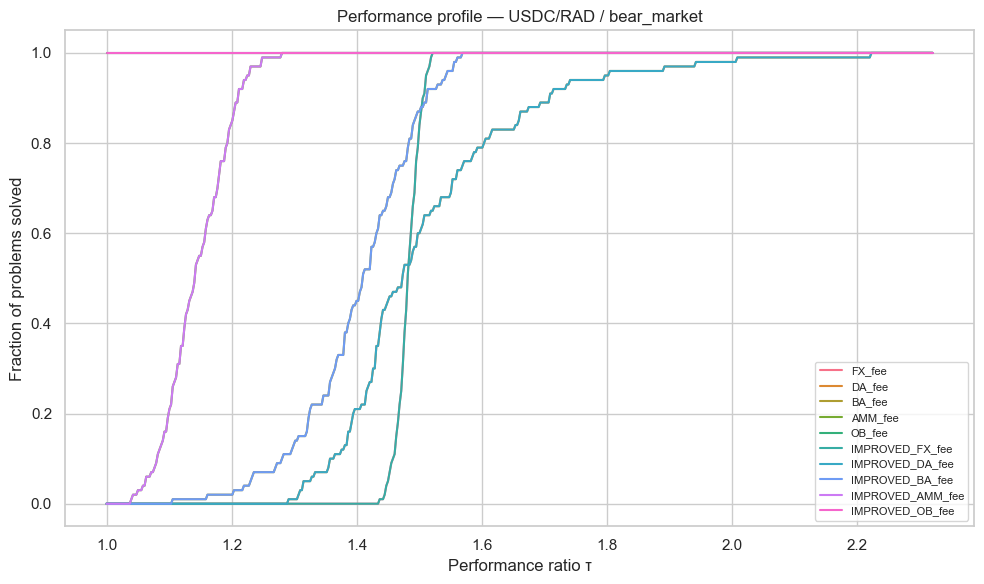

In [27]:
show_stats_for_pair_alias("USDC/RAD", "bear_market")
plot_yield_stats("USDC/RAD", "bear_market")
plot_performance_profile("USDC/RAD", "bear_market")

#### ETH/USDT

##### volatile_market


=== ETH/USDT / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,161.31 ± 31.62,77.69 ± 11.36,2.21 ± 0.22,-8215.66 ± 290.07,722.90 ± 24.58,-56.57 ± 0.76,6323.38 ± 599.28,28.95 ± 1.45,-1547.89 ± 6163.70
BA_fee,182.06 ± 30.55,89.91 ± 12.81,2.17 ± 0.19,-8204.94 ± 304.57,722.99 ± 24.72,-56.49 ± 0.87,6169.64 ± 571.95,26.89 ± 1.56,-1586.54 ± 6072.38
DA_fee,180.63 ± 32.68,91.18 ± 14.35,2.13 ± 0.19,-8221.69 ± 301.04,723.34 ± 24.56,-56.58 ± 0.87,5991.28 ± 501.84,26.05 ± 1.87,-734.40 ± 7392.47
FX_fee,180.90 ± 36.43,91.49 ± 13.93,2.12 ± 0.22,-8205.96 ± 302.09,723.27 ± 24.60,-56.48 ± 0.87,6056.78 ± 351.66,26.29 ± 0.23,-1073.47 ± 6779.25
IMPROVED_AMM_fee,161.31 ± 31.62,77.69 ± 11.36,2.21 ± 0.22,-8215.66 ± 290.07,722.90 ± 24.58,-56.57 ± 0.76,6323.38 ± 599.28,28.95 ± 1.45,-1547.89 ± 6163.70
IMPROVED_BA_fee,182.06 ± 30.55,89.91 ± 12.81,2.17 ± 0.19,-8204.94 ± 304.57,722.99 ± 24.72,-56.49 ± 0.87,6169.64 ± 571.95,26.89 ± 1.56,-1586.54 ± 6072.38
IMPROVED_DA_fee,180.63 ± 32.68,91.18 ± 14.35,2.13 ± 0.19,-8221.69 ± 301.04,723.34 ± 24.56,-56.58 ± 0.87,5991.28 ± 501.84,26.05 ± 1.87,-734.40 ± 7392.47
IMPROVED_FX_fee,180.90 ± 36.43,91.49 ± 13.93,2.12 ± 0.22,-8205.96 ± 302.09,723.27 ± 24.60,-56.48 ± 0.87,6056.78 ± 351.66,26.29 ± 0.23,-1073.47 ± 6779.25
IMPROVED_OB_fee,128.04 ± 30.14,65.10 ± 12.96,2.11 ± 0.22,-8206.68 ± 296.16,722.81 ± 24.75,-56.52 ± 0.67,6421.18 ± 485.19,31.18 ± 0.47,-1357.58 ± 6677.06


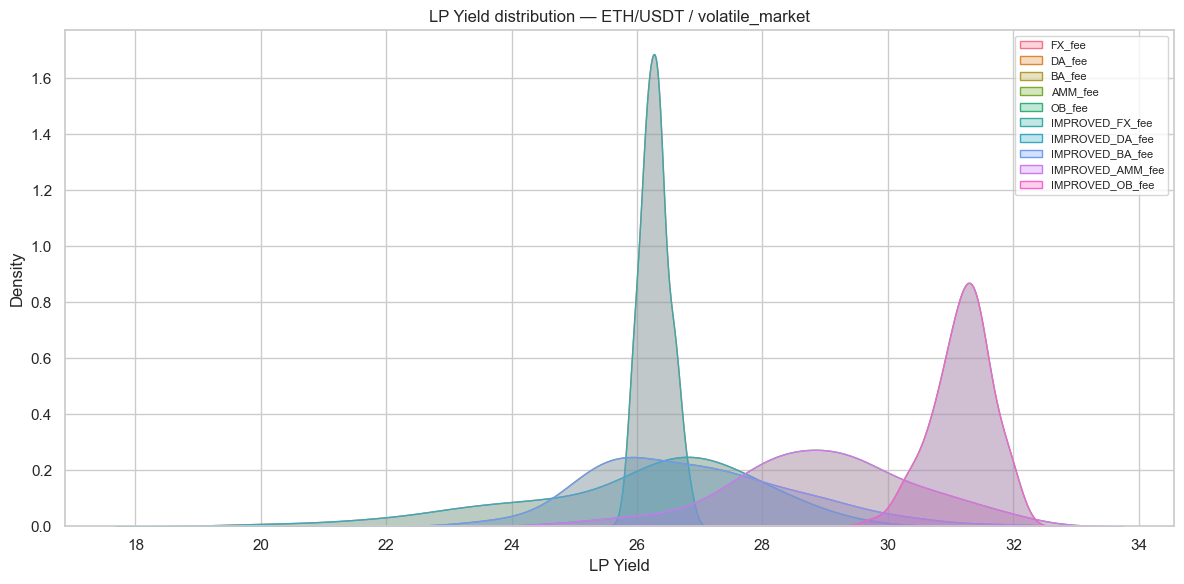

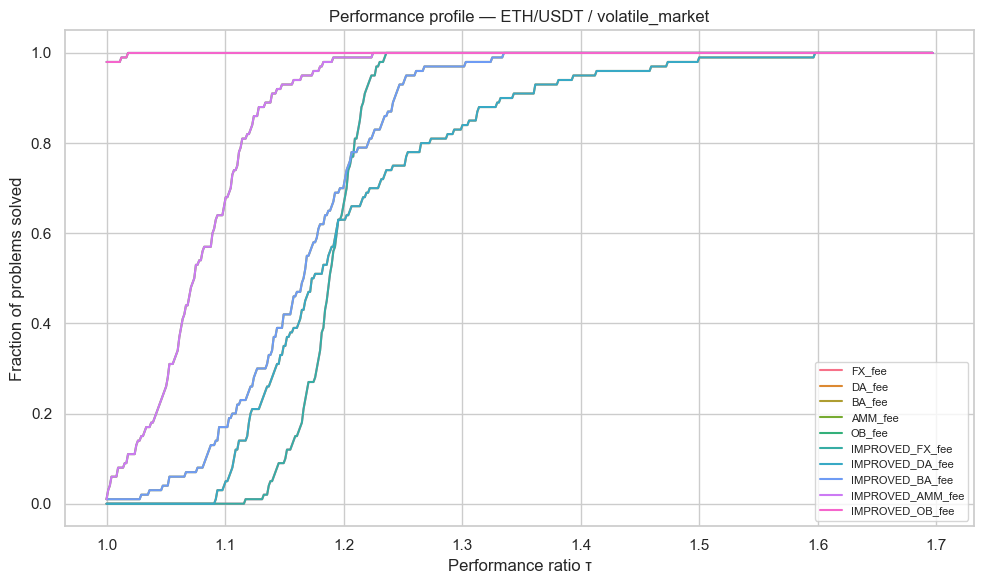

In [28]:
show_stats_for_pair_alias("ETH/USDT", "volatile_market")
plot_yield_stats("ETH/USDT", "volatile_market")
plot_performance_profile("ETH/USDT", "volatile_market")

##### bull_market


=== ETH/USDT / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,179.33 ± 31.26,81.55 ± 11.40,2.33 ± 0.22,-8181.27 ± 304.77,723.27 ± 24.32,-56.74 ± 0.84,6335.01 ± 527.81,28.65 ± 1.24,-3957.58 ± 4216.96
BA_fee,205.59 ± 38.03,96.49 ± 13.39,2.27 ± 0.21,-8177.83 ± 304.53,723.30 ± 24.44,-56.71 ± 0.84,6165.87 ± 489.40,26.28 ± 1.33,-3981.54 ± 4032.22
DA_fee,203.25 ± 36.83,97.97 ± 13.65,2.22 ± 0.19,-8177.75 ± 307.14,723.21 ± 24.72,-56.71 ± 0.86,6129.51 ± 435.80,26.03 ± 1.30,-3514.90 ± 4960.96
FX_fee,203.62 ± 36.11,97.46 ± 13.92,2.23 ± 0.19,-8174.44 ± 300.61,723.14 ± 24.82,-56.70 ± 0.86,6149.17 ± 342.22,26.15 ± 0.22,-3707.55 ± 4533.72
IMPROVED_AMM_fee,179.33 ± 31.26,81.55 ± 11.40,2.33 ± 0.22,-8181.27 ± 304.77,723.27 ± 24.32,-56.74 ± 0.84,6335.01 ± 527.81,28.65 ± 1.24,-3957.58 ± 4216.96
IMPROVED_BA_fee,205.59 ± 38.03,96.49 ± 13.39,2.27 ± 0.21,-8177.83 ± 304.53,723.30 ± 24.44,-56.71 ± 0.84,6165.87 ± 489.40,26.28 ± 1.33,-3981.54 ± 4032.22
IMPROVED_DA_fee,203.25 ± 36.83,97.97 ± 13.65,2.22 ± 0.19,-8177.75 ± 307.14,723.21 ± 24.72,-56.71 ± 0.86,6129.51 ± 435.80,26.03 ± 1.30,-3514.90 ± 4960.96
IMPROVED_FX_fee,203.62 ± 36.11,97.46 ± 13.92,2.23 ± 0.19,-8174.44 ± 300.61,723.14 ± 24.82,-56.70 ± 0.86,6149.17 ± 342.22,26.15 ± 0.22,-3707.55 ± 4533.72
IMPROVED_OB_fee,143.53 ± 33.87,68.60 ± 13.30,2.23 ± 0.22,-8179.45 ± 293.15,722.86 ± 25.24,-56.76 ± 0.69,6520.93 ± 478.73,31.30 ± 0.48,-3943.76 ± 4482.23


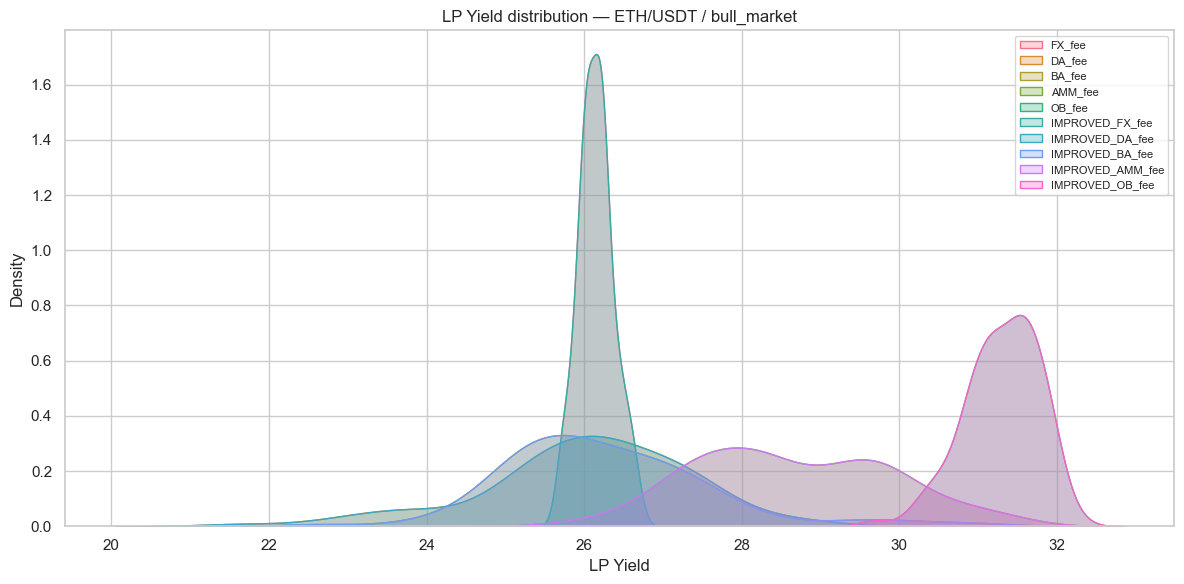

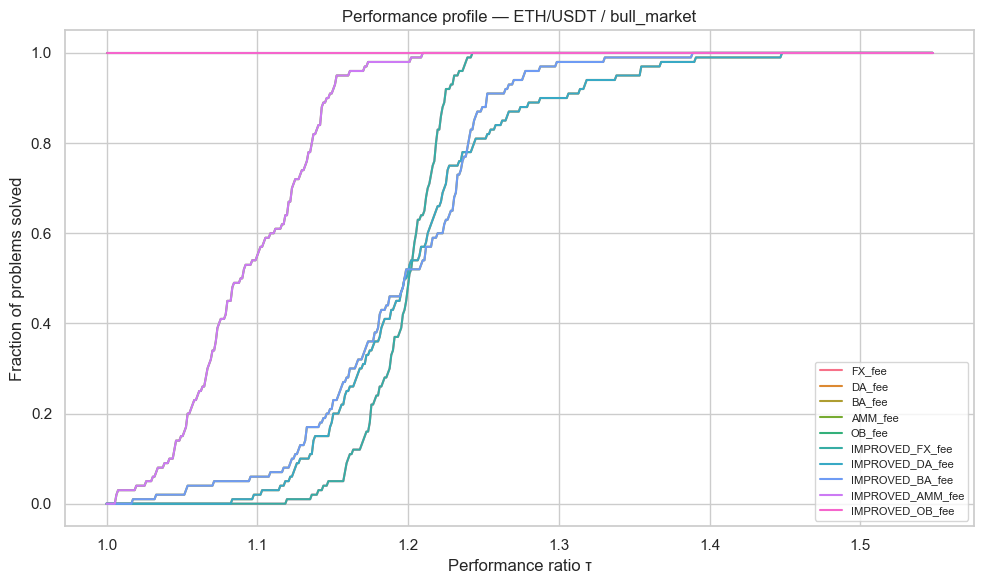

In [29]:
show_stats_for_pair_alias("ETH/USDT", "bull_market")
plot_yield_stats("ETH/USDT", "bull_market")
plot_performance_profile("ETH/USDT", "bull_market")

##### calm_market


=== ETH/USDT / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,197.05 ± 33.79,85.49 ± 11.54,2.43 ± 0.24,-8175.77 ± 314.83,723.17 ± 24.61,-56.79 ± 0.86,6475.51 ± 539.37,28.77 ± 1.28,-3766.58 ± 4833.31
BA_fee,221.59 ± 35.84,101.53 ± 13.28,2.32 ± 0.17,-8171.18 ± 303.29,723.41 ± 25.30,-56.74 ± 0.82,6294.80 ± 489.61,26.30 ± 1.34,-3826.97 ± 4606.96
DA_fee,220.64 ± 38.07,104.10 ± 14.08,2.26 ± 0.21,-8170.97 ± 304.11,723.23 ± 24.70,-56.75 ± 0.88,6240.43 ± 462.36,25.86 ± 1.29,-3329.15 ± 5544.89
FX_fee,226.68 ± 38.92,102.94 ± 13.76,2.34 ± 0.20,-8159.89 ± 288.64,722.80 ± 24.19,-56.71 ± 0.81,6263.33 ± 339.94,26.03 ± 0.22,-3527.36 ± 5150.45
IMPROVED_AMM_fee,197.05 ± 33.79,85.49 ± 11.54,2.43 ± 0.24,-8175.77 ± 314.83,723.17 ± 24.61,-56.79 ± 0.86,6475.51 ± 539.37,28.77 ± 1.28,-3766.58 ± 4833.31
IMPROVED_BA_fee,221.59 ± 35.84,101.53 ± 13.28,2.32 ± 0.17,-8171.18 ± 303.29,723.41 ± 25.30,-56.74 ± 0.82,6294.80 ± 489.61,26.30 ± 1.34,-3826.97 ± 4606.96
IMPROVED_DA_fee,220.64 ± 38.07,104.10 ± 14.08,2.26 ± 0.21,-8170.97 ± 304.11,723.23 ± 24.70,-56.75 ± 0.88,6240.43 ± 462.36,25.86 ± 1.29,-3329.15 ± 5544.89
IMPROVED_FX_fee,226.68 ± 38.92,102.94 ± 13.76,2.34 ± 0.20,-8159.89 ± 288.64,722.80 ± 24.19,-56.71 ± 0.81,6263.33 ± 339.94,26.03 ± 0.22,-3527.36 ± 5150.45
IMPROVED_OB_fee,159.45 ± 34.67,72.15 ± 13.99,2.34 ± 0.22,-8166.96 ± 293.26,722.95 ± 24.57,-56.75 ± 0.75,6651.14 ± 489.06,31.38 ± 0.45,-3779.93 ± 5053.24


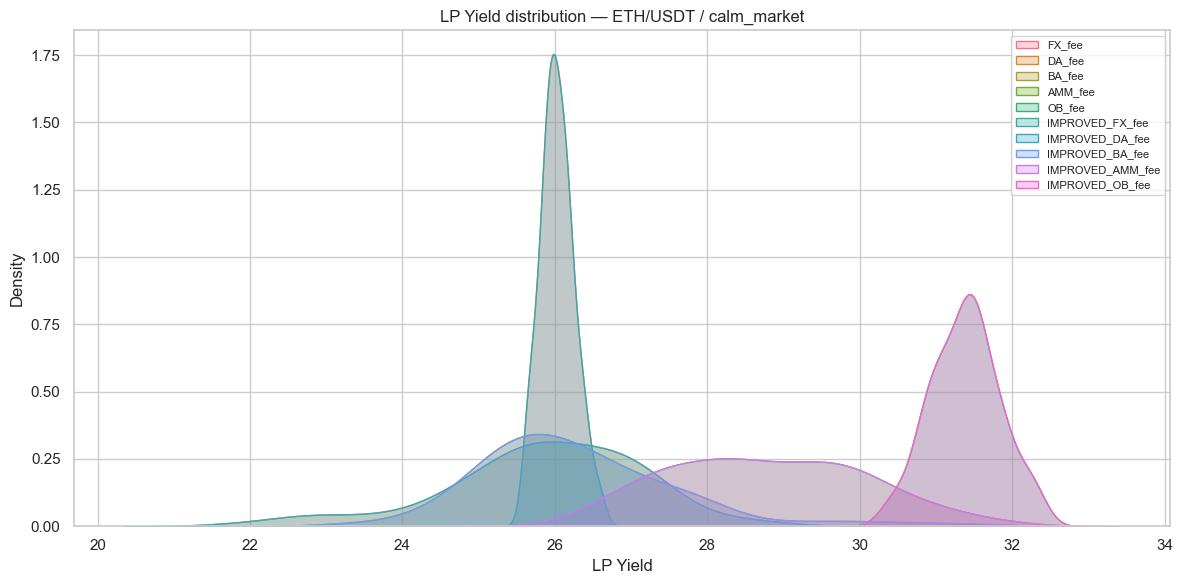

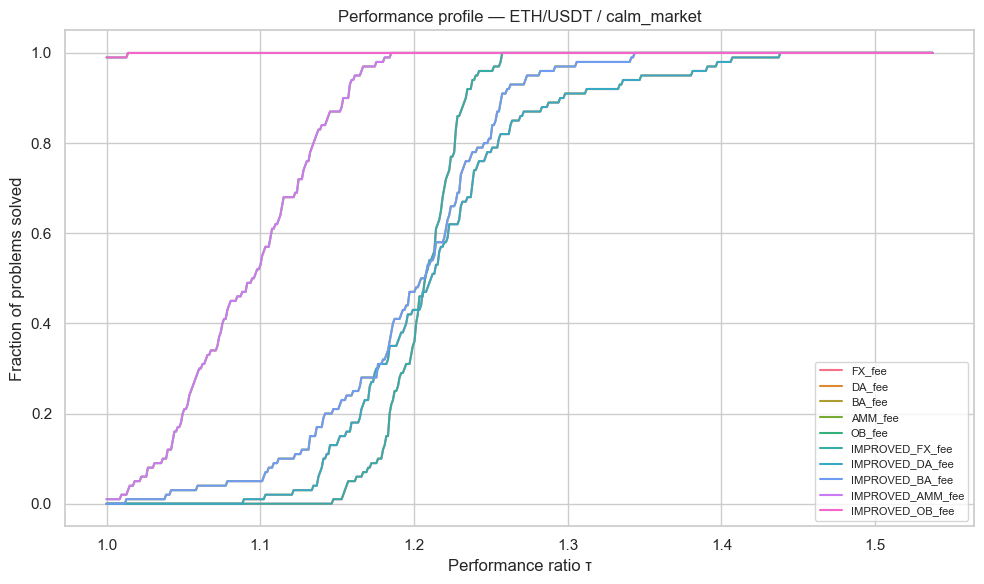

In [30]:
show_stats_for_pair_alias("ETH/USDT", "calm_market")
plot_yield_stats("ETH/USDT", "calm_market")
plot_performance_profile("ETH/USDT", "calm_market")

##### bear_market


=== ETH/USDT / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,155.99 ± 29.04,76.56 ± 11.76,2.19 ± 0.19,-8134.03 ± 292.87,722.88 ± 24.49,-56.97 ± 0.84,6238.89 ± 550.88,29.16 ± 1.54,-164.32 ± 7636.54
BA_fee,173.87 ± 29.09,87.71 ± 11.84,2.14 ± 0.19,-8132.00 ± 301.47,723.04 ± 24.95,-56.94 ± 0.84,6115.80 ± 508.08,27.33 ± 1.80,-300.45 ± 7589.99
DA_fee,171.98 ± 29.12,89.30 ± 12.75,2.09 ± 0.18,-8124.10 ± 300.77,723.07 ± 24.28,-56.88 ± 0.84,5723.04 ± 433.87,25.44 ± 1.35,886.31 ± 8737.61
FX_fee,172.75 ± 29.85,88.44 ± 12.10,2.12 ± 0.17,-8121.86 ± 287.45,723.05 ± 24.14,-56.87 ± 0.79,5901.25 ± 286.29,26.31 ± 0.21,384.06 ± 8295.46
IMPROVED_AMM_fee,155.99 ± 29.04,76.56 ± 11.76,2.19 ± 0.19,-8134.03 ± 292.87,722.88 ± 24.49,-56.97 ± 0.84,6238.89 ± 550.88,29.16 ± 1.54,-164.32 ± 7636.54
IMPROVED_BA_fee,173.87 ± 29.09,87.71 ± 11.84,2.14 ± 0.19,-8132.00 ± 301.47,723.04 ± 24.95,-56.94 ± 0.84,6115.80 ± 508.08,27.33 ± 1.80,-300.45 ± 7589.99
IMPROVED_DA_fee,171.98 ± 29.12,89.30 ± 12.75,2.09 ± 0.18,-8124.10 ± 300.77,723.07 ± 24.28,-56.88 ± 0.84,5723.04 ± 433.87,25.44 ± 1.35,886.31 ± 8737.61
IMPROVED_FX_fee,172.75 ± 29.85,88.44 ± 12.10,2.12 ± 0.17,-8121.86 ± 287.45,723.05 ± 24.14,-56.87 ± 0.79,5901.25 ± 286.29,26.31 ± 0.21,384.06 ± 8295.46
IMPROVED_OB_fee,122.43 ± 29.63,63.89 ± 13.35,2.08 ± 0.22,-8125.74 ± 283.43,722.92 ± 24.52,-56.91 ± 0.82,6284.47 ± 434.47,31.17 ± 0.46,94.62 ± 8058.22


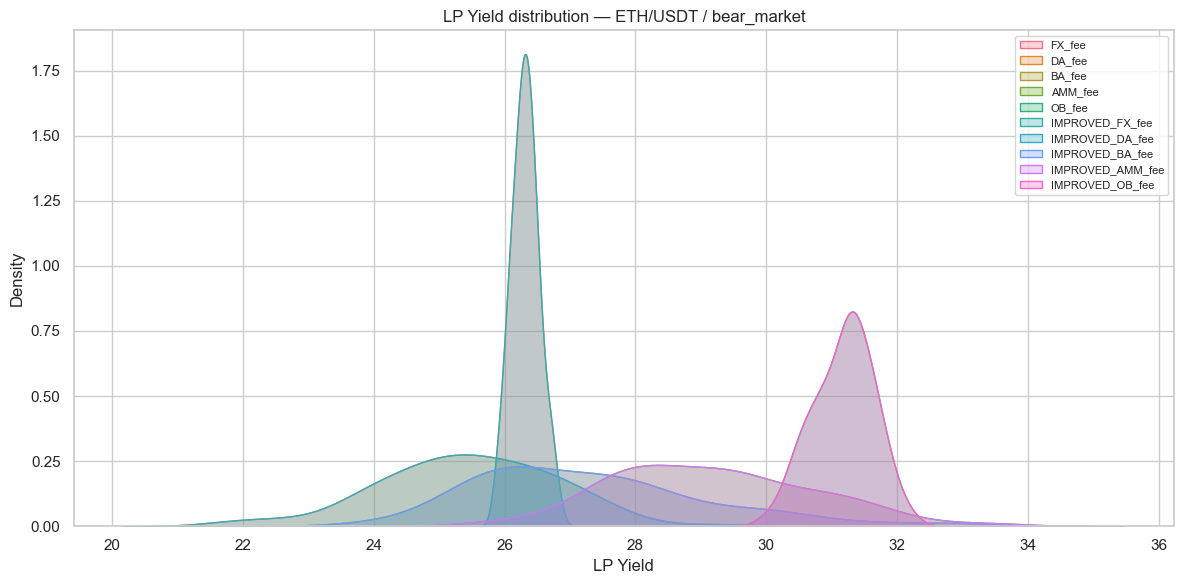

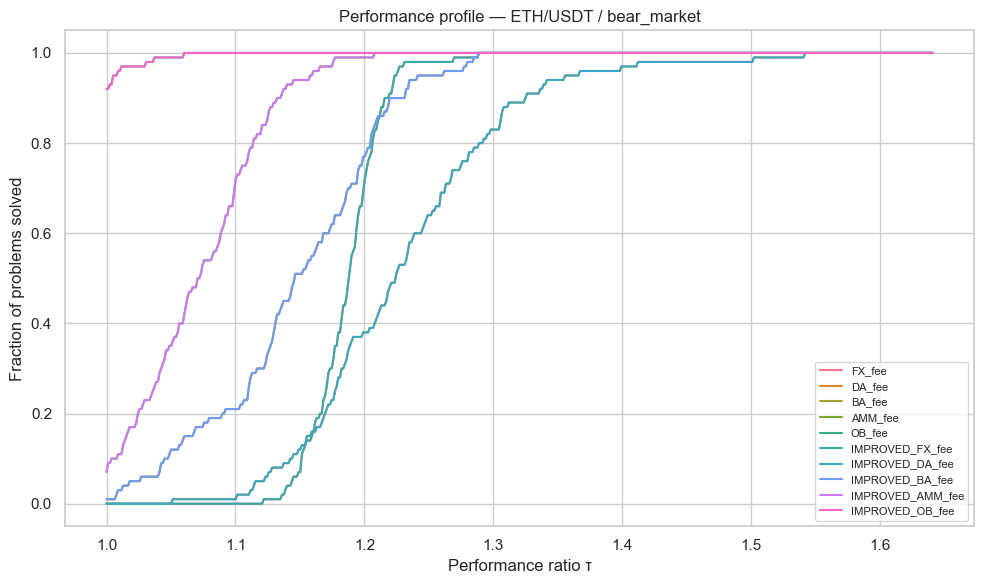

In [31]:
show_stats_for_pair_alias("ETH/USDT", "bear_market")
plot_yield_stats("ETH/USDT", "bear_market")
plot_performance_profile("ETH/USDT", "bear_market")

#### BTC/USDT

##### volatile_market


=== BTC/USDT / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,111.22 ± 24.31,61.19 ± 9.97,1.97 ± 0.23,-8207.49 ± 306.51,723.27 ± 24.89,-56.59 ± 0.82,5768.16 ± 509.99,28.61 ± 1.32,-2857.73 ± 4014.68
BA_fee,121.03 ± 24.17,70.11 ± 11.22,1.88 ± 0.19,-8196.47 ± 295.08,723.67 ± 24.86,-56.49 ± 0.85,5644.07 ± 475.12,26.96 ± 1.35,-2848.79 ± 3992.04
DA_fee,120.75 ± 25.58,70.29 ± 11.69,1.87 ± 0.19,-8198.42 ± 300.81,723.15 ± 24.54,-56.54 ± 0.82,5569.26 ± 406.18,26.64 ± 1.61,-2277.68 ± 5030.92
FX_fee,120.75 ± 25.53,70.27 ± 12.03,1.87 ± 0.17,-8195.47 ± 302.17,723.19 ± 24.85,-56.52 ± 0.79,5586.15 ± 304.87,26.70 ± 0.22,-2514.64 ± 4498.97
IMPROVED_AMM_fee,111.22 ± 24.31,61.19 ± 9.97,1.97 ± 0.23,-8207.49 ± 306.51,723.27 ± 24.89,-56.59 ± 0.82,5768.16 ± 509.99,28.61 ± 1.32,-2857.73 ± 4014.68
IMPROVED_BA_fee,121.03 ± 24.17,70.11 ± 11.22,1.88 ± 0.19,-8196.47 ± 295.08,723.67 ± 24.86,-56.49 ± 0.85,5644.07 ± 475.12,26.96 ± 1.35,-2848.79 ± 3992.04
IMPROVED_DA_fee,120.75 ± 25.58,70.29 ± 11.69,1.87 ± 0.19,-8198.42 ± 300.81,723.15 ± 24.54,-56.54 ± 0.82,5569.26 ± 406.18,26.64 ± 1.61,-2277.68 ± 5030.92
IMPROVED_FX_fee,120.75 ± 25.53,70.27 ± 12.03,1.87 ± 0.17,-8195.47 ± 302.17,723.19 ± 24.85,-56.52 ± 0.79,5586.15 ± 304.87,26.70 ± 0.22,-2514.64 ± 4498.97
IMPROVED_OB_fee,87.22 ± 23.24,50.13 ± 10.72,1.89 ± 0.22,-8210.16 ± 296.41,723.37 ± 25.16,-56.60 ± 0.68,5872.34 ± 408.38,30.73 ± 0.48,-2752.79 ± 4443.34


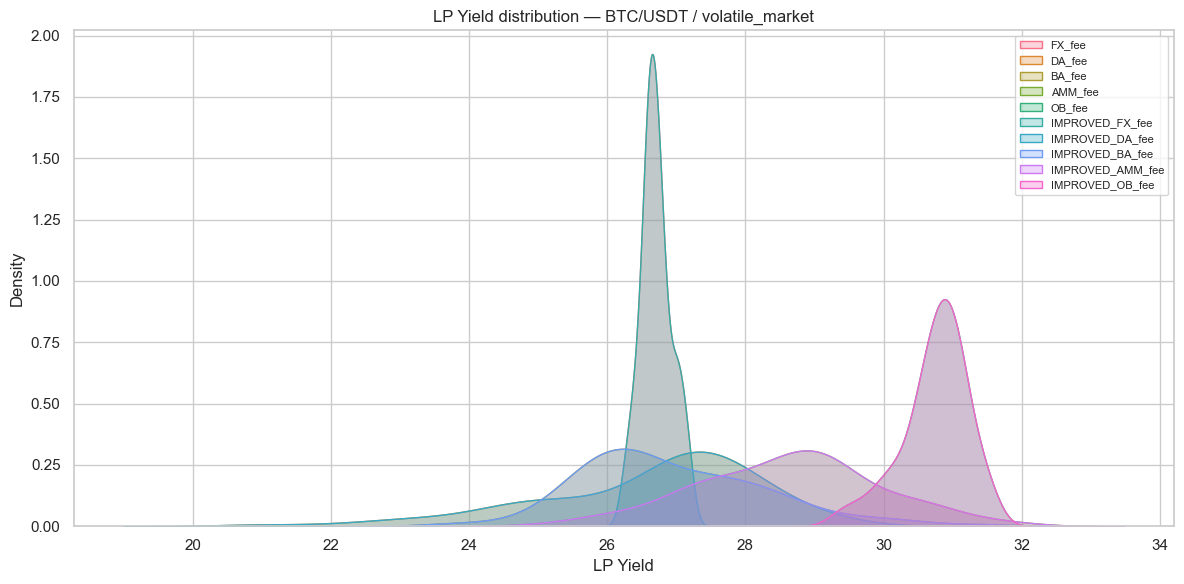

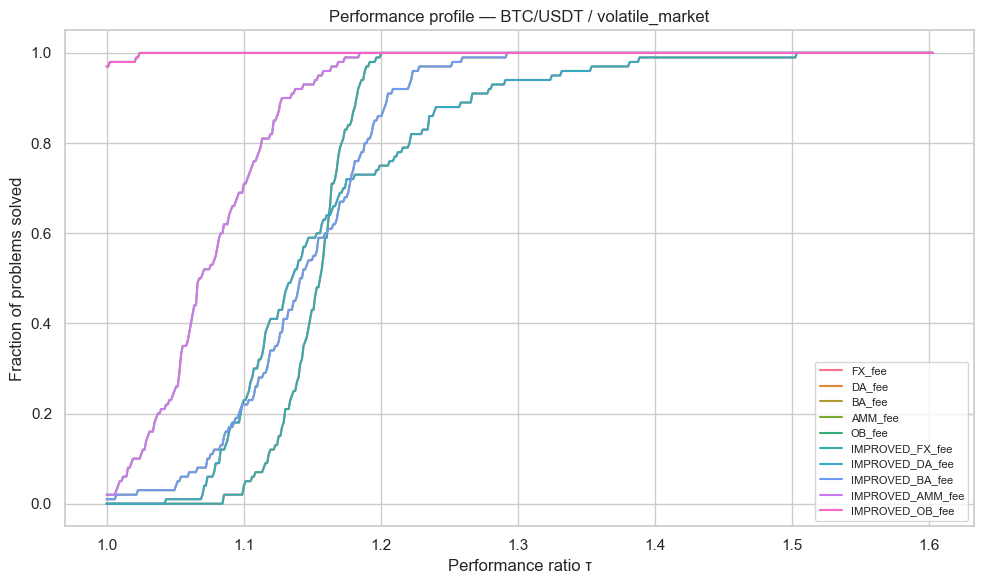

In [32]:
show_stats_for_pair_alias("BTC/USDT", "volatile_market")
plot_yield_stats("BTC/USDT", "volatile_market")
plot_performance_profile("BTC/USDT", "volatile_market")

##### bull_market


=== BTC/USDT / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,113.92 ± 23.71,61.41 ± 9.55,2.01 ± 0.22,-8168.46 ± 299.62,723.39 ± 24.66,-56.76 ± 0.82,5687.85 ± 438.05,28.37 ± 1.23,-3910.07 ± 3271.30
BA_fee,125.81 ± 25.22,70.67 ± 11.34,1.94 ± 0.19,-8152.18 ± 294.05,723.10 ± 24.57,-56.68 ± 0.80,5566.53 ± 411.47,26.70 ± 1.22,-3916.68 ± 3223.79
DA_fee,122.82 ± 26.42,71.35 ± 11.36,1.88 ± 0.20,-8165.30 ± 296.61,722.88 ± 24.50,-56.78 ± 0.80,5535.60 ± 361.21,26.53 ± 1.18,-3526.92 ± 3972.04
FX_fee,123.14 ± 25.33,71.04 ± 12.00,1.90 ± 0.18,-8147.78 ± 290.96,722.89 ± 24.24,-56.67 ± 0.78,5561.31 ± 292.83,26.68 ± 0.22,-3704.52 ± 3621.51
IMPROVED_AMM_fee,113.92 ± 23.71,61.41 ± 9.55,2.01 ± 0.22,-8168.46 ± 299.62,723.39 ± 24.66,-56.76 ± 0.82,5687.85 ± 438.05,28.37 ± 1.23,-3910.07 ± 3271.30
IMPROVED_BA_fee,125.81 ± 25.22,70.67 ± 11.34,1.94 ± 0.19,-8152.18 ± 294.05,723.10 ± 24.57,-56.68 ± 0.80,5566.53 ± 411.47,26.70 ± 1.22,-3916.68 ± 3223.79
IMPROVED_DA_fee,122.82 ± 26.42,71.35 ± 11.36,1.88 ± 0.20,-8165.30 ± 296.61,722.88 ± 24.50,-56.78 ± 0.80,5535.60 ± 361.21,26.53 ± 1.18,-3526.92 ± 3972.04
IMPROVED_FX_fee,123.14 ± 25.33,71.04 ± 12.00,1.90 ± 0.18,-8147.78 ± 290.96,722.89 ± 24.24,-56.67 ± 0.78,5561.31 ± 292.83,26.68 ± 0.22,-3704.52 ± 3621.51
IMPROVED_OB_fee,86.46 ± 22.13,49.66 ± 11.64,1.91 ± 0.23,-8156.92 ± 295.92,722.76 ± 25.02,-56.74 ± 0.71,5815.49 ± 391.08,30.75 ± 0.45,-3860.29 ± 3548.43


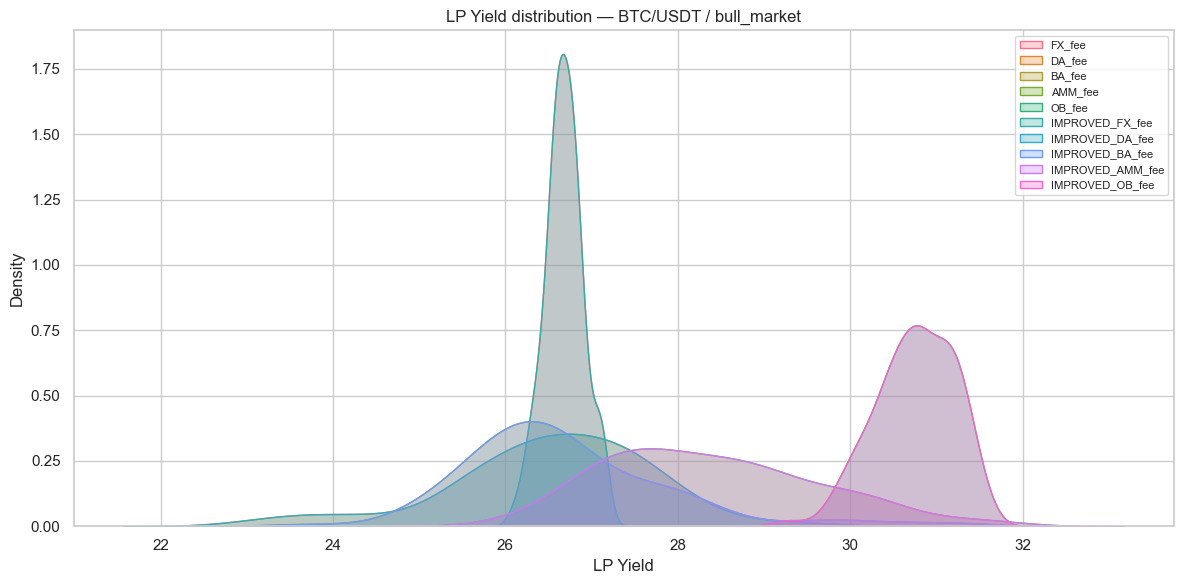

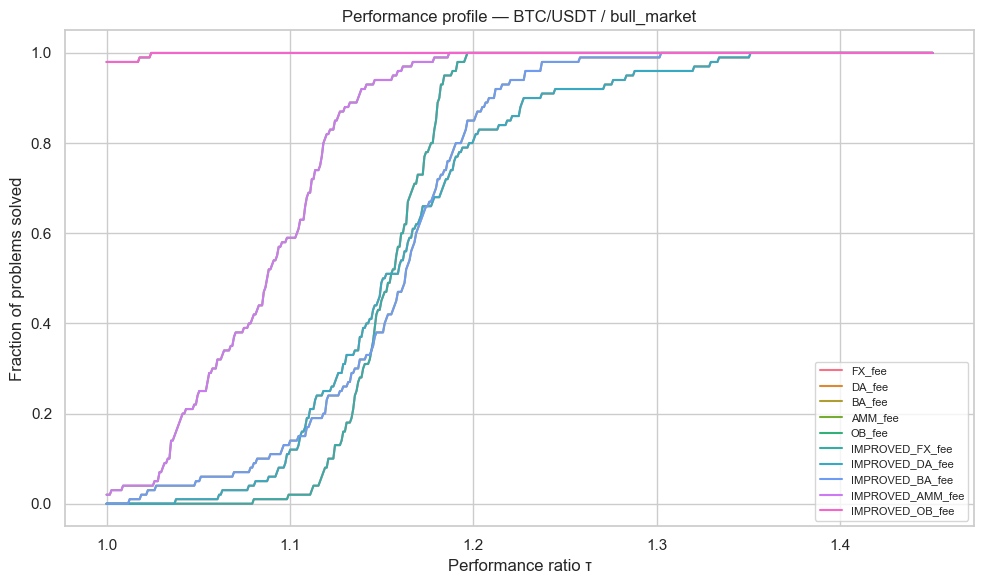

In [33]:
show_stats_for_pair_alias("BTC/USDT", "bull_market")
plot_yield_stats("BTC/USDT", "bull_market")
plot_performance_profile("BTC/USDT", "bull_market")

##### calm_market


=== BTC/USDT / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,141.61 ± 28.29,70.93 ± 10.82,2.14 ± 0.21,-8188.97 ± 311.26,722.93 ± 24.98,-56.62 ± 0.82,6032.37 ± 520.97,28.61 ± 1.28,-3558.00 ± 3936.83
BA_fee,160.13 ± 27.26,82.83 ± 12.63,2.09 ± 0.18,-8192.88 ± 291.02,723.38 ± 24.49,-56.61 ± 0.85,5890.25 ± 475.27,26.59 ± 1.33,-3568.95 ± 3821.20
DA_fee,158.92 ± 29.67,84.18 ± 12.96,2.04 ± 0.18,-8194.36 ± 308.50,722.91 ± 24.54,-56.66 ± 0.82,5872.84 ± 415.83,26.43 ± 1.46,-3146.12 ± 4769.69
FX_fee,159.43 ± 28.70,83.48 ± 12.59,2.06 ± 0.18,-8181.18 ± 308.07,722.73 ± 25.26,-56.58 ± 0.84,5859.89 ± 318.21,26.42 ± 0.21,-3295.28 ± 4298.83
IMPROVED_AMM_fee,141.61 ± 28.29,70.93 ± 10.82,2.14 ± 0.21,-8188.97 ± 311.26,722.93 ± 24.98,-56.62 ± 0.82,6032.37 ± 520.97,28.61 ± 1.28,-3558.00 ± 3936.83
IMPROVED_BA_fee,160.13 ± 27.26,82.83 ± 12.63,2.09 ± 0.18,-8192.88 ± 291.02,723.38 ± 24.49,-56.61 ± 0.85,5890.25 ± 475.27,26.59 ± 1.33,-3568.95 ± 3821.20
IMPROVED_DA_fee,158.92 ± 29.67,84.18 ± 12.96,2.04 ± 0.18,-8194.36 ± 308.50,722.91 ± 24.54,-56.66 ± 0.82,5872.84 ± 415.83,26.43 ± 1.46,-3146.12 ± 4769.69
IMPROVED_FX_fee,159.43 ± 28.70,83.48 ± 12.59,2.06 ± 0.18,-8181.18 ± 308.07,722.73 ± 25.26,-56.58 ± 0.84,5859.89 ± 318.21,26.42 ± 0.21,-3295.28 ± 4298.83
IMPROVED_OB_fee,112.47 ± 28.89,58.80 ± 12.36,2.06 ± 0.22,-8189.73 ± 295.83,722.93 ± 24.82,-56.63 ± 0.71,6177.77 ± 443.03,31.02 ± 0.45,-3517.59 ± 4244.80


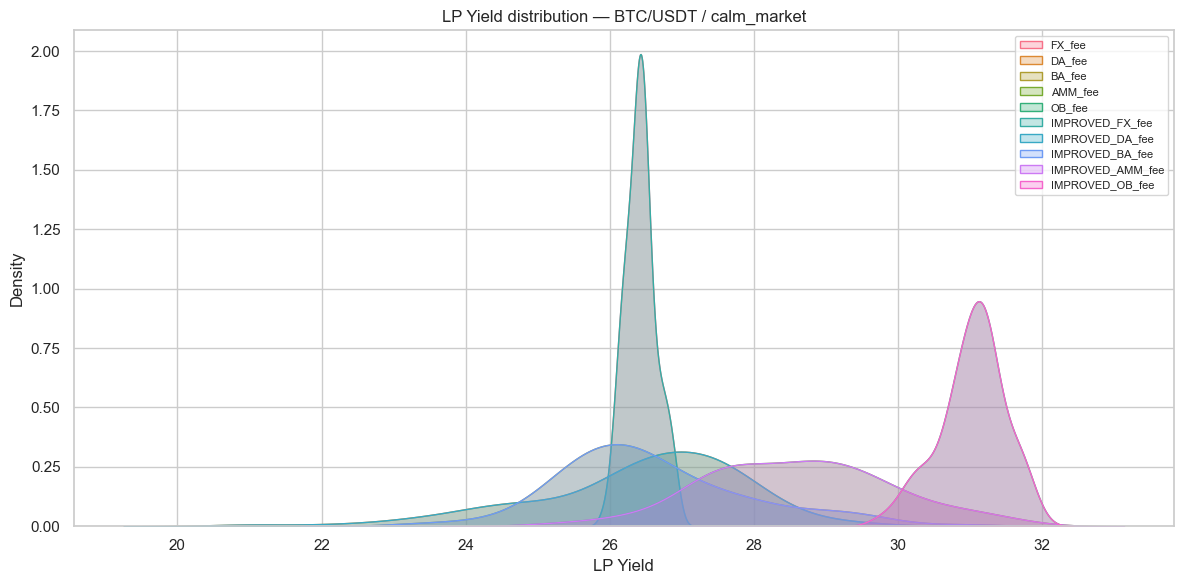

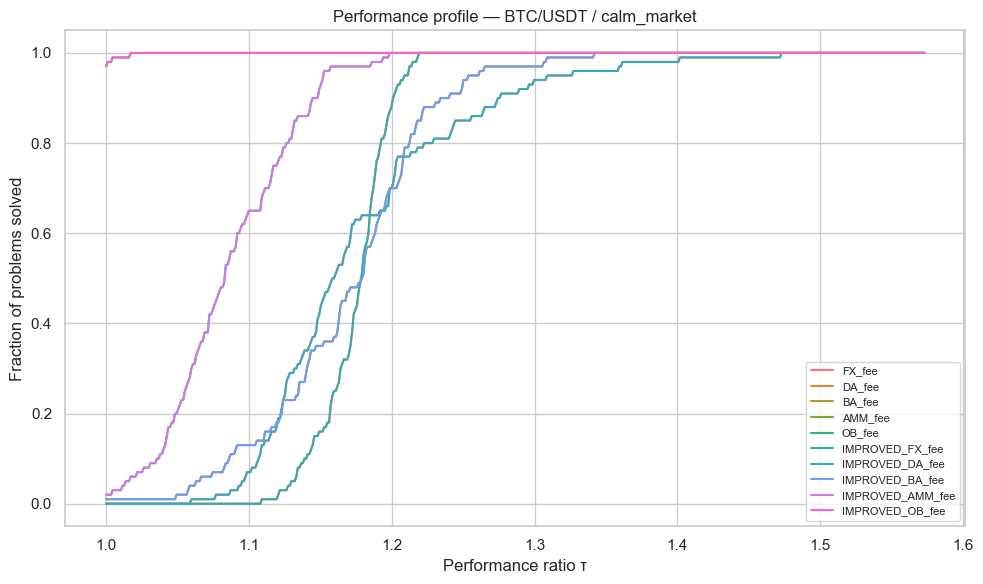

In [34]:
show_stats_for_pair_alias("BTC/USDT", "calm_market")
plot_yield_stats("BTC/USDT", "calm_market")
plot_performance_profile("BTC/USDT", "calm_market")

##### bear_market


=== BTC/USDT / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,90.73 ± 18.91,53.44 ± 8.51,1.86 ± 0.21,-8148.87 ± 311.38,723.09 ± 24.46,-56.82 ± 0.86,5471.00 ± 418.96,28.49 ± 1.35,-3026.42 ± 3776.00
BA_fee,96.77 ± 19.76,60.27 ± 10.06,1.78 ± 0.19,-8141.05 ± 298.54,722.92 ± 24.83,-56.78 ± 0.88,5367.22 ± 383.62,27.14 ± 1.37,-3036.98 ± 3750.20
DA_fee,93.89 ± 21.28,60.14 ± 10.85,1.73 ± 0.20,-8147.72 ± 294.99,723.03 ± 24.35,-56.82 ± 0.84,5233.18 ± 335.43,26.51 ± 1.17,-2427.47 ± 4523.35
FX_fee,95.46 ± 22.93,59.70 ± 10.72,1.76 ± 0.19,-8148.70 ± 288.88,723.15 ± 24.44,-56.82 ± 0.81,5308.18 ± 258.01,26.92 ± 0.23,-2723.89 ± 4227.10
IMPROVED_AMM_fee,90.73 ± 18.91,53.44 ± 8.51,1.86 ± 0.21,-8148.87 ± 311.38,723.09 ± 24.46,-56.82 ± 0.86,5471.00 ± 418.96,28.49 ± 1.35,-3026.42 ± 3776.00
IMPROVED_BA_fee,96.77 ± 19.76,60.27 ± 10.06,1.78 ± 0.19,-8141.05 ± 298.54,722.92 ± 24.83,-56.78 ± 0.88,5367.22 ± 383.62,27.14 ± 1.37,-3036.98 ± 3750.20
IMPROVED_DA_fee,93.89 ± 21.28,60.14 ± 10.85,1.73 ± 0.20,-8147.72 ± 294.99,723.03 ± 24.35,-56.82 ± 0.84,5233.18 ± 335.43,26.51 ± 1.17,-2427.47 ± 4523.35
IMPROVED_FX_fee,95.46 ± 22.93,59.70 ± 10.72,1.76 ± 0.19,-8148.70 ± 288.88,723.15 ± 24.44,-56.82 ± 0.81,5308.18 ± 258.01,26.92 ± 0.23,-2723.89 ± 4227.10
IMPROVED_OB_fee,67.17 ± 20.44,42.88 ± 11.41,1.73 ± 0.19,-8155.74 ± 290.48,722.88 ± 24.38,-56.89 ± 0.71,5555.19 ± 369.24,30.52 ± 0.47,-2907.47 ± 4045.31


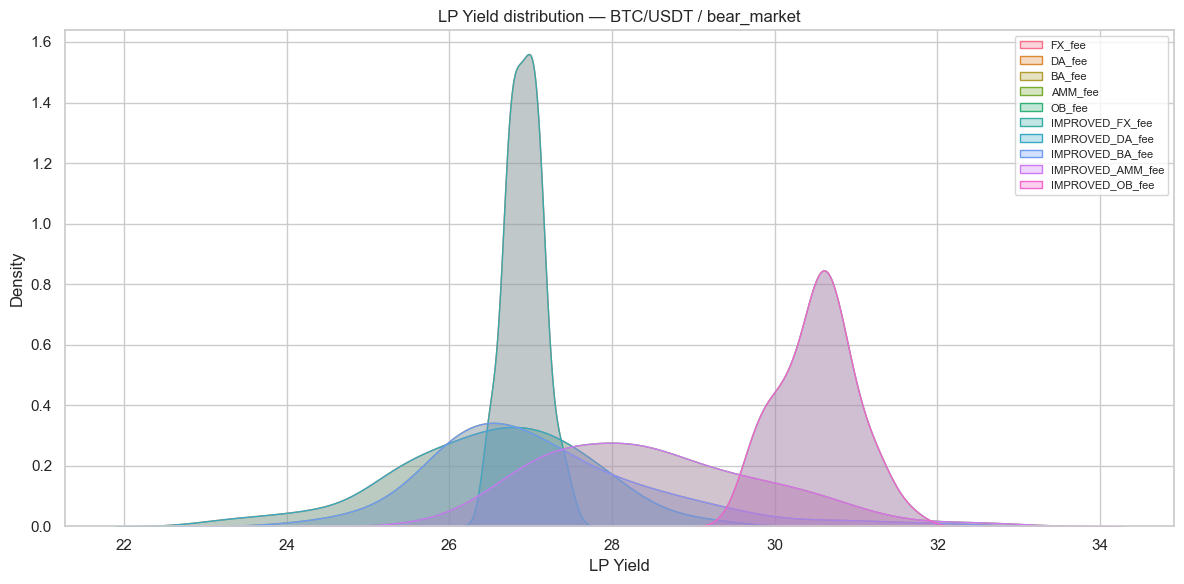

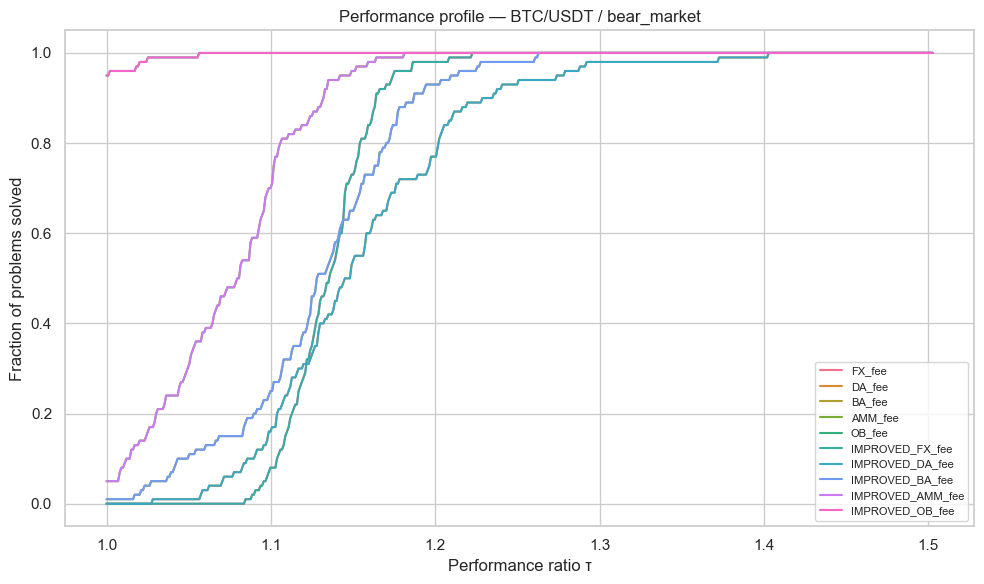

In [35]:
show_stats_for_pair_alias("BTC/USDT", "bear_market")
plot_yield_stats("BTC/USDT", "bear_market")
plot_performance_profile("BTC/USDT", "bear_market")

### Non-stable / Non-stable

#### ETH/BTC

##### volatile_market


=== ETH/BTC / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,67.01 ± 14.21,44.27 ± 7.46,1.67 ± 0.22,-8230.98 ± 296.32,722.93 ± 24.63,-56.50 ± 0.92,5238.41 ± 357.63,28.19 ± 1.18,-4494.57 ± 1725.38
BA_fee,73.55 ± 16.38,51.63 ± 8.82,1.58 ± 0.18,-8238.16 ± 289.45,723.61 ± 24.44,-56.49 ± 0.96,5195.35 ± 291.25,27.04 ± 0.99,-4538.56 ± 1672.03
DA_fee,69.84 ± 15.33,49.96 ± 9.03,1.56 ± 0.19,-8238.64 ± 301.69,723.69 ± 24.91,-56.49 ± 0.96,5177.94 ± 283.03,27.17 ± 0.99,-4252.26 ± 2211.27
FX_fee,71.21 ± 16.22,50.28 ± 8.98,1.58 ± 0.21,-8228.62 ± 297.29,723.20 ± 24.93,-56.46 ± 1.00,5183.92 ± 231.67,27.16 ± 0.19,-4370.99 ± 1941.05
IMPROVED_AMM_fee,67.01 ± 14.21,44.27 ± 7.46,1.67 ± 0.22,-8230.98 ± 296.32,722.93 ± 24.63,-56.50 ± 0.92,5238.41 ± 357.63,28.19 ± 1.18,-4494.57 ± 1725.38
IMPROVED_BA_fee,73.55 ± 16.38,51.63 ± 8.82,1.58 ± 0.18,-8238.16 ± 289.45,723.61 ± 24.44,-56.49 ± 0.96,5195.35 ± 291.25,27.04 ± 0.99,-4538.56 ± 1672.03
IMPROVED_DA_fee,69.84 ± 15.33,49.96 ± 9.03,1.56 ± 0.19,-8238.64 ± 301.69,723.69 ± 24.91,-56.49 ± 0.96,5177.94 ± 283.03,27.17 ± 0.99,-4252.26 ± 2211.27
IMPROVED_FX_fee,71.21 ± 16.22,50.28 ± 8.98,1.58 ± 0.21,-8228.62 ± 297.29,723.20 ± 24.93,-56.46 ± 1.00,5183.92 ± 231.67,27.16 ± 0.19,-4370.99 ± 1941.05
IMPROVED_OB_fee,49.79 ± 12.63,35.70 ± 9.12,1.57 ± 0.22,-8248.83 ± 296.05,723.15 ± 24.89,-56.60 ± 0.90,5374.25 ± 308.99,30.23 ± 0.47,-4522.41 ± 1804.17


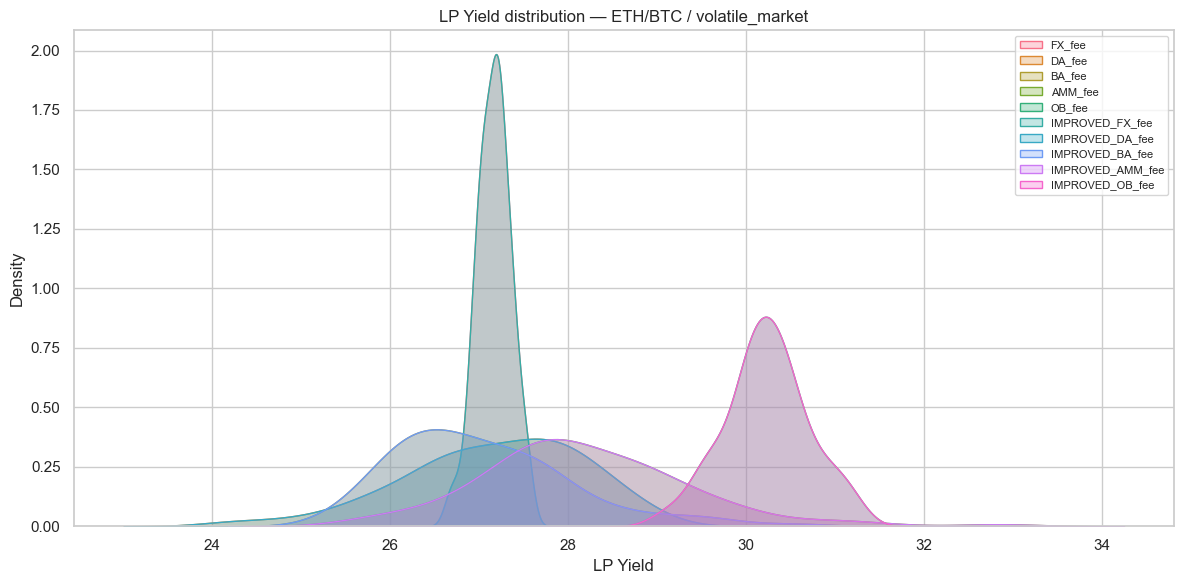

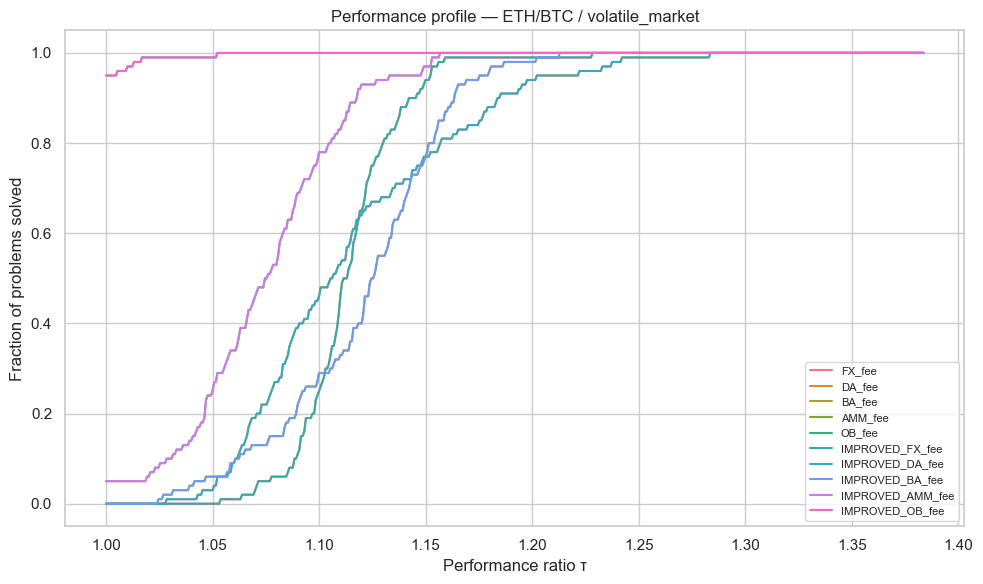

In [36]:
show_stats_for_pair_alias("ETH/BTC", "volatile_market")
plot_yield_stats("ETH/BTC", "volatile_market")
plot_performance_profile("ETH/BTC", "volatile_market")

##### bull_market


=== ETH/BTC / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,46.98 ± 11.21,35.18 ± 6.46,1.51 ± 0.23,-8165.94 ± 301.36,723.02 ± 24.83,-56.91 ± 0.95,4872.09 ± 306.83,27.89 ± 1.07,-4368.76 ± 1220.32
BA_fee,47.67 ± 12.91,39.34 ± 7.97,1.37 ± 0.21,-8161.45 ± 293.07,723.54 ± 25.13,-56.85 ± 0.99,4838.56 ± 266.73,27.17 ± 0.89,-4369.95 ± 1243.98
DA_fee,42.68 ± 11.32,37.06 ± 7.93,1.32 ± 0.19,-8163.28 ± 299.54,723.06 ± 24.54,-56.90 ± 1.04,4837.82 ± 253.14,27.52 ± 0.91,-4151.89 ± 1649.74
FX_fee,44.62 ± 13.17,37.58 ± 7.71,1.34 ± 0.20,-8162.82 ± 301.41,723.11 ± 25.05,-56.89 ± 1.02,4843.16 ± 211.24,27.46 ± 0.19,-4258.55 ± 1447.78
IMPROVED_AMM_fee,46.98 ± 11.21,35.18 ± 6.46,1.51 ± 0.23,-8165.94 ± 301.36,723.02 ± 24.83,-56.91 ± 0.95,4872.09 ± 306.83,27.89 ± 1.07,-4368.76 ± 1220.32
IMPROVED_BA_fee,47.67 ± 12.91,39.34 ± 7.97,1.37 ± 0.21,-8161.45 ± 293.07,723.54 ± 25.13,-56.85 ± 0.99,4838.56 ± 266.73,27.17 ± 0.89,-4369.95 ± 1243.98
IMPROVED_DA_fee,42.68 ± 11.32,37.06 ± 7.93,1.32 ± 0.19,-8163.28 ± 299.54,723.06 ± 24.54,-56.90 ± 1.04,4837.82 ± 253.14,27.52 ± 0.91,-4151.89 ± 1649.74
IMPROVED_FX_fee,44.62 ± 13.17,37.58 ± 7.71,1.34 ± 0.20,-8162.82 ± 301.41,723.11 ± 25.05,-56.89 ± 1.02,4843.16 ± 211.24,27.46 ± 0.19,-4258.55 ± 1447.78
IMPROVED_OB_fee,32.67 ± 11.81,26.65 ± 7.85,1.38 ± 0.25,-8169.79 ± 305.21,723.26 ± 24.29,-56.92 ± 0.89,4975.71 ± 283.55,29.80 ± 0.47,-4372.77 ± 1317.47


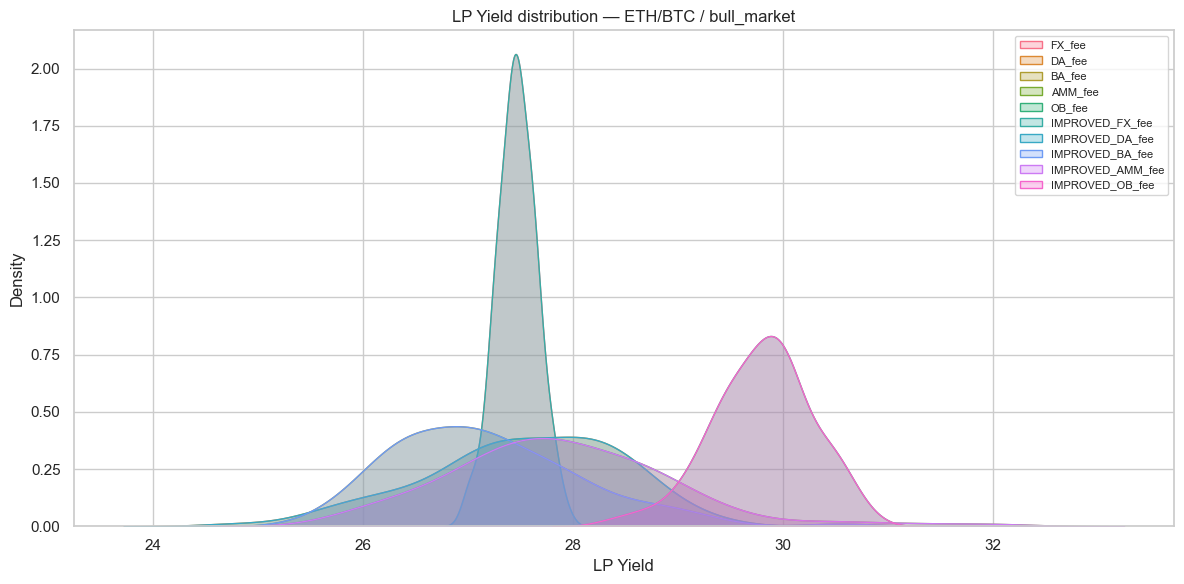

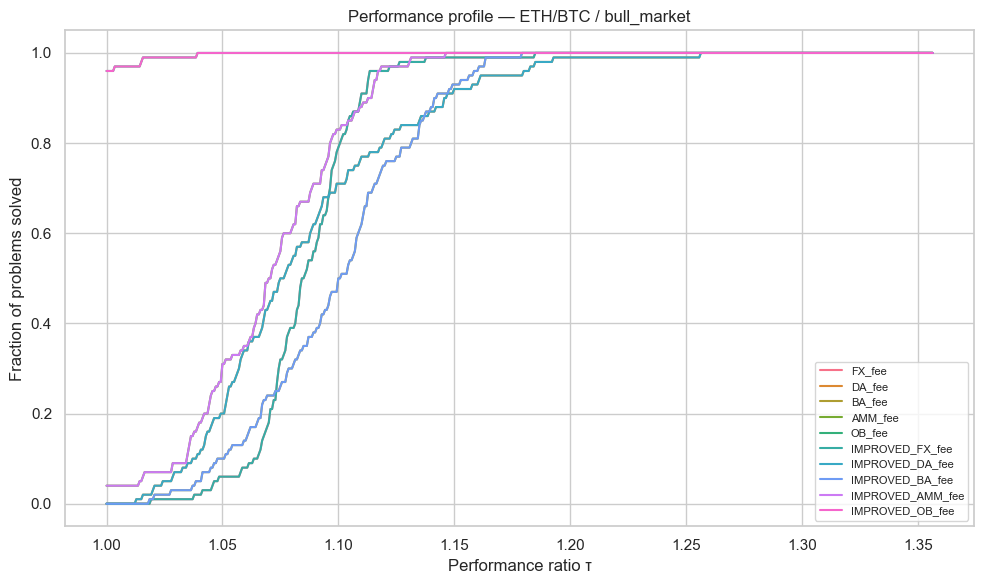

In [37]:
show_stats_for_pair_alias("ETH/BTC", "bull_market")
plot_yield_stats("ETH/BTC", "bull_market")
plot_performance_profile("ETH/BTC", "bull_market")

##### calm_market


=== ETH/BTC / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,71.13 ± 15.14,46.21 ± 7.06,1.71 ± 0.21,-8179.65 ± 299.11,722.75 ± 25.04,-56.80 ± 0.90,5286.39 ± 384.16,28.46 ± 1.27,-3367.20 ± 2468.15
BA_fee,76.89 ± 15.64,53.05 ± 8.07,1.62 ± 0.20,-8183.65 ± 291.30,723.33 ± 24.67,-56.80 ± 0.93,5231.49 ± 345.12,27.31 ± 1.24,-3390.17 ± 2503.76
DA_fee,70.10 ± 13.68,51.79 ± 8.19,1.52 ± 0.18,-8183.89 ± 296.79,722.96 ± 24.69,-56.83 ± 0.99,5102.73 ± 334.06,26.86 ± 1.40,-2740.21 ± 3386.18
FX_fee,73.36 ± 14.23,51.80 ± 8.46,1.59 ± 0.18,-8179.08 ± 287.98,723.04 ± 24.52,-56.79 ± 0.99,5156.88 ± 227.75,27.11 ± 0.18,-3021.27 ± 2932.24
IMPROVED_AMM_fee,71.13 ± 15.14,46.21 ± 7.06,1.71 ± 0.21,-8179.65 ± 299.11,722.75 ± 25.04,-56.80 ± 0.90,5286.39 ± 384.16,28.46 ± 1.27,-3367.20 ± 2468.15
IMPROVED_BA_fee,76.89 ± 15.64,53.05 ± 8.07,1.62 ± 0.20,-8183.65 ± 291.30,723.33 ± 24.67,-56.80 ± 0.93,5231.49 ± 345.12,27.31 ± 1.24,-3390.17 ± 2503.76
IMPROVED_DA_fee,70.10 ± 13.68,51.79 ± 8.19,1.52 ± 0.18,-8183.89 ± 296.79,722.96 ± 24.69,-56.83 ± 0.99,5102.73 ± 334.06,26.86 ± 1.40,-2740.21 ± 3386.18
IMPROVED_FX_fee,73.36 ± 14.23,51.80 ± 8.46,1.59 ± 0.18,-8179.08 ± 287.98,723.04 ± 24.52,-56.79 ± 0.99,5156.88 ± 227.75,27.11 ± 0.18,-3021.27 ± 2932.24
IMPROVED_OB_fee,53.51 ± 14.12,37.90 ± 8.63,1.59 ± 0.24,-8180.62 ± 296.12,722.84 ± 24.85,-56.81 ± 0.89,5377.94 ± 324.41,30.23 ± 0.48,-3256.30 ± 2753.51


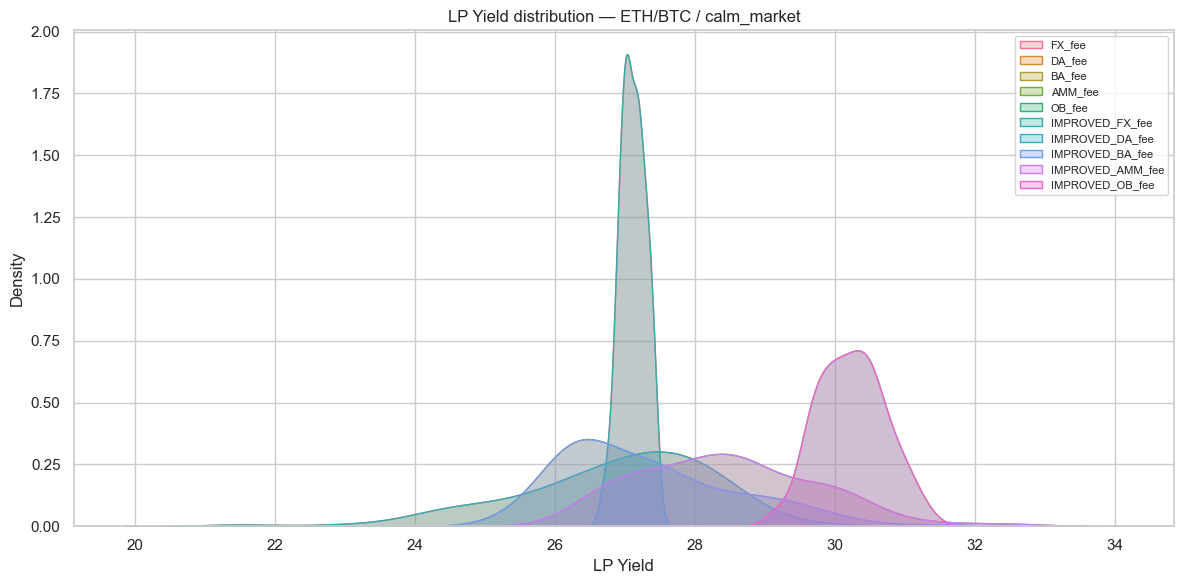

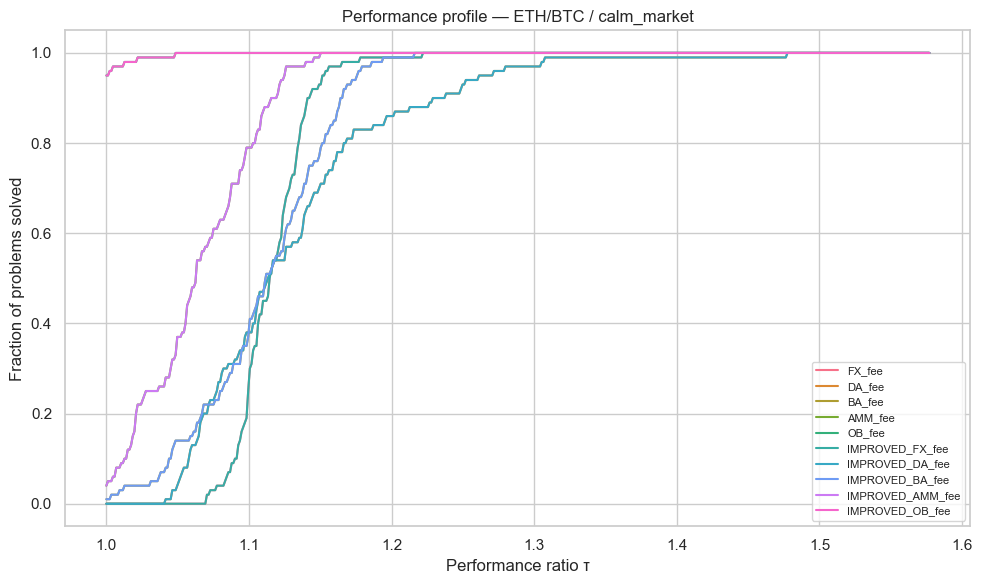

In [38]:
show_stats_for_pair_alias("ETH/BTC", "calm_market")
plot_yield_stats("ETH/BTC", "calm_market")
plot_performance_profile("ETH/BTC", "calm_market")

##### bear_market


=== ETH/BTC / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,43.01 ± 10.13,33.57 ± 5.56,1.46 ± 0.22,-8107.09 ± 286.70,723.51 ± 24.82,-57.16 ± 0.85,4820.91 ± 295.83,28.14 ± 1.14,-3694.75 ± 1445.38
BA_fee,44.08 ± 10.81,37.69 ± 7.11,1.34 ± 0.17,-8104.77 ± 287.09,723.16 ± 24.46,-57.17 ± 0.96,4782.88 ± 273.80,27.41 ± 1.01,-3670.56 ± 1512.91
DA_fee,37.40 ± 9.53,35.06 ± 7.10,1.24 ± 0.17,-8112.19 ± 292.23,722.74 ± 24.71,-57.26 ± 0.97,4728.04 ± 275.25,27.51 ± 1.14,-3267.15 ± 2090.98
FX_fee,39.69 ± 9.26,35.69 ± 7.01,1.29 ± 0.19,-8099.30 ± 292.80,722.96 ± 24.85,-57.15 ± 0.95,4744.37 ± 200.37,27.49 ± 0.17,-3429.40 ± 1800.63
IMPROVED_AMM_fee,43.01 ± 10.13,33.57 ± 5.56,1.46 ± 0.22,-8107.09 ± 286.70,723.51 ± 24.82,-57.16 ± 0.85,4820.91 ± 295.83,28.14 ± 1.14,-3694.75 ± 1445.38
IMPROVED_BA_fee,44.08 ± 10.81,37.69 ± 7.11,1.34 ± 0.17,-8104.77 ± 287.09,723.16 ± 24.46,-57.17 ± 0.96,4782.88 ± 273.80,27.41 ± 1.01,-3670.56 ± 1512.91
IMPROVED_DA_fee,37.40 ± 9.53,35.06 ± 7.10,1.24 ± 0.17,-8112.19 ± 292.23,722.74 ± 24.71,-57.26 ± 0.97,4728.04 ± 275.25,27.51 ± 1.14,-3267.15 ± 2090.98
IMPROVED_FX_fee,39.69 ± 9.26,35.69 ± 7.01,1.29 ± 0.19,-8099.30 ± 292.80,722.96 ± 24.85,-57.15 ± 0.95,4744.37 ± 200.37,27.49 ± 0.17,-3429.40 ± 1800.63
IMPROVED_OB_fee,30.32 ± 10.29,26.30 ± 7.86,1.33 ± 0.24,-8119.47 ± 292.23,723.27 ± 24.84,-57.26 ± 0.84,4905.10 ± 279.60,29.79 ± 0.47,-3633.22 ± 1621.39


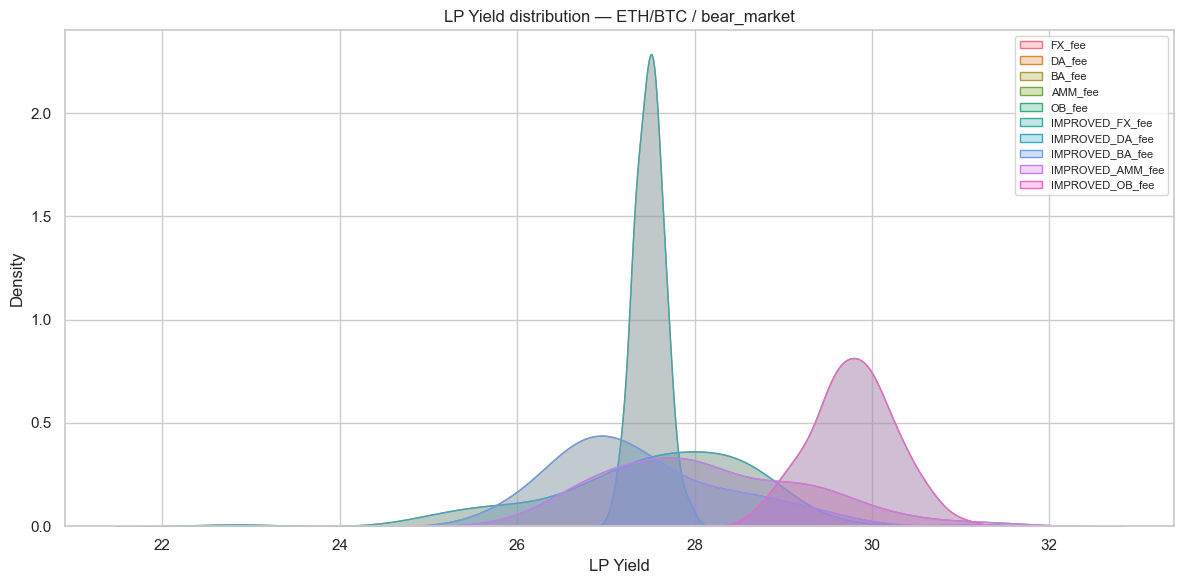

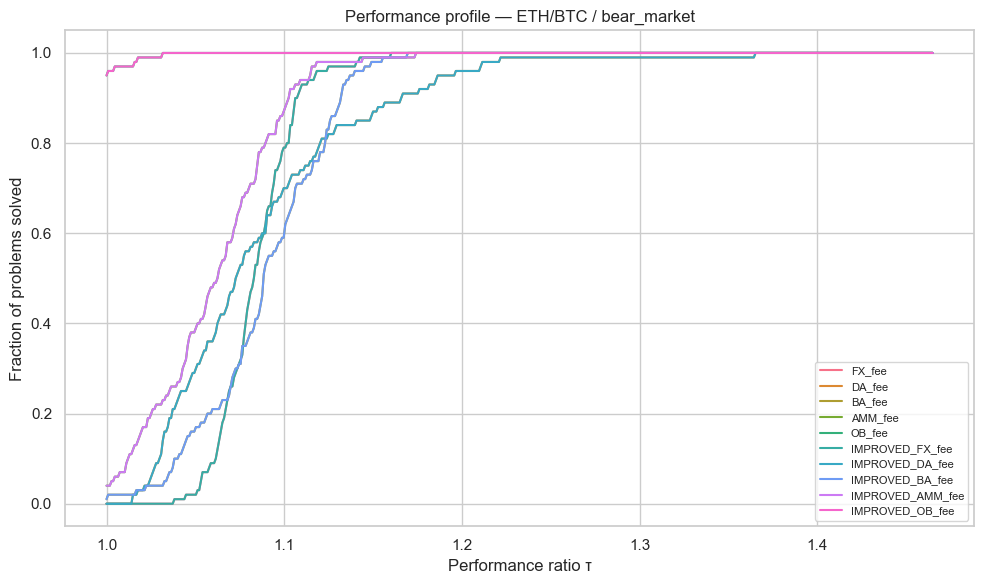

In [39]:
show_stats_for_pair_alias("ETH/BTC", "bear_market")
plot_yield_stats("ETH/BTC", "bear_market")
plot_performance_profile("ETH/BTC", "bear_market")

#### BNB/ETH

##### volatile_market


=== BNB/ETH / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,140.47 ± 24.40,70.15 ± 8.99,2.14 ± 0.20,-8258.15 ± 300.80,723.87 ± 24.95,-56.61 ± 0.85,6055.19 ± 451.63,28.62 ± 1.23,-4193.52 ± 3179.90
BA_fee,159.15 ± 25.47,82.98 ± 11.25,2.06 ± 0.17,-8240.37 ± 289.67,723.23 ± 24.64,-56.54 ± 0.87,5948.52 ± 437.82,26.69 ± 1.27,-4301.16 ± 2931.21
DA_fee,155.29 ± 28.02,84.19 ± 12.45,1.99 ± 0.18,-8251.23 ± 299.33,723.01 ± 24.37,-56.63 ± 0.87,5843.74 ± 399.90,26.16 ± 1.29,-3702.98 ± 4020.00
FX_fee,158.99 ± 28.19,83.12 ± 11.45,2.06 ± 0.19,-8242.07 ± 287.88,722.99 ± 24.44,-56.57 ± 0.84,5893.40 ± 291.03,26.44 ± 0.20,-3998.62 ± 3443.36
IMPROVED_AMM_fee,140.47 ± 24.40,70.15 ± 8.99,2.14 ± 0.20,-8258.15 ± 300.80,723.87 ± 24.95,-56.61 ± 0.85,6055.19 ± 451.63,28.62 ± 1.23,-4193.52 ± 3179.90
IMPROVED_BA_fee,159.15 ± 25.47,82.98 ± 11.25,2.06 ± 0.17,-8240.37 ± 289.67,723.23 ± 24.64,-56.54 ± 0.87,5948.52 ± 437.82,26.69 ± 1.27,-4301.16 ± 2931.21
IMPROVED_DA_fee,155.29 ± 28.02,84.19 ± 12.45,1.99 ± 0.18,-8251.23 ± 299.33,723.01 ± 24.37,-56.63 ± 0.87,5843.74 ± 399.90,26.16 ± 1.29,-3702.98 ± 4020.00
IMPROVED_FX_fee,158.99 ± 28.19,83.12 ± 11.45,2.06 ± 0.19,-8242.07 ± 287.88,722.99 ± 24.44,-56.57 ± 0.84,5893.40 ± 291.03,26.44 ± 0.20,-3998.62 ± 3443.36
IMPROVED_OB_fee,115.97 ± 27.24,59.37 ± 11.19,2.09 ± 0.26,-8244.90 ± 291.57,723.22 ± 24.61,-56.57 ± 0.82,6219.09 ± 416.51,30.92 ± 0.48,-4229.57 ± 3343.88


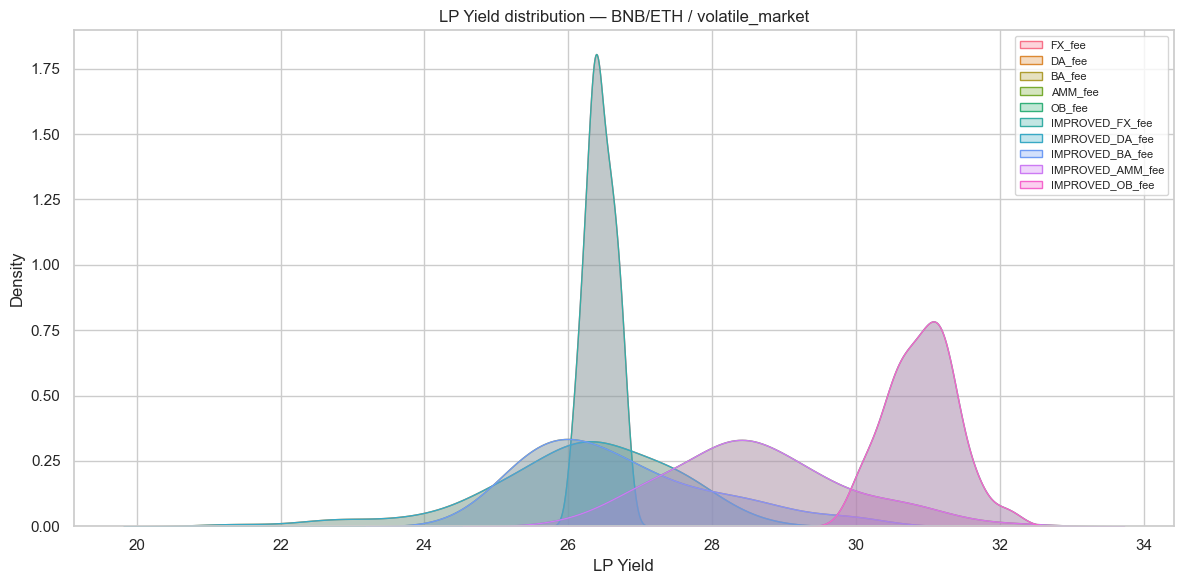

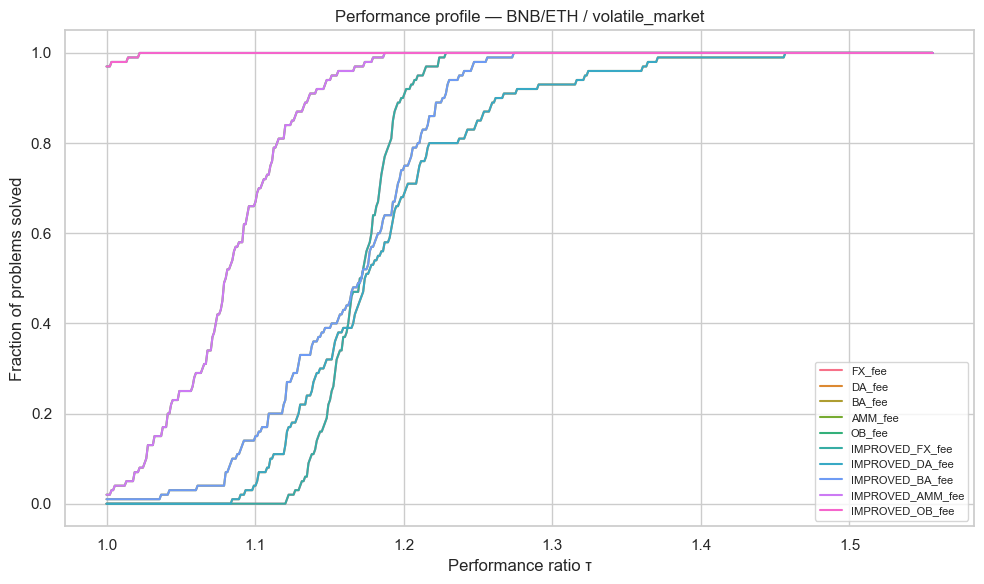

In [40]:
show_stats_for_pair_alias("BNB/ETH", "volatile_market")
plot_yield_stats("BNB/ETH", "volatile_market")
plot_performance_profile("BNB/ETH", "volatile_market")

##### bull_market


=== BNB/ETH / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,83.48 ± 15.29,51.43 ± 7.87,1.80 ± 0.19,-8184.89 ± 287.21,723.19 ± 24.81,-56.96 ± 0.87,5364.10 ± 374.27,28.19 ± 1.13,-4334.71 ± 1913.21
BA_fee,92.46 ± 20.35,59.46 ± 9.96,1.72 ± 0.20,-8176.22 ± 289.03,723.36 ± 24.96,-56.89 ± 0.93,5301.76 ± 354.87,26.88 ± 1.11,-4386.22 ± 1779.49
DA_fee,88.61 ± 19.72,58.24 ± 10.25,1.69 ± 0.19,-8186.97 ± 295.59,723.11 ± 24.58,-56.99 ± 0.88,5255.90 ± 311.79,26.84 ± 1.11,-3997.07 ± 2503.48
FX_fee,90.48 ± 18.27,58.35 ± 10.18,1.72 ± 0.18,-8179.70 ± 284.08,723.33 ± 24.17,-56.92 ± 0.91,5287.17 ± 259.06,26.95 ± 0.20,-4205.34 ± 2127.88
IMPROVED_AMM_fee,83.48 ± 15.29,51.43 ± 7.87,1.80 ± 0.19,-8184.89 ± 287.21,723.19 ± 24.81,-56.96 ± 0.87,5364.10 ± 374.27,28.19 ± 1.13,-4334.71 ± 1913.21
IMPROVED_BA_fee,92.46 ± 20.35,59.46 ± 9.96,1.72 ± 0.20,-8176.22 ± 289.03,723.36 ± 24.96,-56.89 ± 0.93,5301.76 ± 354.87,26.88 ± 1.11,-4386.22 ± 1779.49
IMPROVED_DA_fee,88.61 ± 19.72,58.24 ± 10.25,1.69 ± 0.19,-8186.97 ± 295.59,723.11 ± 24.58,-56.99 ± 0.88,5255.90 ± 311.79,26.84 ± 1.11,-3997.07 ± 2503.48
IMPROVED_FX_fee,90.48 ± 18.27,58.35 ± 10.18,1.72 ± 0.18,-8179.70 ± 284.08,723.33 ± 24.17,-56.92 ± 0.91,5287.17 ± 259.06,26.95 ± 0.20,-4205.34 ± 2127.88
IMPROVED_OB_fee,64.27 ± 17.24,41.76 ± 9.14,1.71 ± 0.24,-8185.16 ± 289.34,723.58 ± 24.69,-56.93 ± 0.84,5503.26 ± 318.37,30.34 ± 0.46,-4370.63 ± 2031.58


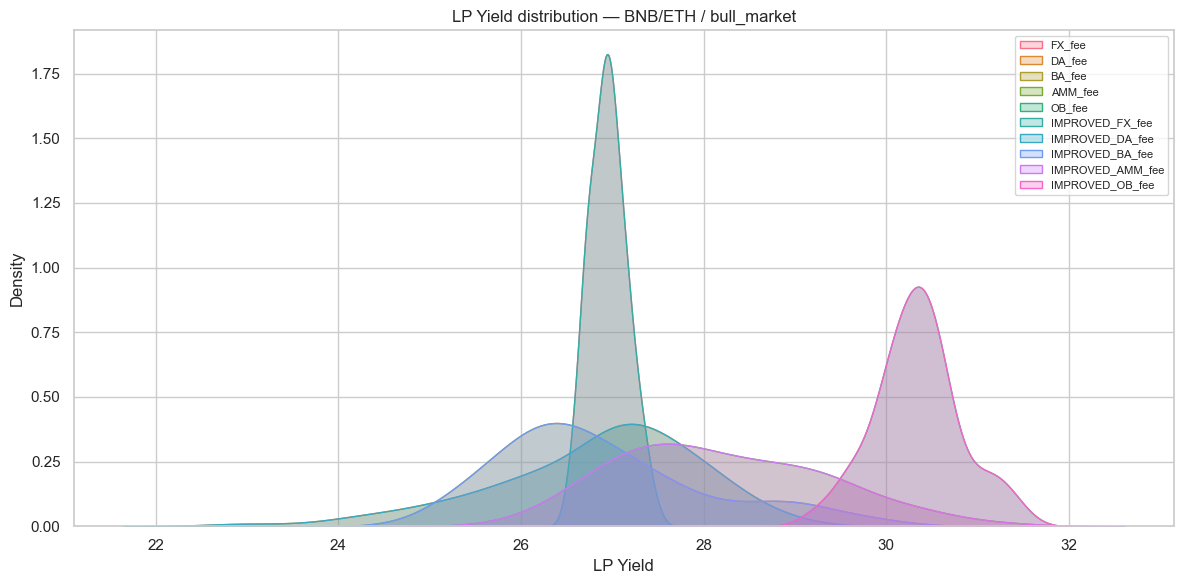

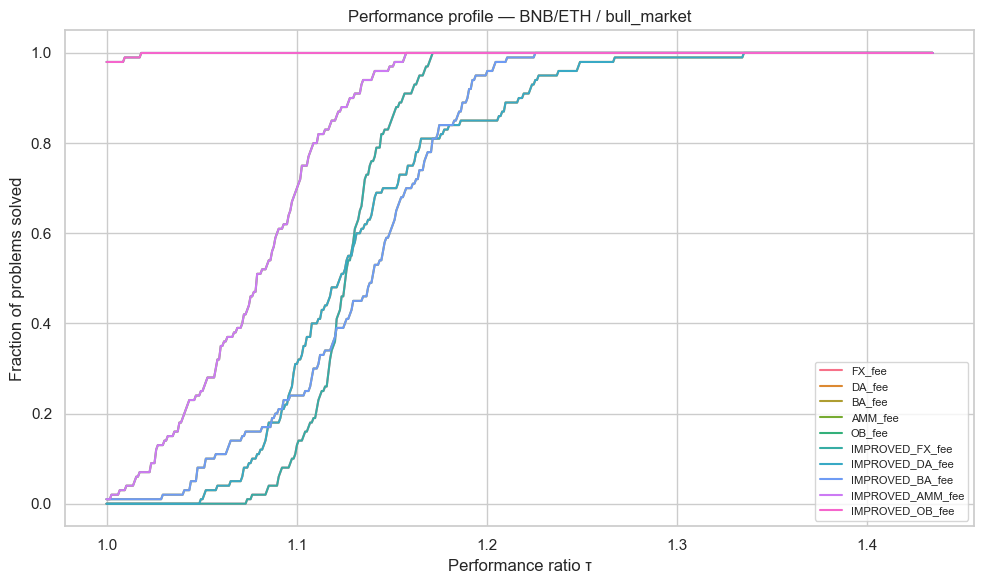

In [41]:
show_stats_for_pair_alias("BNB/ETH", "bull_market")
plot_yield_stats("BNB/ETH", "bull_market")
plot_performance_profile("BNB/ETH", "bull_market")

##### calm_market


=== BNB/ETH / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,88.24 ± 16.09,52.67 ± 7.42,1.84 ± 0.20,-8184.67 ± 299.93,723.94 ± 25.15,-56.93 ± 0.90,5414.78 ± 362.40,28.26 ± 1.21,-4252.80 ± 2112.63
BA_fee,96.04 ± 18.09,60.57 ± 9.34,1.76 ± 0.19,-8173.76 ± 293.59,723.26 ± 24.64,-56.91 ± 0.91,5334.77 ± 334.28,26.91 ± 1.11,-4284.54 ± 2034.96
DA_fee,91.72 ± 18.96,60.33 ± 9.97,1.69 ± 0.18,-8178.86 ± 299.50,723.20 ± 24.47,-56.96 ± 0.94,5289.49 ± 314.96,26.76 ± 1.05,-3890.55 ± 2734.84
FX_fee,93.34 ± 18.21,60.26 ± 9.83,1.72 ± 0.17,-8171.32 ± 300.85,723.27 ± 24.86,-56.89 ± 0.93,5323.32 ± 254.51,26.92 ± 0.20,-4085.61 ± 2420.94
IMPROVED_AMM_fee,88.24 ± 16.09,52.67 ± 7.42,1.84 ± 0.20,-8184.67 ± 299.93,723.94 ± 25.15,-56.93 ± 0.90,5414.78 ± 362.40,28.26 ± 1.21,-4252.80 ± 2112.63
IMPROVED_BA_fee,96.04 ± 18.09,60.57 ± 9.34,1.76 ± 0.19,-8173.76 ± 293.59,723.26 ± 24.64,-56.91 ± 0.91,5334.77 ± 334.28,26.91 ± 1.11,-4284.54 ± 2034.96
IMPROVED_DA_fee,91.72 ± 18.96,60.33 ± 9.97,1.69 ± 0.18,-8178.86 ± 299.50,723.20 ± 24.47,-56.96 ± 0.94,5289.49 ± 314.96,26.76 ± 1.05,-3890.55 ± 2734.84
IMPROVED_FX_fee,93.34 ± 18.21,60.26 ± 9.83,1.72 ± 0.17,-8171.32 ± 300.85,723.27 ± 24.86,-56.89 ± 0.93,5323.32 ± 254.51,26.92 ± 0.20,-4085.61 ± 2420.94
IMPROVED_OB_fee,66.98 ± 17.17,43.00 ± 9.55,1.73 ± 0.23,-8182.48 ± 291.17,723.83 ± 25.02,-56.93 ± 0.82,5546.77 ± 324.51,30.39 ± 0.46,-4275.92 ± 2274.96


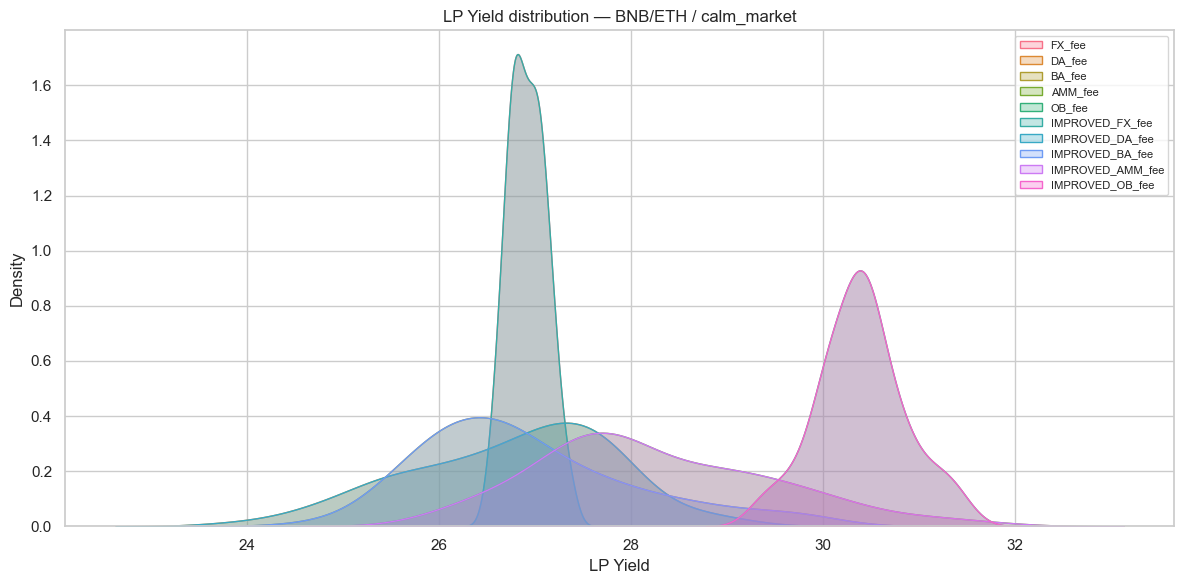

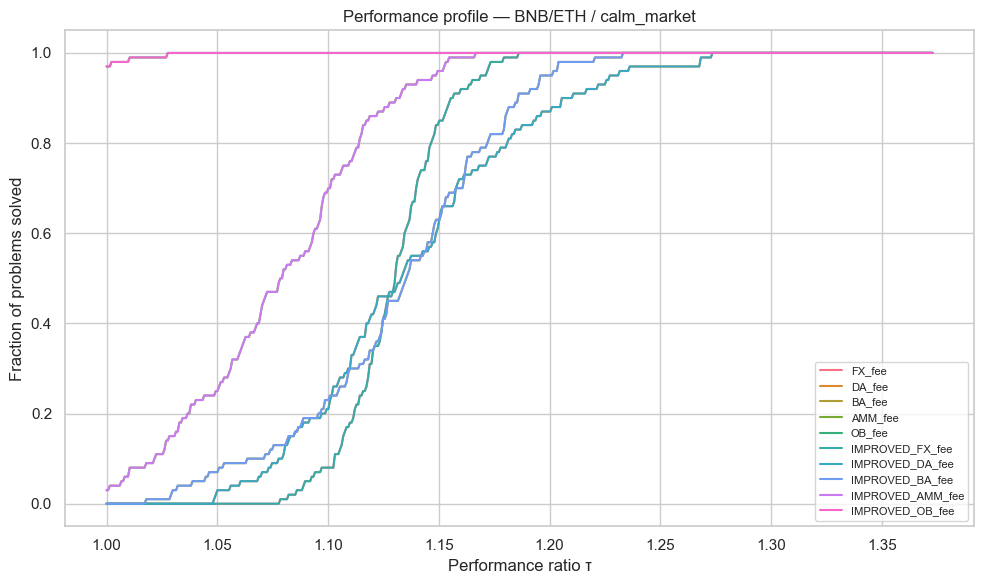

In [42]:
show_stats_for_pair_alias("BNB/ETH", "calm_market")
plot_yield_stats("BNB/ETH", "calm_market")
plot_performance_profile("BNB/ETH", "calm_market")

##### bear_market


=== BNB/ETH / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,132.60 ± 24.14,68.08 ± 9.32,2.12 ± 0.21,-8075.09 ± 280.16,723.00 ± 24.53,-57.40 ± 0.93,5826.68 ± 460.71,28.68 ± 1.33,-3661.45 ± 3132.08
BA_fee,151.85 ± 24.81,80.37 ± 10.51,2.07 ± 0.19,-8082.83 ± 292.19,723.29 ± 24.30,-57.43 ± 1.01,5709.56 ± 382.32,26.69 ± 1.24,-3728.29 ± 3066.67
DA_fee,147.84 ± 22.30,81.75 ± 10.40,2.00 ± 0.15,-8093.85 ± 298.19,723.38 ± 24.62,-57.50 ± 1.03,5627.65 ± 387.71,26.19 ± 1.34,-3181.39 ± 3905.27
FX_fee,148.85 ± 25.40,81.04 ± 10.49,2.02 ± 0.17,-8072.62 ± 290.51,722.39 ± 24.34,-57.42 ± 1.00,5659.03 ± 264.46,26.43 ± 0.19,-3423.80 ± 3483.09
IMPROVED_AMM_fee,132.60 ± 24.14,68.08 ± 9.32,2.12 ± 0.21,-8075.09 ± 280.16,723.00 ± 24.53,-57.40 ± 0.93,5826.68 ± 460.71,28.68 ± 1.33,-3661.45 ± 3132.08
IMPROVED_BA_fee,151.85 ± 24.81,80.37 ± 10.51,2.07 ± 0.19,-8082.83 ± 292.19,723.29 ± 24.30,-57.43 ± 1.01,5709.56 ± 382.32,26.69 ± 1.24,-3728.29 ± 3066.67
IMPROVED_DA_fee,147.84 ± 22.30,81.75 ± 10.40,2.00 ± 0.15,-8093.85 ± 298.19,723.38 ± 24.62,-57.50 ± 1.03,5627.65 ± 387.71,26.19 ± 1.34,-3181.39 ± 3905.27
IMPROVED_FX_fee,148.85 ± 25.40,81.04 ± 10.49,2.02 ± 0.17,-8072.62 ± 290.51,722.39 ± 24.34,-57.42 ± 1.00,5659.03 ± 264.46,26.43 ± 0.19,-3423.80 ± 3483.09
IMPROVED_OB_fee,106.70 ± 22.56,58.71 ± 10.38,2.00 ± 0.21,-8082.94 ± 290.32,723.55 ± 25.01,-57.41 ± 0.90,6009.22 ± 368.12,30.95 ± 0.44,-3671.26 ± 3367.40


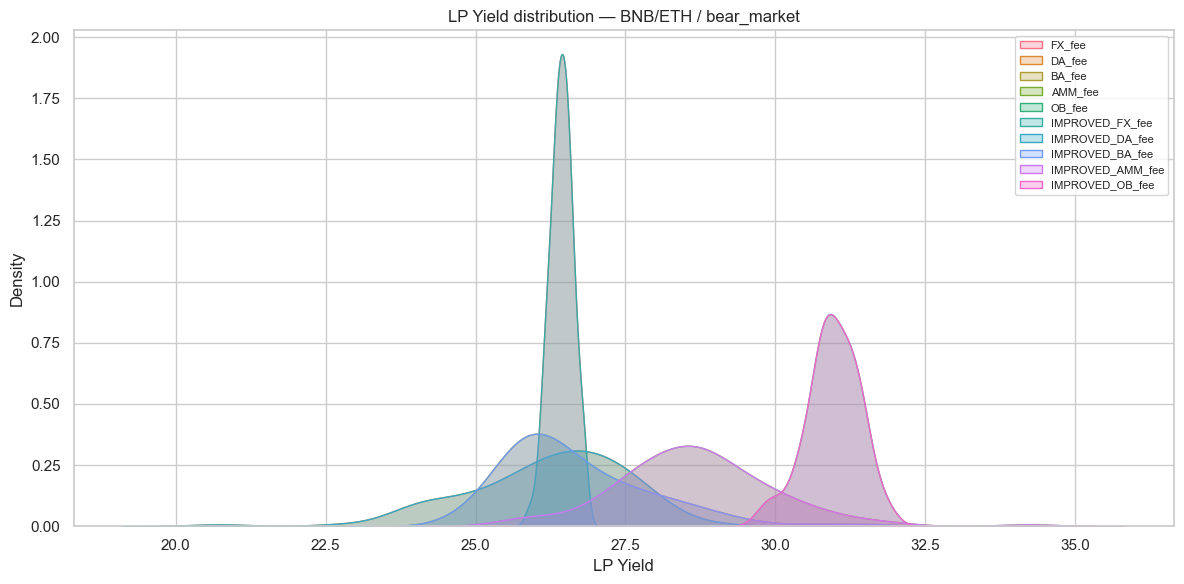

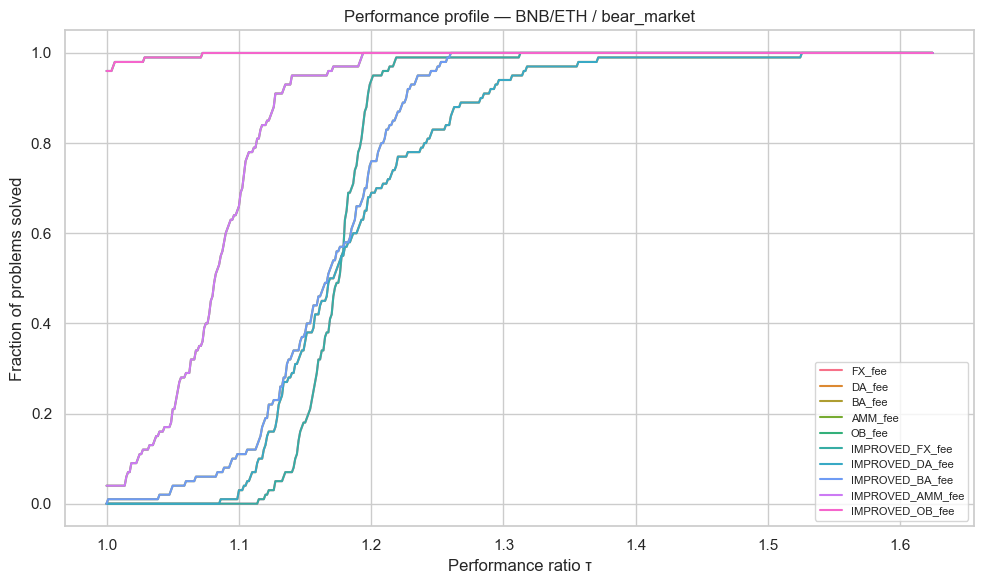

In [43]:
show_stats_for_pair_alias("BNB/ETH", "bear_market")
plot_yield_stats("BNB/ETH", "bear_market")
plot_performance_profile("BNB/ETH", "bear_market")

#### DOGE/BTC

##### volatile_market


=== DOGE/BTC / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,8751.38 ± 733.66,395.47 ± 34.58,13.25 ± 1.23,-8423.25 ± 355.39,723.11 ± 23.92,-55.84 ± 1.34,17410.69 ± 2864.68,21.33 ± 2.63,79171.63 ± 122846.08
BA_fee,10264.47 ± 946.78,396.48 ± 36.00,14.58 ± 1.45,-8385.19 ± 379.39,722.60 ± 24.86,-55.63 ± 1.51,14854.37 ± 3811.11,17.23 ± 3.80,79260.22 ± 120238.63
DA_fee,9528.02 ± 1177.43,438.05 ± 42.43,12.48 ± 1.49,-8389.52 ± 338.61,722.39 ± 24.11,-55.68 ± 1.39,14794.72 ± 2437.28,16.18 ± 2.56,82635.86 ± 127465.45
FX_fee,8216.21 ± 837.77,478.18 ± 72.42,10.52 ± 1.54,-8395.35 ± 340.83,722.98 ± 24.05,-55.66 ± 1.27,17321.91 ± 2132.56,18.39 ± 1.05,80131.82 ± 123397.10
IMPROVED_AMM_fee,8751.38 ± 733.66,395.47 ± 34.58,13.25 ± 1.23,-8423.25 ± 355.39,723.11 ± 23.92,-55.84 ± 1.34,17410.69 ± 2864.68,21.33 ± 2.63,79171.63 ± 122846.08
IMPROVED_BA_fee,10264.47 ± 946.78,396.48 ± 36.00,14.58 ± 1.45,-8385.19 ± 379.39,722.60 ± 24.86,-55.63 ± 1.51,14854.37 ± 3811.11,17.23 ± 3.80,79260.22 ± 120238.63
IMPROVED_DA_fee,9528.02 ± 1177.43,438.05 ± 42.43,12.48 ± 1.49,-8389.52 ± 338.61,722.39 ± 24.11,-55.68 ± 1.39,14794.72 ± 2437.28,16.18 ± 2.56,82635.86 ± 127465.45
IMPROVED_FX_fee,8216.21 ± 837.77,478.18 ± 72.42,10.52 ± 1.54,-8395.35 ± 340.83,722.98 ± 24.05,-55.66 ± 1.27,17321.91 ± 2132.56,18.39 ± 1.05,80131.82 ± 123397.10
IMPROVED_OB_fee,4123.54 ± 349.03,482.68 ± 28.93,6.70 ± 0.22,-8400.21 ± 343.38,723.02 ± 24.58,-55.69 ± 1.22,25453.08 ± 1678.61,33.21 ± 0.19,75709.01 ± 123773.15


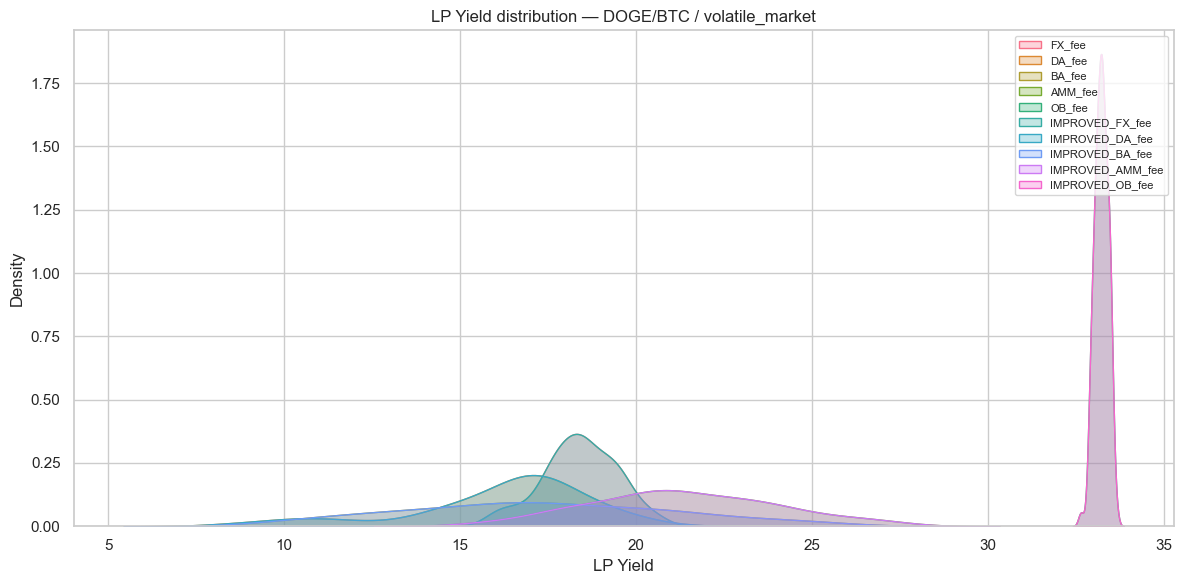

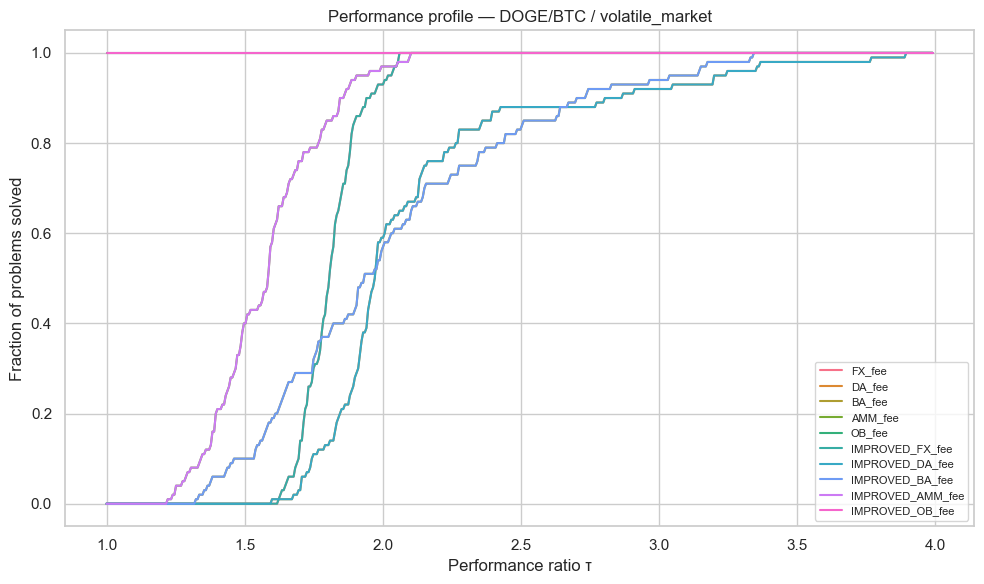

In [44]:
show_stats_for_pair_alias("DOGE/BTC", "volatile_market")
plot_yield_stats("DOGE/BTC", "volatile_market")
plot_performance_profile("DOGE/BTC", "volatile_market")

##### bull_market


=== DOGE/BTC / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1277.37 ± 154.17,124.87 ± 15.34,8.20 ± 0.91,-8128.67 ± 310.45,723.55 ± 24.59,-56.84 ± 1.13,7872.90 ± 898.91,26.25 ± 2.12,-2136.94 ± 9946.05
BA_fee,1578.39 ± 262.99,134.12 ± 17.49,9.01 ± 1.37,-8140.58 ± 319.30,722.78 ± 24.70,-56.98 ± 1.08,7304.24 ± 901.41,22.91 ± 2.41,-2132.88 ± 9452.48
DA_fee,1394.46 ± 314.22,147.56 ± 20.93,7.50 ± 1.58,-8148.65 ± 324.13,722.70 ± 24.54,-57.05 ± 1.13,7390.74 ± 765.06,22.43 ± 1.74,-1600.21 ± 10809.71
FX_fee,815.29 ± 141.00,184.46 ± 19.64,4.16 ± 0.68,-8151.08 ± 307.40,723.29 ± 25.01,-57.02 ± 1.04,8229.20 ± 493.72,24.25 ± 0.34,-2195.37 ± 10313.89
IMPROVED_AMM_fee,1277.37 ± 154.17,124.87 ± 15.34,8.20 ± 0.91,-8128.67 ± 310.45,723.55 ± 24.59,-56.84 ± 1.13,7872.90 ± 898.91,26.25 ± 2.12,-2136.94 ± 9946.05
IMPROVED_BA_fee,1578.39 ± 262.99,134.12 ± 17.49,9.01 ± 1.37,-8140.58 ± 319.30,722.78 ± 24.70,-56.98 ± 1.08,7304.24 ± 901.41,22.91 ± 2.41,-2132.88 ± 9452.48
IMPROVED_DA_fee,1394.46 ± 314.22,147.56 ± 20.93,7.50 ± 1.58,-8148.65 ± 324.13,722.70 ± 24.54,-57.05 ± 1.13,7390.74 ± 765.06,22.43 ± 1.74,-1600.21 ± 10809.71
IMPROVED_FX_fee,815.29 ± 141.00,184.46 ± 19.64,4.16 ± 0.68,-8151.08 ± 307.40,723.29 ± 25.01,-57.02 ± 1.04,8229.20 ± 493.72,24.25 ± 0.34,-2195.37 ± 10313.89
IMPROVED_OB_fee,479.50 ± 69.07,143.83 ± 18.05,3.33 ± 0.25,-8158.09 ± 314.43,723.56 ± 25.19,-57.05 ± 0.94,9362.66 ± 714.59,32.60 ± 0.39,-2807.26 ± 10260.97


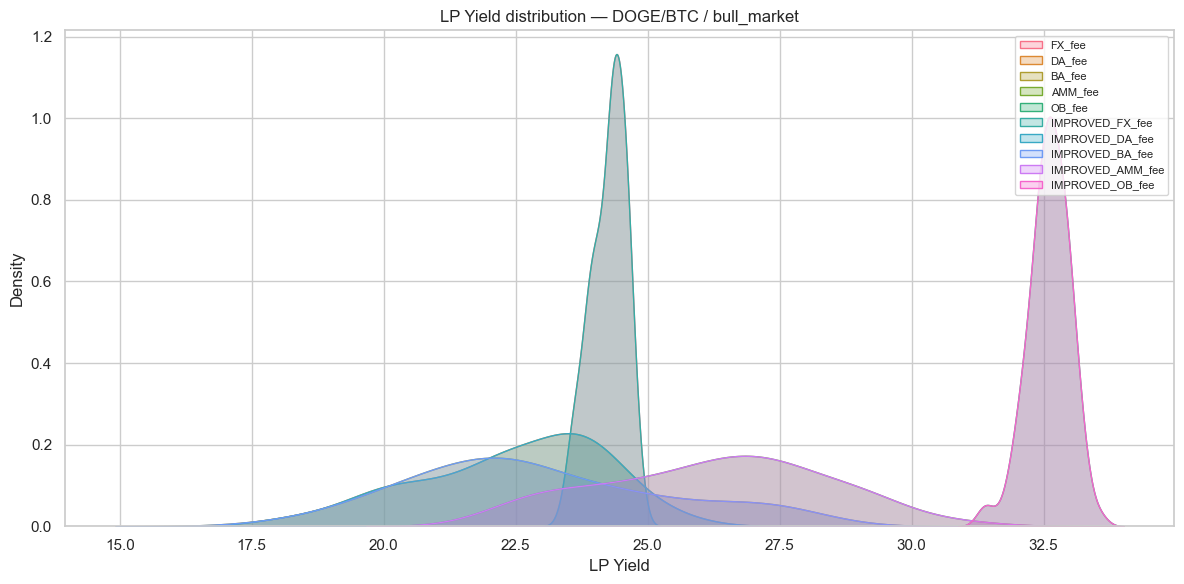

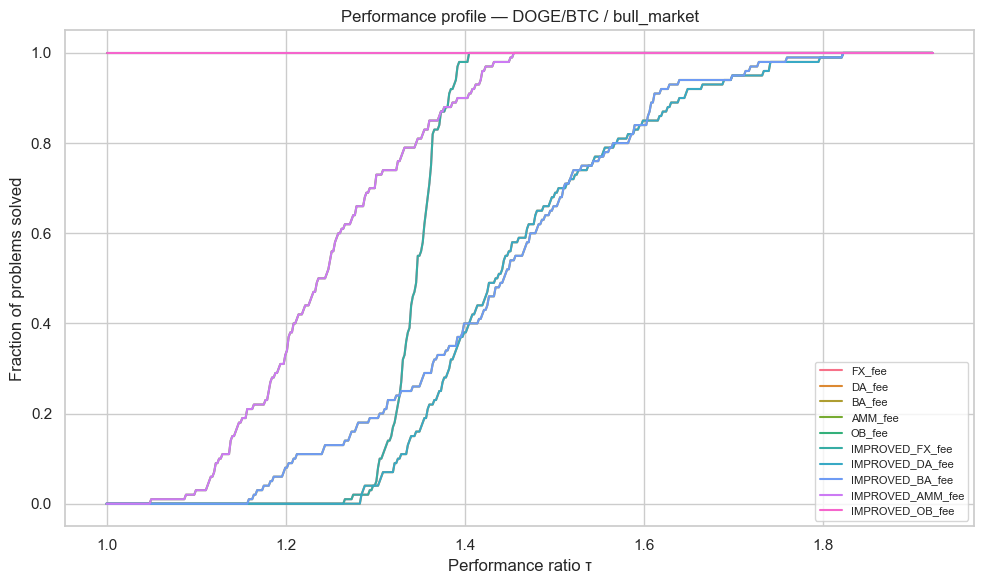

In [45]:
show_stats_for_pair_alias("DOGE/BTC", "bull_market")
plot_yield_stats("DOGE/BTC", "bull_market")
plot_performance_profile("DOGE/BTC", "bull_market")

##### calm_market


=== DOGE/BTC / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,778.77 ± 176.61,59.45 ± 12.49,10.18 ± 2.10,-8145.21 ± 308.95,723.05 ± 24.30,-56.78 ± 1.13,5762.23 ± 633.67,26.11 ± 2.35,82.13 ± 8168.79
BA_fee,887.16 ± 252.33,60.50 ± 13.13,10.55 ± 2.38,-8183.15 ± 298.57,723.28 ± 23.50,-57.03 ± 1.19,5600.39 ± 698.39,24.65 ± 2.99,35.16 ± 8104.89
DA_fee,953.69 ± 263.13,56.52 ± 9.31,11.01 ± 2.13,-8168.21 ± 318.43,723.31 ± 24.65,-56.91 ± 1.04,5294.09 ± 514.24,23.10 ± 2.13,712.22 ± 8965.05
FX_fee,891.24 ± 153.28,53.56 ± 8.38,10.17 ± 0.64,-8166.72 ± 300.05,722.95 ± 24.45,-56.94 ± 1.07,5555.91 ± 284.85,24.06 ± 0.52,385.88 ± 8762.46
IMPROVED_AMM_fee,778.77 ± 176.61,59.45 ± 12.49,10.18 ± 2.10,-8145.21 ± 308.95,723.05 ± 24.30,-56.78 ± 1.13,5762.23 ± 633.67,26.11 ± 2.35,82.13 ± 8168.79
IMPROVED_BA_fee,887.16 ± 252.33,60.50 ± 13.13,10.55 ± 2.38,-8183.15 ± 298.57,723.28 ± 23.50,-57.03 ± 1.19,5600.39 ± 698.39,24.65 ± 2.99,35.16 ± 8104.89
IMPROVED_DA_fee,953.69 ± 263.13,56.52 ± 9.31,11.01 ± 2.13,-8168.21 ± 318.43,723.31 ± 24.65,-56.91 ± 1.04,5294.09 ± 514.24,23.10 ± 2.13,712.22 ± 8965.05
IMPROVED_FX_fee,891.24 ± 153.28,53.56 ± 8.38,10.17 ± 0.64,-8166.72 ± 300.05,722.95 ± 24.45,-56.94 ± 1.07,5555.91 ± 284.85,24.06 ± 0.52,385.88 ± 8762.46
IMPROVED_OB_fee,167.56 ± 34.27,76.75 ± 14.06,2.33 ± 0.21,-8177.81 ± 306.60,723.60 ± 25.89,-56.96 ± 0.98,6777.68 ± 471.69,31.43 ± 0.42,-264.18 ± 8528.55


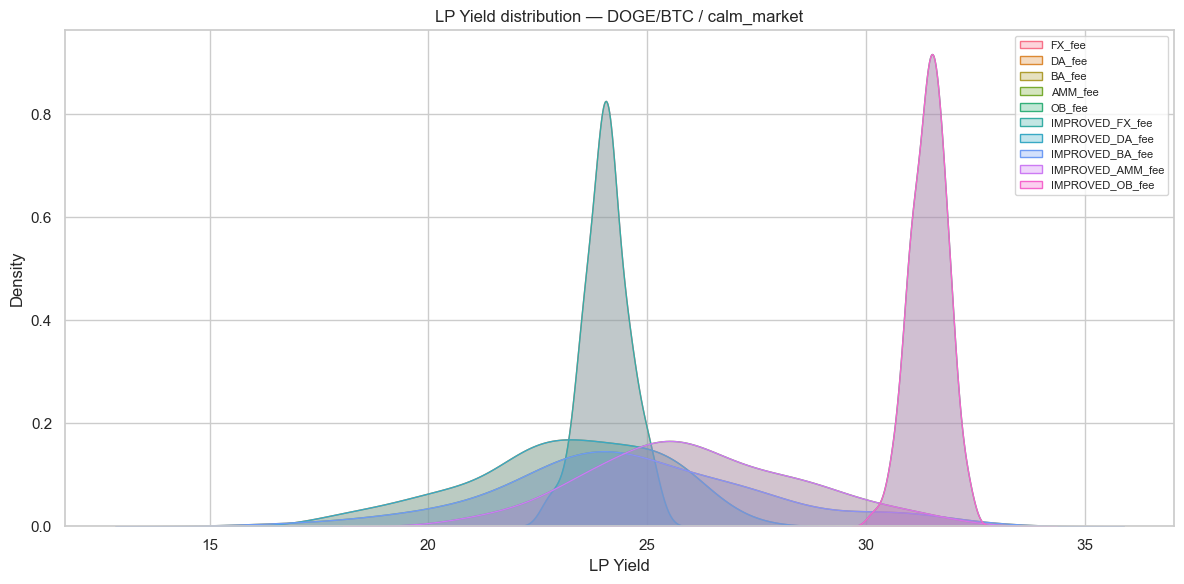

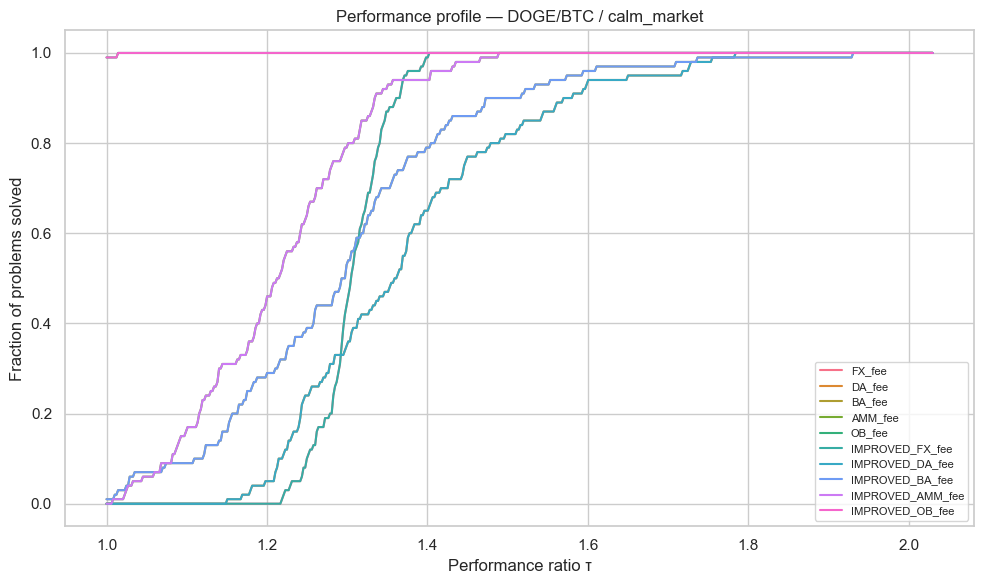

In [46]:
show_stats_for_pair_alias("DOGE/BTC", "calm_market")
plot_yield_stats("DOGE/BTC", "calm_market")
plot_performance_profile("DOGE/BTC", "calm_market")

##### bear_market


=== DOGE/BTC / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,2412.66 ± 202.16,274.27 ± 21.00,7.18 ± 0.42,-8058.93 ± 347.92,722.94 ± 25.23,-57.37 ± 1.18,13037.50 ± 1297.74,27.31 ± 1.76,8177.34 ± 30120.64
BA_fee,2961.79 ± 408.83,306.29 ± 31.67,7.70 ± 1.11,-8068.30 ± 314.07,723.30 ± 24.02,-57.42 ± 1.22,11840.13 ± 1146.71,22.49 ± 1.84,8095.57 ± 29205.29
DA_fee,2740.71 ± 438.48,334.26 ± 30.30,6.71 ± 0.98,-8066.69 ± 325.91,722.91 ± 24.69,-57.43 ± 1.06,11457.17 ± 1175.24,20.84 ± 1.66,9792.31 ± 31461.75
FX_fee,2027.27 ± 168.14,384.11 ± 24.86,4.85 ± 0.20,-8063.35 ± 323.76,722.80 ± 24.17,-57.41 ± 1.18,12606.58 ± 676.31,22.56 ± 0.18,8606.67 ± 30505.05
IMPROVED_AMM_fee,2412.66 ± 202.16,274.27 ± 21.00,7.18 ± 0.42,-8058.93 ± 347.92,722.94 ± 25.23,-57.37 ± 1.18,13037.50 ± 1297.74,27.31 ± 1.76,8177.34 ± 30120.64
IMPROVED_BA_fee,2961.79 ± 408.83,306.29 ± 31.67,7.70 ± 1.11,-8068.30 ± 314.07,723.30 ± 24.02,-57.42 ± 1.22,11840.13 ± 1146.71,22.49 ± 1.84,8095.57 ± 29205.29
IMPROVED_DA_fee,2740.71 ± 438.48,334.26 ± 30.30,6.71 ± 0.98,-8066.69 ± 325.91,722.91 ± 24.69,-57.43 ± 1.06,11457.17 ± 1175.24,20.84 ± 1.66,9792.31 ± 31461.75
IMPROVED_FX_fee,2027.27 ± 168.14,384.11 ± 24.86,4.85 ± 0.20,-8063.35 ± 323.76,722.80 ± 24.17,-57.41 ± 1.18,12606.58 ± 676.31,22.56 ± 0.18,8606.67 ± 30505.05
IMPROVED_OB_fee,1481.33 ± 154.13,277.10 ± 25.03,4.89 ± 0.23,-8063.95 ± 313.95,722.42 ± 24.51,-57.45 ± 1.00,14767.88 ± 1030.65,33.32 ± 0.27,7482.81 ± 30217.19


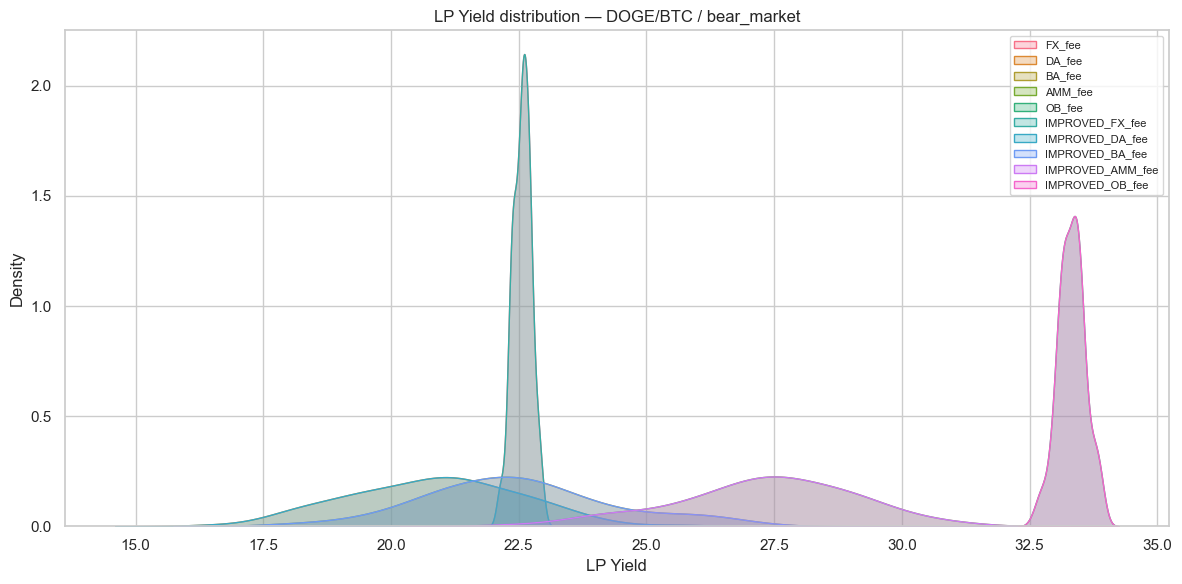

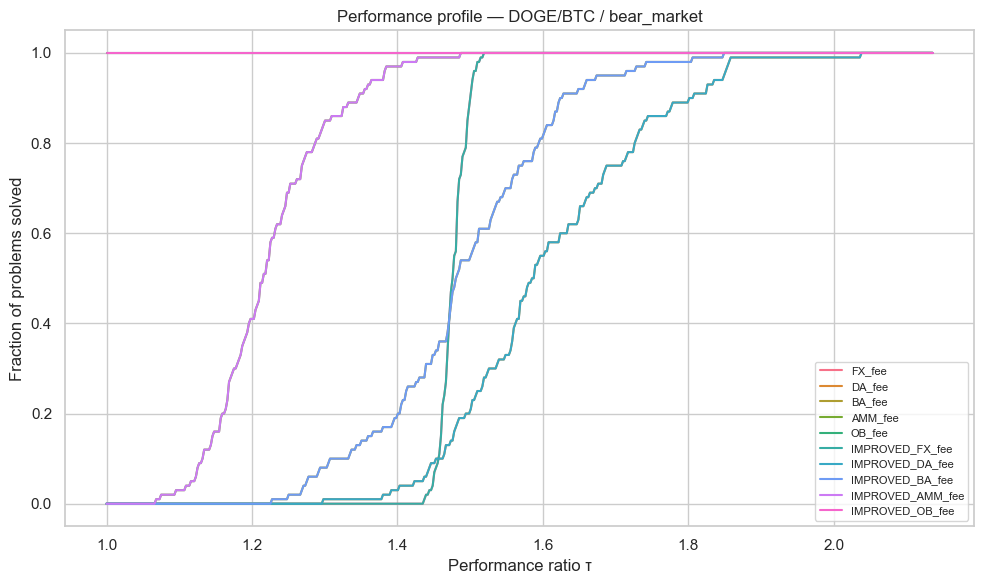

In [47]:
show_stats_for_pair_alias("DOGE/BTC", "bear_market")
plot_yield_stats("DOGE/BTC", "bear_market")
plot_performance_profile("DOGE/BTC", "bear_market")

### Export to CSV

In [48]:
import os

OUTPUT_DIR = "csv_export/synth_data_new_pairs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df.to_csv(f"{OUTPUT_DIR}/all_experiments_raw.csv", index=False)

for pair_name, month_alias in synth_desc.keys():
    safe_name = pair_name.replace("/", "_")
    show_stats_for_pair_alias(
        pair_name, month_alias, f"{OUTPUT_DIR}/{safe_name}_{month_alias}_stats.csv"
    )

print(f"Exported to {OUTPUT_DIR}/")


=== TUSD/USDC / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,18.24 ± 5.92,18.37 ± 4.24,1.14 ± 0.21,-8182.15 ± 273.31,723.56 ± 24.34,-56.73 ± 0.74,4342.94 ± 174.98,27.13 ± 0.61,-4495.61 ± 243.12
BA_fee,15.10 ± 5.51,18.02 ± 5.22,0.98 ± 0.22,-8179.77 ± 277.28,723.91 ± 24.46,-56.69 ± 0.78,4363.53 ± 169.05,27.33 ± 0.47,-4495.46 ± 260.12
DA_fee,9.38 ± 4.94,12.84 ± 4.73,0.83 ± 0.25,-8181.74 ± 282.59,723.29 ± 24.72,-56.75 ± 0.76,4402.95 ± 188.25,28.40 ± 0.52,-4438.60 ± 432.86
FX_fee,11.75 ± 4.98,14.81 ± 4.77,0.93 ± 0.23,-8186.14 ± 281.05,723.42 ± 24.66,-56.77 ± 0.81,4399.63 ± 157.63,28.06 ± 0.13,-4474.27 ± 342.50
IMPROVED_AMM_fee,18.24 ± 5.92,18.37 ± 4.24,1.14 ± 0.21,-8182.15 ± 273.31,723.56 ± 24.34,-56.73 ± 0.74,4342.94 ± 174.98,27.13 ± 0.61,-4495.61 ± 243.12
IMPROVED_BA_fee,15.10 ± 5.51,18.02 ± 5.22,0.98 ± 0.22,-8179.77 ± 277.28,723.91 ± 24.46,-56.69 ± 0.78,4363.53 ± 169.05,27.33 ± 0.47,-4495.46 ± 260.12
IMPROVED_DA_fee,9.38 ± 4.94,12.84 ± 4.73,0.83 ± 0.25,-8181.74 ± 282.59,723.29 ± 24.72,-56.75 ± 0.76,4402.95 ± 188.25,28.40 ± 0.52,-4438.60 ± 432.86
IMPROVED_FX_fee,11.75 ± 4.98,14.81 ± 4.77,0.93 ± 0.23,-8186.14 ± 281.05,723.42 ± 24.66,-56.77 ± 0.81,4399.63 ± 157.63,28.06 ± 0.13,-4474.27 ± 342.50
IMPROVED_OB_fee,7.55 ± 4.35,9.56 ± 4.37,0.91 ± 0.35,-8172.36 ± 286.26,723.35 ± 24.51,-56.68 ± 0.66,4423.31 ± 185.04,29.04 ± 0.41,-4489.31 ± 332.07



=== TUSD/USDC / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,15.83 ± 4.87,16.15 ± 3.76,1.13 ± 0.22,-8168.30 ± 291.43,723.21 ± 24.81,-56.66 ± 0.67,4285.43 ± 165.48,27.11 ± 0.50,-4499.93 ± 218.36
BA_fee,12.90 ± 4.95,15.50 ± 5.03,0.98 ± 0.22,-8173.49 ± 301.56,723.54 ± 24.98,-56.67 ± 0.75,4293.37 ± 161.10,27.27 ± 0.39,-4477.24 ± 249.82
DA_fee,7.26 ± 3.95,10.26 ± 4.66,0.83 ± 0.27,-8171.90 ± 288.22,723.39 ± 24.48,-56.67 ± 0.72,4367.55 ± 175.73,28.57 ± 0.43,-4493.20 ± 327.61
FX_fee,9.43 ± 4.11,12.03 ± 4.53,0.93 ± 0.27,-8173.04 ± 292.46,723.29 ± 24.49,-56.68 ± 0.68,4344.63 ± 155.22,28.14 ± 0.12,-4496.12 ± 276.42
IMPROVED_AMM_fee,15.83 ± 4.87,16.15 ± 3.76,1.13 ± 0.22,-8168.30 ± 291.43,723.21 ± 24.81,-56.66 ± 0.67,4285.43 ± 165.48,27.11 ± 0.50,-4499.93 ± 218.36
IMPROVED_BA_fee,12.90 ± 4.95,15.50 ± 5.03,0.98 ± 0.22,-8173.49 ± 301.56,723.54 ± 24.98,-56.67 ± 0.75,4293.37 ± 161.10,27.27 ± 0.39,-4477.24 ± 249.82
IMPROVED_DA_fee,7.26 ± 3.95,10.26 ± 4.66,0.83 ± 0.27,-8171.90 ± 288.22,723.39 ± 24.48,-56.67 ± 0.72,4367.55 ± 175.73,28.57 ± 0.43,-4493.20 ± 327.61
IMPROVED_FX_fee,9.43 ± 4.11,12.03 ± 4.53,0.93 ± 0.27,-8173.04 ± 292.46,723.29 ± 24.49,-56.68 ± 0.68,4344.63 ± 155.22,28.14 ± 0.12,-4496.12 ± 276.42
IMPROVED_OB_fee,6.64 ± 4.08,8.51 ± 4.68,0.92 ± 0.35,-8182.66 ± 287.60,723.70 ± 24.82,-56.72 ± 0.64,4392.57 ± 173.36,29.00 ± 0.45,-4533.95 ± 258.17



=== TUSD/USDC / calm_market ===


...


=== DOGE/BTC / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,778.77 ± 176.61,59.45 ± 12.49,10.18 ± 2.10,-8145.21 ± 308.95,723.05 ± 24.30,-56.78 ± 1.13,5762.23 ± 633.67,26.11 ± 2.35,82.13 ± 8168.79
BA_fee,887.16 ± 252.33,60.50 ± 13.13,10.55 ± 2.38,-8183.15 ± 298.57,723.28 ± 23.50,-57.03 ± 1.19,5600.39 ± 698.39,24.65 ± 2.99,35.16 ± 8104.89
DA_fee,953.69 ± 263.13,56.52 ± 9.31,11.01 ± 2.13,-8168.21 ± 318.43,723.31 ± 24.65,-56.91 ± 1.04,5294.09 ± 514.24,23.10 ± 2.13,712.22 ± 8965.05
FX_fee,891.24 ± 153.28,53.56 ± 8.38,10.17 ± 0.64,-8166.72 ± 300.05,722.95 ± 24.45,-56.94 ± 1.07,5555.91 ± 284.85,24.06 ± 0.52,385.88 ± 8762.46
IMPROVED_AMM_fee,778.77 ± 176.61,59.45 ± 12.49,10.18 ± 2.10,-8145.21 ± 308.95,723.05 ± 24.30,-56.78 ± 1.13,5762.23 ± 633.67,26.11 ± 2.35,82.13 ± 8168.79
IMPROVED_BA_fee,887.16 ± 252.33,60.50 ± 13.13,10.55 ± 2.38,-8183.15 ± 298.57,723.28 ± 23.50,-57.03 ± 1.19,5600.39 ± 698.39,24.65 ± 2.99,35.16 ± 8104.89
IMPROVED_DA_fee,953.69 ± 263.13,56.52 ± 9.31,11.01 ± 2.13,-8168.21 ± 318.43,723.31 ± 24.65,-56.91 ± 1.04,5294.09 ± 514.24,23.10 ± 2.13,712.22 ± 8965.05
IMPROVED_FX_fee,891.24 ± 153.28,53.56 ± 8.38,10.17 ± 0.64,-8166.72 ± 300.05,722.95 ± 24.45,-56.94 ± 1.07,5555.91 ± 284.85,24.06 ± 0.52,385.88 ± 8762.46
IMPROVED_OB_fee,167.56 ± 34.27,76.75 ± 14.06,2.33 ± 0.21,-8177.81 ± 306.60,723.60 ± 25.89,-56.96 ± 0.98,6777.68 ± 471.69,31.43 ± 0.42,-264.18 ± 8528.55



=== DOGE/BTC / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1277.37 ± 154.17,124.87 ± 15.34,8.20 ± 0.91,-8128.67 ± 310.45,723.55 ± 24.59,-56.84 ± 1.13,7872.90 ± 898.91,26.25 ± 2.12,-2136.94 ± 9946.05
BA_fee,1578.39 ± 262.99,134.12 ± 17.49,9.01 ± 1.37,-8140.58 ± 319.30,722.78 ± 24.70,-56.98 ± 1.08,7304.24 ± 901.41,22.91 ± 2.41,-2132.88 ± 9452.48
DA_fee,1394.46 ± 314.22,147.56 ± 20.93,7.50 ± 1.58,-8148.65 ± 324.13,722.70 ± 24.54,-57.05 ± 1.13,7390.74 ± 765.06,22.43 ± 1.74,-1600.21 ± 10809.71
FX_fee,815.29 ± 141.00,184.46 ± 19.64,4.16 ± 0.68,-8151.08 ± 307.40,723.29 ± 25.01,-57.02 ± 1.04,8229.20 ± 493.72,24.25 ± 0.34,-2195.37 ± 10313.89
IMPROVED_AMM_fee,1277.37 ± 154.17,124.87 ± 15.34,8.20 ± 0.91,-8128.67 ± 310.45,723.55 ± 24.59,-56.84 ± 1.13,7872.90 ± 898.91,26.25 ± 2.12,-2136.94 ± 9946.05
IMPROVED_BA_fee,1578.39 ± 262.99,134.12 ± 17.49,9.01 ± 1.37,-8140.58 ± 319.30,722.78 ± 24.70,-56.98 ± 1.08,7304.24 ± 901.41,22.91 ± 2.41,-2132.88 ± 9452.48
IMPROVED_DA_fee,1394.46 ± 314.22,147.56 ± 20.93,7.50 ± 1.58,-8148.65 ± 324.13,722.70 ± 24.54,-57.05 ± 1.13,7390.74 ± 765.06,22.43 ± 1.74,-1600.21 ± 10809.71
IMPROVED_FX_fee,815.29 ± 141.00,184.46 ± 19.64,4.16 ± 0.68,-8151.08 ± 307.40,723.29 ± 25.01,-57.02 ± 1.04,8229.20 ± 493.72,24.25 ± 0.34,-2195.37 ± 10313.89
IMPROVED_OB_fee,479.50 ± 69.07,143.83 ± 18.05,3.33 ± 0.25,-8158.09 ± 314.43,723.56 ± 25.19,-57.05 ± 0.94,9362.66 ± 714.59,32.60 ± 0.39,-2807.26 ± 10260.97


Exported to csv_export/synth_data_new_pairs/
